# Priorización de vuelos con riesgo de retraso

**Universidad de La Sabana**  
**Maestría en Analítica Aplicada**  
**Asignatura: Herramientas de Big Data**  
**Fecha: octubre de 2026**
**Grupo: Agela Liseth Arias Robles, Luis Felipe Cangrejo Motta, Andres Jose Triana Olivera**  

## Comprensión del negocio

El equipo de operaciones de una aerolínea dispone de una capacidad
limitada para hacer seguimiento preventivo a los vuelos. Este proyecto
busca apoyar esa decisión mediante una puntuación de riesgo calculada
con información disponible antes de la salida programada.

### Pregunta de análisis

¿Cómo priorizar los vuelos con mayor riesgo de llegar con 15 minutos
o más de retraso, utilizando información disponible antes de su salida
y considerando una capacidad limitada de seguimiento operativo?

### Objetivo

Construir y evaluar un proceso analítico que prepare los datos,
estime el riesgo de retraso y genere indicadores para apoyar
la priorización y el seguimiento gerencial.

El cliente propuesto es el equipo de control de operaciones de una
aerolínea. La unidad de análisis es un vuelo individual.

Se utiliza una capacidad ilustrativa de revisión del 10 % de los vuelos.
Este porcentaje permite comparar los modelos bajo una misma capacidad
de seguimiento; no representa una restricción acordada con un cliente.

## Datos y alcance

Se utiliza el conjunto Flight Delay Dataset 2018–2022:

https://www.kaggle.com/datasets/robikscube/flight-delay-dataset-20182022

El CSV original ocupa 10,21 GB y contiene 29.193.782 registros
y 61 columnas. La cobertura observada comprende enero de 2018
a julio de 2022; el último año está incompleto.

Después de los controles y exclusiones, la base preparada contiene
28.347.597 vuelos distribuidos en 55 archivos Parquet mensuales.

La variable objetivo corresponde a:

- **1:** llegada con retraso mayor o igual a 15 minutos.
- **0:** llegada con retraso menor a 15 minutos.

Se verifica la correspondencia entre ArrDel15 y ArrDelay >= 15.
La base supervisada excluye vuelos cancelados, desviados y registros
sin resultado de llegada conocido. Los resultados desconocidos
no se convierten en ceros.

## Metodología CRISP-DM

| Fase | Aplicación |
|---|---|
| Comprensión del negocio | Definición del cliente, pregunta y capacidad de seguimiento |
| Comprensión de los datos | Revisión de cobertura, calidad, distribución del objetivo y EDA complementario |
| Preparación | Conversión a Parquet, validaciones, exclusiones y construcción de características |
| Modelado | Comparación de regresión logística y gradient boosting |
| Evaluación | Validación temporal, precisión y recall en el 10 % priorizado, lift, ROC-AUC y otras métricas |
| Despliegue del prototipo | Procesamiento recurrente con Prefect, carga analítica separada a AWS y visualización con Grafana |

El EDA descriptivo complementario se presenta en el notebook
correspondiente del grupo.

## Información adicional de contexto

Para interpretar y mejorar los resultados sería útil incorporar
información meteorológica, restricciones de tráfico aéreo y condiciones
operativas disponibles al momento de la predicción.

Estas fuentes no se incorporaron al modelo actual. Las diferencias
entre períodos o aeropuertos no permiten, por sí solas, establecer
las causas de los retrasos.

## Guía de ejecución

Ejecutar las etapas analíticas en orden y revisar las rutas locales.
Las versiones de las dependencias se documentan en requirements.txt.

Las secciones de AWS requieren una instancia accesible y credenciales
propias. La creación del usuario de Grafana es una configuración inicial:
no debe repetirse si el usuario ya existe.

Las salidas y capturas conservadas documentan las ejecuciones realizadas.
El registro de dependencias no sustituye una prueba de reproducción
completa en un entorno nuevo.

In [1]:
from pathlib import Path
import os
import sys
import shutil
import platform

carpeta = Path.cwd()

print("Carpeta del notebook:", carpeta)
print("Python:", sys.version.split()[0])
print("Sistema:", platform.system())
print("Arquitectura:", platform.machine())
print("CPU disponibles:", os.cpu_count())
print(
    "Espacio libre en disco:",
    round(shutil.disk_usage(carpeta).free / 1024**3, 2),
    "GiB"
)

archivos_csv = sorted(
    archivo for archivo in carpeta.iterdir()
    if archivo.is_file() and archivo.suffix.lower() == ".csv"
)

print("\nArchivos CSV encontrados:", len(archivos_csv))

for archivo in archivos_csv:
    print(
        f"\nNombre: {archivo.name}"
        f"\nTamaño: {archivo.stat().st_size / 10**9:.2f} GB"
        f"\nRuta: {archivo.resolve()}"
    )

Carpeta del notebook: /Users/luiscangrejomotta/Desktop/Maestria Analitica Aplicada /HdBD/Proyecto_Final
Python: 3.14.7
Sistema: Darwin
Arquitectura: arm64
CPU disponibles: 8
Espacio libre en disco: 12.8 GiB

Archivos CSV encontrados: 1

Nombre: Combined_Flights_2018-2022.csv
Tamaño: 10.21 GB
Ruta: /Users/luiscangrejomotta/Desktop/Maestria Analitica Aplicada /HdBD/Proyecto_Final/Combined_Flights_2018-2022.csv


In [2]:
%pip install duckdb pyarrow psutil

Note: you may need to restart the kernel to use updated packages.


In [3]:
import duckdb
import pyarrow
import psutil

memoria = psutil.virtual_memory()

print("DuckDB:", duckdb.__version__)
print("PyArrow:", pyarrow.__version__)
print("RAM total:", round(memoria.total / 1024**3, 2), "GiB")
print("RAM disponible:", round(memoria.available / 1024**3, 2), "GiB")

DuckDB: 1.5.6
PyArrow: 25.0.1
RAM total: 8.0 GiB
RAM disponible: 1.29 GiB


In [4]:
from pathlib import Path
import csv
import psutil
import shutil

archivo_csv = Path.cwd() / "Combined_Flights_2018-2022.csv"

if not archivo_csv.is_file():
    raise FileNotFoundError(f"No se encontró: {archivo_csv}")

with archivo_csv.open("r", encoding="utf-8-sig", newline="") as archivo:
    lector = csv.reader(archivo)
    columnas = next(lector)
    muestra = []

    for _ in range(3):
        fila = next(lector, None)
        if fila is not None:
            muestra.append(fila)

print("Archivo:", archivo_csv.name)
print("Cantidad de columnas:", len(columnas))

print("\nCOLUMNAS:")
for numero, nombre in enumerate(columnas, start=1):
    print(f"{numero}. {nombre}")

print("\nMUESTRA: primeras 8 columnas")
print(columnas[:8])
for fila in muestra:
    print(fila[:8])

print(
    "\nRAM disponible:",
    round(psutil.virtual_memory().available / 1024**3, 2),
    "GiB"
)
print(
    "Disco libre:",
    round(shutil.disk_usage(archivo_csv.parent).free / 1024**3, 2),
    "GiB"
)

Archivo: Combined_Flights_2018-2022.csv
Cantidad de columnas: 61

COLUMNAS:
1. FlightDate
2. Airline
3. Origin
4. Dest
5. Cancelled
6. Diverted
7. CRSDepTime
8. DepTime
9. DepDelayMinutes
10. DepDelay
11. ArrTime
12. ArrDelayMinutes
13. AirTime
14. CRSElapsedTime
15. ActualElapsedTime
16. Distance
17. Year
18. Quarter
19. Month
20. DayofMonth
21. DayOfWeek
22. Marketing_Airline_Network
23. Operated_or_Branded_Code_Share_Partners
24. DOT_ID_Marketing_Airline
25. IATA_Code_Marketing_Airline
26. Flight_Number_Marketing_Airline
27. Operating_Airline
28. DOT_ID_Operating_Airline
29. IATA_Code_Operating_Airline
30. Tail_Number
31. Flight_Number_Operating_Airline
32. OriginAirportID
33. OriginAirportSeqID
34. OriginCityMarketID
35. OriginCityName
36. OriginState
37. OriginStateFips
38. OriginStateName
39. OriginWac
40. DestAirportID
41. DestAirportSeqID
42. DestCityMarketID
43. DestCityName
44. DestState
45. DestStateFips
46. DestStateName
47. DestWac
48. DepDel15
49. DepartureDelayGroups
50.

In [5]:
from pathlib import Path
import csv
import time
import shutil
import pyarrow as pa
import pyarrow.csv as pacsv
import pyarrow.parquet as pq

archivo_csv = Path.cwd() / "Combined_Flights_2018-2022.csv"
archivo_parquet = Path.cwd() / "Combined_Flights_2018_2022.parquet"
archivo_temporal = Path.cwd() / "Combined_Flights_2018_2022.en_proceso.parquet"

# Evitar sobrescribir archivos de una ejecución anterior.
if archivo_parquet.exists() or archivo_temporal.exists():
    raise FileExistsError(
        "Ya existe un Parquet final o en proceso. "
        "Revisa cuál es antes de repetir la conversión."
    )

with archivo_csv.open("r", encoding="utf-8-sig", newline="") as archivo:
    columnas = next(csv.reader(archivo))

# Campos de texto: conservar códigos, nombres y matrículas.
columnas_texto = {
    "Airline", "Origin", "Dest",
    "Marketing_Airline_Network",
    "Operated_or_Branded_Code_Share_Partners",
    "IATA_Code_Marketing_Airline",
    "Operating_Airline", "IATA_Code_Operating_Airline",
    "Tail_Number", "OriginCityName", "OriginState",
    "OriginStateName", "DestCityName", "DestState",
    "DestStateName", "DepTimeBlk", "ArrTimeBlk"
}

# Campos enteros según la estructura observada.
columnas_enteras = {
    "CRSDepTime", "CRSArrTime",
    "Year", "Quarter", "Month", "DayofMonth", "DayOfWeek",
    "DOT_ID_Marketing_Airline", "Flight_Number_Marketing_Airline",
    "DOT_ID_Operating_Airline", "Flight_Number_Operating_Airline",
    "OriginAirportID", "OriginAirportSeqID", "OriginCityMarketID",
    "OriginStateFips", "OriginWac",
    "DestAirportID", "DestAirportSeqID", "DestCityMarketID",
    "DestStateFips", "DestWac", "DistanceGroup"
}

tipos = {}
for nombre in columnas:
    if nombre == "FlightDate":
        tipos[nombre] = pa.date32()
    elif nombre in {"Cancelled", "Diverted"}:
        tipos[nombre] = pa.bool_()
    elif nombre in columnas_texto:
        tipos[nombre] = pa.string()
    elif nombre in columnas_enteras:
        tipos[nombre] = pa.int64()
    else:
        tipos[nombre] = pa.float64()

inicio = time.perf_counter()
filas_leidas = 0
siguiente_aviso = 1_000_000

print("Iniciando conversión por bloques...", flush=True)

try:
    with pacsv.open_csv(
        archivo_csv,
        read_options=pacsv.ReadOptions(
            block_size=8 * 1024 * 1024,
            use_threads=False
        ),
        convert_options=pacsv.ConvertOptions(
            column_types=tipos,
            null_values=[""],
            strings_can_be_null=True,
            true_values=["True", "true", "1"],
            false_values=["False", "false", "0"]
        )
    ) as lector:

        with pq.ParquetWriter(
            archivo_temporal,
            lector.schema,
            compression="zstd"
        ) as escritor:

            for bloque in lector:
                # Mantener una reserva de disco para el sistema.
                if shutil.disk_usage(archivo_csv.parent).free < 3 * 1024**3:
                    raise RuntimeError(
                        "Quedan menos de 3 GiB libres. "
                        "Se detuvo la conversión para no llenar el disco."
                    )

                escritor.write_batch(bloque)
                filas_leidas += bloque.num_rows

                if filas_leidas >= siguiente_aviso:
                    minutos = (time.perf_counter() - inicio) / 60
                    print(
                        f"{filas_leidas:,} filas procesadas | "
                        f"{minutos:.1f} minutos",
                        flush=True
                    )
                    siguiente_aviso += 1_000_000

    # Validar que el archivo escrito conserva las filas leídas.
    with pq.ParquetFile(archivo_temporal) as resultado:
        filas_guardadas = resultado.metadata.num_rows
        columnas_guardadas = resultado.schema_arrow.names

    assert filas_guardadas == filas_leidas, "No coinciden las filas."
    assert columnas_guardadas == columnas, "No coinciden las columnas."

    # Solo recibe el nombre final si termina y pasa las comprobaciones.
    archivo_temporal.rename(archivo_parquet)

    print("\nCONVERSIÓN COMPLETADA")
    print("Filas:", f"{filas_guardadas:,}")
    print("Columnas:", len(columnas_guardadas))
    print("Tamaño Parquet:", round(archivo_parquet.stat().st_size / 10**9, 3), "GB")
    print("Tiempo:", round((time.perf_counter() - inicio) / 60, 2), "minutos")
    print("Archivo:", archivo_parquet)

except Exception:
    print(
        "\nLa conversión no terminó. El archivo en_proceso, "
        "si existe, está incompleto y no debe usarse."
    )
    raise

Iniciando conversión por bloques...
1,005,210 filas procesadas | 0.0 minutos
2,005,471 filas procesadas | 0.1 minutos
3,013,892 filas procesadas | 0.1 minutos
4,022,898 filas procesadas | 0.2 minutos
5,008,337 filas procesadas | 0.2 minutos
6,015,175 filas procesadas | 0.3 minutos
7,019,338 filas procesadas | 0.3 minutos
8,001,021 filas procesadas | 0.4 minutos
9,006,646 filas procesadas | 0.4 minutos
10,007,914 filas procesadas | 0.4 minutos
11,012,402 filas procesadas | 0.5 minutos
12,016,782 filas procesadas | 0.5 minutos
13,019,351 filas procesadas | 0.6 minutos
14,001,216 filas procesadas | 0.6 minutos
15,025,582 filas procesadas | 0.7 minutos
16,005,976 filas procesadas | 0.7 minutos
17,010,250 filas procesadas | 0.8 minutos
18,013,982 filas procesadas | 0.8 minutos
19,018,516 filas procesadas | 0.9 minutos
20,023,876 filas procesadas | 0.9 minutos
21,001,277 filas procesadas | 0.9 minutos
22,005,852 filas procesadas | 1.0 minutos
23,010,061 filas procesadas | 1.0 minutos
24,016,

In [6]:
from pathlib import Path
import duckdb

archivo_parquet = Path.cwd() / "Combined_Flights_2018_2022.parquet"

# Conexión con recursos conservadores para tu equipo.
con = duckdb.connect(
    database=":memory:",
    config={
        "memory_limit": "512MB",
        "threads": 1
    }
)

# Vista del Parquet: no carga el archivo completo en memoria.
con.read_parquet(str(archivo_parquet)).create_view("vuelos_originales")

# Conteos reportados en el notebook de tu compañero.
conteos_referencia = {
    2018: 5_689_512,
    2019: 8_091_684,
    2020: 5_022_397,
    2021: 6_311_871,
    2022: 4_078_318
}

resumen_anual = con.execute("""
    SELECT
        Year,
        COUNT(*) AS vuelos,
        MIN(FlightDate) AS primera_fecha,
        MAX(FlightDate) AS ultima_fecha,
        COUNT(DISTINCT Month) AS meses
    FROM vuelos_originales
    GROUP BY Year
    ORDER BY Year
""").fetchall()

print("COBERTURA ANUAL\n")

for anio, vuelos, primera, ultima, meses in resumen_anual:
    referencia = conteos_referencia.get(anio)
    coincide = "SÍ" if vuelos == referencia else "NO"

    print(
        f"{anio}: {vuelos:,} vuelos | "
        f"{primera} a {ultima} | "
        f"{meses} meses | Coincide con compañero: {coincide}"
    )

resumen_mensual = con.execute("""
    SELECT Year, Month, COUNT(*) AS vuelos
    FROM vuelos_originales
    GROUP BY Year, Month
    ORDER BY Year, Month
""").fetchall()

print("\nCOBERTURA MENSUAL\n")

for anio, mes, vuelos in resumen_mensual:
    print(f"{anio}-{mes:02d}: {vuelos:,} vuelos")

fechas_inconsistentes = con.execute("""
    SELECT COUNT(*)
    FROM vuelos_originales
    WHERE FlightDate IS NULL
       OR Year IS NULL
       OR Month IS NULL
       OR Year <> EXTRACT(YEAR FROM FlightDate)
       OR Month <> EXTRACT(MONTH FROM FlightDate)
""").fetchone()[0]

print(
    "\nFilas con fecha/año/mes faltantes o inconsistentes:",
    f"{fechas_inconsistentes:,}"
)

COBERTURA ANUAL

2018: 5,689,512 vuelos | 2018-01-01 a 2018-12-31 | 12 meses | Coincide con compañero: SÍ
2019: 8,091,684 vuelos | 2019-01-01 a 2019-12-31 | 12 meses | Coincide con compañero: SÍ
2020: 5,022,397 vuelos | 2020-01-01 a 2020-12-31 | 12 meses | Coincide con compañero: SÍ
2021: 6,311,871 vuelos | 2021-01-01 a 2021-12-31 | 12 meses | Coincide con compañero: SÍ
2022: 4,078,318 vuelos | 2022-01-01 a 2022-07-31 | 7 meses | Coincide con compañero: SÍ

COBERTURA MENSUAL

2018-01: 457,688 vuelos
2018-02: 268,105 vuelos
2018-03: 346,132 vuelos
2018-04: 482,983 vuelos
2018-05: 350,044 vuelos
2018-06: 317,713 vuelos
2018-07: 367,221 vuelos
2018-08: 503,612 vuelos
2018-09: 637,614 vuelos
2018-10: 670,090 vuelos
2018-11: 638,985 vuelos
2018-12: 649,325 vuelos
2019-01: 638,649 vuelos
2019-02: 582,966 vuelos
2019-03: 689,221 vuelos
2019-04: 668,259 vuelos
2019-05: 694,311 vuelos
2019-06: 694,469 vuelos
2019-07: 717,684 vuelos
2019-08: 717,456 vuelos
2019-09: 660,712 vuelos
2019-10: 692,94

In [7]:
# Clasificación de cada registro para auditar la variable objetivo.
# La vista no modifica el Parquet original.
con.execute("""
    CREATE OR REPLACE VIEW auditoria_objetivo AS
    SELECT *,
        CASE
            WHEN Cancelled IS NULL OR Diverted IS NULL
                THEN '01_estado_operativo_desconocido'

            WHEN Cancelled AND Diverted
                THEN '02_cancelado_y_desviado'

            WHEN Cancelled
                THEN '03_cancelado'

            WHEN Diverted
                THEN '04_desviado'

            WHEN ArrDelay IS NULL OR ArrDel15 IS NULL
                THEN '05_resultado_desconocido'

            WHEN NOT isfinite(ArrDelay)
                 OR NOT isfinite(ArrDel15)
                THEN '06_resultado_no_finito'

            WHEN ArrDel15 NOT IN (0, 1)
                THEN '07_etiqueta_fuera_de_0_1'

            WHEN ArrDel15 <>
                CASE WHEN ArrDelay >= 15 THEN 1 ELSE 0 END
                THEN '08_etiqueta_inconsistente'

            ELSE '09_objetivo_valido'
        END AS estado_objetivo
    FROM vuelos_originales
""")

reporte_objetivo = con.execute("""
    SELECT estado_objetivo, COUNT(*) AS vuelos
    FROM auditoria_objetivo
    GROUP BY estado_objetivo
    ORDER BY estado_objetivo
""").fetchall()

total_original = con.execute(
    "SELECT COUNT(*) FROM vuelos_originales"
).fetchone()[0]

print("VALIDACIÓN Y MOTIVOS DE EXCLUSIÓN\n")

for estado, cantidad in reporte_objetivo:
    print(
        f"{estado}: {cantidad:,} vuelos "
        f"({100 * cantidad / total_original:.4f} %)"
    )

assert sum(cantidad for _, cantidad in reporte_objetivo) == total_original

total_validos = sum(
    cantidad
    for estado, cantidad in reporte_objetivo
    if estado == "09_objetivo_valido"
)

print(f"\nTotal original: {total_original:,}")
print(f"Con objetivo válido: {total_validos:,}")
print(f"Excluidos por estas reglas: {total_original - total_validos:,}")

clases = con.execute("""
    SELECT CAST(ArrDel15 AS INTEGER) AS clase, COUNT(*) AS vuelos
    FROM auditoria_objetivo
    WHERE estado_objetivo = '09_objetivo_valido'
    GROUP BY clase
    ORDER BY clase
""").fetchall()

print("\nDISTRIBUCIÓN DE LA VARIABLE OBJETIVO\n")

for clase, cantidad in clases:
    descripcion = (
        "Llegada con menos de 15 minutos de retraso"
        if clase == 0
        else "Llegada con 15 minutos o más de retraso"
    )
    print(
        f"Clase {clase}: {cantidad:,} "
        f"({100 * cantidad / total_validos:.2f} %) | {descripcion}"
    )

clases_por_anio = con.execute("""
    SELECT
        Year,
        COUNT(*) AS validos,
        COUNT(*) FILTER (WHERE ArrDel15 = 0) AS clase_0,
        COUNT(*) FILTER (WHERE ArrDel15 = 1) AS clase_1
    FROM auditoria_objetivo
    WHERE estado_objetivo = '09_objetivo_valido'
    GROUP BY Year
    ORDER BY Year
""").fetchall()

print("\nCLASES POR AÑO\n")

for anio, validos, clase_0, clase_1 in clases_por_anio:
    print(
        f"{anio} | Válidos: {validos:,} | "
        f"Clase 0: {clase_0:,} | Clase 1: {clase_1:,} | "
        f"Retrasados: {100 * clase_1 / validos:.2f} %"
    )

VALIDACIÓN Y MOTIVOS DE EXCLUSIÓN

02_cancelado_y_desviado: 2 vuelos (0.0000 %)
03_cancelado: 777,265 vuelos (2.6624 %)
04_desviado: 68,347 vuelos (0.2341 %)
05_resultado_desconocido: 569 vuelos (0.0019 %)
09_objetivo_valido: 28,347,599 vuelos (97.1015 %)

Total original: 29,193,782
Con objetivo válido: 28,347,599
Excluidos por estas reglas: 846,183

DISTRIBUCIÓN DE LA VARIABLE OBJETIVO

Clase 0: 23,340,826 (82.34 %) | Llegada con menos de 15 minutos de retraso
Clase 1: 5,006,773 (17.66 %) | Llegada con 15 minutos o más de retraso

CLASES POR AÑO

2018 | Válidos: 5,586,619 | Clase 0: 4,498,277 | Clase 1: 1,088,342 | Retrasados: 19.48 %
2019 | Válidos: 7,917,264 | Clase 0: 6,389,809 | Clase 1: 1,527,455 | Retrasados: 19.29 %
2020 | Válidos: 4,712,930 | Clase 0: 4,243,975 | Clase 1: 468,955 | Retrasados: 9.95 %
2021 | Válidos: 6,185,870 | Clase 0: 5,117,811 | Clase 1: 1,068,059 | Retrasados: 17.27 %
2022 | Válidos: 3,944,916 | Clase 0: 3,090,954 | Clase 1: 853,962 | Retrasados: 21.65 %


In [8]:
# Revisamos únicamente los registros con objetivo válido.
# Esta consulta no elimina ni modifica datos.

controles = {
    "Aerolínea operadora vacía":
        "Operating_Airline IS NULL OR TRIM(Operating_Airline) = ''",

    "Origen vacío":
        "Origin IS NULL OR TRIM(Origin) = ''",

    "Destino vacío":
        "Dest IS NULL OR TRIM(Dest) = ''",

    "Origen igual a destino (revisar)":
        "Origin = Dest",

    "Distancia faltante":
        "Distance IS NULL",

    "Distancia no finita o menor/igual a cero":
        "Distance IS NOT NULL AND "
        "(NOT isfinite(Distance) OR Distance <= 0)",

    "Duración programada faltante":
        "CRSElapsedTime IS NULL",

    "Duración programada no finita o menor/igual a cero":
        "CRSElapsedTime IS NOT NULL AND "
        "(NOT isfinite(CRSElapsedTime) OR CRSElapsedTime <= 0)",

    "Hora programada de salida faltante":
        "CRSDepTime IS NULL",

    "Hora programada de salida inválida":
        "CRSDepTime IS NOT NULL AND "
        "(CRSDepTime < 0 OR CRSDepTime > 2400 "
        "OR CRSDepTime % 100 >= 60)",

    "Hora programada de salida igual a 2400":
        "CRSDepTime = 2400",

    "Día de semana faltante o fuera de 1 a 7":
        "DayOfWeek IS NULL OR DayOfWeek NOT BETWEEN 1 AND 7",

    "Día de semana distinto al de FlightDate":
        "DayOfWeek <> EXTRACT(ISODOW FROM FlightDate)",

    "Día del mes faltante o distinto al de FlightDate":
        "DayofMonth IS NULL OR "
        "DayofMonth <> EXTRACT(DAY FROM FlightDate)",

    "Número de vuelo operativo faltante":
        "Flight_Number_Operating_Airline IS NULL",

    # Diagnóstico adicional: no serán predictores.
    "Tiempo en aire no finito o negativo":
        "AirTime IS NOT NULL AND "
        "(NOT isfinite(AirTime) OR AirTime < 0)",

    "Duración real no finita o negativa":
        "ActualElapsedTime IS NOT NULL AND "
        "(NOT isfinite(ActualElapsedTime) OR ActualElapsedTime < 0)"
}

# Ejecutar todos los conteos en una sola consulta.
expresiones = [
    f"COUNT(*) FILTER (WHERE {condicion}) AS control_{i}"
    for i, condicion in enumerate(controles.values())
]

consulta = f"""
    SELECT
        COUNT(*) AS total,
        {", ".join(expresiones)}
    FROM auditoria_objetivo
    WHERE estado_objetivo = '09_objetivo_valido'
"""

resultado = con.execute(consulta).fetchone()
total_revisado = resultado[0]

print(f"Vuelos revisados: {total_revisado:,}\n")
print("CALIDAD DE VARIABLES\n")

for nombre, cantidad in zip(controles.keys(), resultado[1:]):
    porcentaje = 100 * cantidad / total_revisado
    print(f"{nombre}: {cantidad:,} ({porcentaje:.5f} %)")

print(
    "\nNota: un vuelo puede aparecer en varios controles. "
    "Estos conteos no deben sumarse como total de exclusiones."
)

Vuelos revisados: 28,347,599

CALIDAD DE VARIABLES

Aerolínea operadora vacía: 0 (0.00000 %)
Origen vacío: 0 (0.00000 %)
Destino vacío: 0 (0.00000 %)
Origen igual a destino (revisar): 0 (0.00000 %)
Distancia faltante: 0 (0.00000 %)
Distancia no finita o menor/igual a cero: 0 (0.00000 %)
Duración programada faltante: 1 (0.00000 %)
Duración programada no finita o menor/igual a cero: 70 (0.00025 %)
Hora programada de salida faltante: 0 (0.00000 %)
Hora programada de salida inválida: 0 (0.00000 %)
Hora programada de salida igual a 2400: 0 (0.00000 %)
Día de semana faltante o fuera de 1 a 7: 0 (0.00000 %)
Día de semana distinto al de FlightDate: 0 (0.00000 %)
Día del mes faltante o distinto al de FlightDate: 0 (0.00000 %)
Número de vuelo operativo faltante: 0 (0.00000 %)
Tiempo en aire no finito o negativo: 1 (0.00000 %)
Duración real no finita o negativa: 1 (0.00000 %)

Nota: un vuelo puede aparecer en varios controles. Estos conteos no deben sumarse como total de exclusiones.


In [9]:
# Revisar por mes para limitar el consumo de memoria.
# No modifica ni elimina registros.

periodos = con.execute("""
    SELECT DISTINCT Year, Month
    FROM auditoria_objetivo
    WHERE estado_objetivo = '09_objetivo_valido'
    ORDER BY Year, Month
""").fetchall()

reporte_duplicados = []

print("Revisando claves de vuelo por mes...", flush=True)

for anio, mes in periodos:
    grupos, filas, excedentes, conflictos = con.execute("""
        WITH claves_repetidas AS (
            SELECT
                FlightDate,
                Operating_Airline,
                Flight_Number_Operating_Airline,
                Origin,
                Dest,
                CRSDepTime,
                COUNT(*) AS cantidad,
                MIN(ArrDel15) AS objetivo_min,
                MAX(ArrDel15) AS objetivo_max
            FROM auditoria_objetivo
            WHERE estado_objetivo = '09_objetivo_valido'
              AND Year = ?
              AND Month = ?
            GROUP BY
                FlightDate,
                Operating_Airline,
                Flight_Number_Operating_Airline,
                Origin,
                Dest,
                CRSDepTime
            HAVING COUNT(*) > 1
        )
        SELECT
            COUNT(*) AS grupos_repetidos,
            COALESCE(SUM(cantidad), 0) AS filas_involucradas,
            COALESCE(SUM(cantidad - 1), 0) AS filas_excedentes,
            COUNT(*) FILTER (
                WHERE objetivo_min <> objetivo_max
            ) AS grupos_con_objetivos_distintos
        FROM claves_repetidas
    """, [anio, mes]).fetchone()

    reporte_duplicados.append(
        (anio, mes, grupos, filas, excedentes, conflictos)
    )

    print(
        f"{anio}-{mes:02d} | "
        f"Claves repetidas: {grupos:,} | "
        f"Filas excedentes: {excedentes:,} | "
        f"Conflictos de objetivo: {conflictos:,}",
        flush=True
    )

print("\nRESUMEN")
print(
    "Claves repetidas:",
    f"{sum(r[2] for r in reporte_duplicados):,}"
)
print(
    "Filas involucradas:",
    f"{sum(r[3] for r in reporte_duplicados):,}"
)
print(
    "Filas excedentes respecto a una por clave:",
    f"{sum(r[4] for r in reporte_duplicados):,}"
)
print(
    "Claves con etiquetas 0 y 1 simultáneamente:",
    f"{sum(r[5] for r in reporte_duplicados):,}"
)

Revisando claves de vuelo por mes...
2018-01 | Claves repetidas: 0 | Filas excedentes: 0 | Conflictos de objetivo: 0
2018-02 | Claves repetidas: 0 | Filas excedentes: 0 | Conflictos de objetivo: 0
2018-03 | Claves repetidas: 0 | Filas excedentes: 0 | Conflictos de objetivo: 0
2018-04 | Claves repetidas: 0 | Filas excedentes: 0 | Conflictos de objetivo: 0
2018-05 | Claves repetidas: 0 | Filas excedentes: 0 | Conflictos de objetivo: 0
2018-06 | Claves repetidas: 1 | Filas excedentes: 1 | Conflictos de objetivo: 1
2018-07 | Claves repetidas: 0 | Filas excedentes: 0 | Conflictos de objetivo: 0
2018-08 | Claves repetidas: 0 | Filas excedentes: 0 | Conflictos de objetivo: 0
2018-09 | Claves repetidas: 0 | Filas excedentes: 0 | Conflictos de objetivo: 0
2018-10 | Claves repetidas: 0 | Filas excedentes: 0 | Conflictos de objetivo: 0
2018-11 | Claves repetidas: 0 | Filas excedentes: 0 | Conflictos de objetivo: 0
2018-12 | Claves repetidas: 0 | Filas excedentes: 0 | Conflictos de objetivo: 0
201

In [10]:
# Confirmar que la revisión anterior cubrió todos los meses.
print(f"Meses revisados: {len(reporte_duplicados)} de {len(periodos)}")
assert len(reporte_duplicados) == len(periodos), "La revisión quedó incompleta."

# Localizar la clave repetida y recuperar sus registros completos.
consulta_detalle = """
    WITH repetidas AS (
        SELECT
            FlightDate,
            Operating_Airline,
            Flight_Number_Operating_Airline,
            Origin,
            Dest,
            CRSDepTime
        FROM auditoria_objetivo
        WHERE estado_objetivo = '09_objetivo_valido'
          AND Year = 2018
          AND Month = 6
        GROUP BY
            FlightDate,
            Operating_Airline,
            Flight_Number_Operating_Airline,
            Origin,
            Dest,
            CRSDepTime
        HAVING COUNT(*) > 1
    )
    SELECT a.*
    FROM auditoria_objetivo AS a
    INNER JOIN repetidas AS r
    USING (
        FlightDate,
        Operating_Airline,
        Flight_Number_Operating_Airline,
        Origin,
        Dest,
        CRSDepTime
    )
    WHERE a.estado_objetivo = '09_objetivo_valido'
    ORDER BY a.ArrDel15, a.ArrDelay
"""

consulta = con.execute(consulta_detalle)
nombres = [columna[0] for columna in consulta.description]
registros = consulta.fetchall()

print(f"\nRegistros encontrados: {len(registros)}")

campos_clave = [
    "FlightDate",
    "Operating_Airline",
    "Flight_Number_Operating_Airline",
    "Origin",
    "Dest",
    "CRSDepTime"
]

if len(registros) == 2:
    print("\nCLAVE COMPARTIDA")
    for nombre in campos_clave:
        posicion = nombres.index(nombre)
        print(f"{nombre}: {registros[0][posicion]}")

    print("\nCAMPOS QUE CAMBIAN")
    for posicion, nombre in enumerate(nombres):
        valor_1 = registros[0][posicion]
        valor_2 = registros[1][posicion]

        if valor_1 != valor_2:
            print(f"{nombre}: registro 1 = {valor_1} | registro 2 = {valor_2}")
else:
    for numero, registro in enumerate(registros, start=1):
        print(f"\nRegistro {numero}")
        print(dict(zip(nombres, registro)))

Meses revisados: 55 de 55

Registros encontrados: 2

CLAVE COMPARTIDA
FlightDate: 2018-06-21
Operating_Airline: YX
Flight_Number_Operating_Airline: 3624
Origin: DEN
Dest: XNA
CRSDepTime: 2007

CAMPOS QUE CAMBIAN
DepTime: registro 1 = 2027.0 | registro 2 = 1044.0
DepDelayMinutes: registro 1 = 20.0 | registro 2 = 877.0
DepDelay: registro 1 = 20.0 | registro 2 = 877.0
ArrTime: registro 1 = 2309.0 | registro 2 = 1446.0
ArrDelayMinutes: registro 1 = 4.0 | registro 2 = 941.0
AirTime: registro 1 = 83.0 | registro 2 = 84.0
ActualElapsedTime: registro 1 = 102.0 | registro 2 = 182.0
Tail_Number: registro 1 = N643RW | registro 2 = N864RW
DepartureDelayGroups: registro 1 = 1.0 | registro 2 = 12.0
TaxiOut: registro 1 = 13.0 | registro 2 = 91.0
WheelsOff: registro 1 = 2040.0 | registro 2 = 1215.0
WheelsOn: registro 1 = 2303.0 | registro 2 = 1439.0
TaxiIn: registro 1 = 6.0 | registro 2 = 7.0
ArrDelay: registro 1 = 4.0 | registro 2 = 941.0
ArrDel15: registro 1 = 0.0 | registro 2 = 1.0
ArrivalDelayGrou

In [11]:
from pathlib import Path
import pyarrow.parquet as pq
import time

# Crear la base preparada sin modificar el archivo original.
con.execute("""
    CREATE OR REPLACE VIEW vuelos_modelo AS
    SELECT
        FlightDate,
        Year,
        Month,
        DayofMonth,
        DayOfWeek,
        Operating_Airline,
        Flight_Number_Operating_Airline,
        Origin,
        Dest,
        CRSDepTime,
        CAST(FLOOR(CRSDepTime / 100) AS INTEGER) AS hora_salida,
        CAST(
            FLOOR(CRSDepTime / 100) * 60 + CRSDepTime % 100
            AS INTEGER
        ) AS minuto_salida_dia,
        Distance,

        CASE
            WHEN isfinite(CRSElapsedTime) AND CRSElapsedTime > 0
                THEN CRSElapsedTime
            ELSE NULL
        END AS duracion_programada_min,

        CASE
            WHEN isfinite(CRSElapsedTime) AND CRSElapsedTime > 0
                THEN 0
            ELSE 1
        END AS duracion_programada_faltante,

        CAST(ArrDel15 AS INTEGER) AS ArrDel15

    FROM auditoria_objetivo
    WHERE estado_objetivo = '09_objetivo_valido'
      AND NOT (
          FlightDate = DATE '2018-06-21'
          AND Operating_Airline = 'YX'
          AND Flight_Number_Operating_Airline = 3624
          AND Origin = 'DEN'
          AND Dest = 'XNA'
          AND CRSDepTime = 2007
      )
""")

resumen_preparado = con.execute("""
    SELECT
        COUNT(*) AS total,
        COUNT(*) FILTER (WHERE ArrDel15 = 0) AS clase_0,
        COUNT(*) FILTER (WHERE ArrDel15 = 1) AS clase_1,
        COUNT(*) FILTER (
            WHERE duracion_programada_min IS NULL
        ) AS duracion_faltante
    FROM vuelos_modelo
""").fetchone()

total, clase_0, clase_1, duracion_faltante = resumen_preparado

assert total == 28_347_597, "El conteo no coincide con lo esperado."
assert clase_0 + clase_1 == total

print("BASE PREPARADA")
print(f"Filas: {total:,}")
print(f"Clase 0: {clase_0:,}")
print(f"Clase 1: {clase_1:,}")
print(f"Duración programada pendiente de imputar: {duracion_faltante:,}")

# Crear una carpeta provisional; no sobrescribir exportaciones previas.
carpeta_final = Path.cwd() / "datos_modelo"
carpeta_temporal = Path.cwd() / "datos_modelo_en_proceso"

if carpeta_final.exists() or carpeta_temporal.exists():
    raise FileExistsError(
        "Ya existe datos_modelo o datos_modelo_en_proceso. "
        "Revisa la exportación anterior antes de repetir."
    )

carpeta_temporal.mkdir()

periodos_exportar = con.execute("""
    SELECT Year, Month, COUNT(*) AS filas
    FROM vuelos_modelo
    GROUP BY Year, Month
    ORDER BY Year, Month
""").fetchall()

inicio_exportacion = time.perf_counter()
filas_exportadas = 0

for anio, mes, filas_esperadas in periodos_exportar:
    destino = carpeta_temporal / f"vuelos_{anio}_{mes:02d}.parquet"
    ruta_sql = str(destino).replace("'", "''")

    con.execute(f"""
        COPY (
            SELECT *
            FROM vuelos_modelo
            WHERE Year = {int(anio)} AND Month = {int(mes)}
        )
        TO '{ruta_sql}'
        (
            FORMAT PARQUET,
            COMPRESSION ZSTD,
            ROW_GROUP_SIZE 32768
        )
    """)

    with pq.ParquetFile(destino) as archivo:
        filas_archivo = archivo.metadata.num_rows

    assert filas_archivo == filas_esperadas, (
        f"Conteo incorrecto en {destino.name}"
    )

    filas_exportadas += filas_archivo
    print(f"{destino.name}: {filas_archivo:,} filas", flush=True)

assert filas_exportadas == total

# Publicar la carpeta solo después de verificar todos los archivos.
carpeta_temporal.rename(carpeta_final)

peso_total = sum(
    archivo.stat().st_size
    for archivo in carpeta_final.glob("*.parquet")
)

print("\nEXPORTACIÓN COMPLETADA")
print("Archivos:", len(periodos_exportar))
print("Filas:", f"{filas_exportadas:,}")
print("Tamaño:", round(peso_total / 10**9, 3), "GB")
print(
    "Tiempo:",
    round((time.perf_counter() - inicio_exportacion) / 60, 2),
    "minutos"
)
print("Carpeta:", carpeta_final)

BASE PREPARADA
Filas: 28,347,597
Clase 0: 23,340,825
Clase 1: 5,006,772
Duración programada pendiente de imputar: 71
vuelos_2018_01.parquet: 443,721 filas
vuelos_2018_02.parquet: 262,201 filas
vuelos_2018_03.parquet: 336,604 filas
vuelos_2018_04.parquet: 476,891 filas
vuelos_2018_05.parquet: 344,697 filas
vuelos_2018_06.parquet: 312,370 filas
vuelos_2018_07.parquet: 359,886 filas
vuelos_2018_08.parquet: 490,225 filas
vuelos_2018_09.parquet: 626,648 filas
vuelos_2018_10.parquet: 663,470 filas
vuelos_2018_11.parquet: 629,909 filas
vuelos_2018_12.parquet: 639,995 filas
vuelos_2019_01.parquet: 617,649 filas
vuelos_2019_02.parquet: 562,827 filas
vuelos_2019_03.parquet: 674,529 filas
vuelos_2019_04.parquet: 650,917 filas
vuelos_2019_05.parquet: 677,931 filas
vuelos_2019_06.parquet: 677,024 filas
vuelos_2019_07.parquet: 700,359 filas
vuelos_2019_08.parquet: 702,580 filas
vuelos_2019_09.parquet: 648,269 filas
vuelos_2019_10.parquet: 685,495 filas
vuelos_2019_11.parquet: 648,468 filas
vuelos_20

In [12]:
%pip install "dask[dataframe,distributed]" psutil

  Using cached dask-2026.8.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
  Using cached fsspec-2026.9.0-py3-none-any.whl.metadata (10 kB)
  Using cached partd-1.4.2-py3-none-any.whl.metadata (4.6 kB)
  Using cached distributed-2026.8.0-py3-none-any.whl.metadata (3.4 kB)
  Using cached locket-1.0.0-py2.py3-none-any.whl.metadata (2.8 kB)
  Using cached sortedcontainers-2.4.0-py2.py3-none-any.whl.metadata (10 kB)
  Using cached tblib-3.2.2-py3-none-any.whl.metadata (27 kB)
  Using cached zict-3.0.0-py2.py3-none-any.whl.metadata (899 bytes)
Using cached dask-2026.8.0-py3-none-any.whl (1.5 MB)
Using cached distributed-2026.8.0-py3-none-any.whl (1.0 MB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
Using cached fsspec-2026.9.0-py3-none-any.whl (221 kB)
Using cached locket-1.0.0-py2.py3-none-any.whl (4.4 kB)
Using cached partd-1.4.2-py3-none-any.whl (18 kB)
Using cached sortedcontainers-2.4.0-py2.py3-none-any.whl (29 kB)
Usi

In [13]:
import gc
import os
import psutil
import dask
import distributed

# Liberar memoria de la preparación anterior.
# Los archivos exportados permanecen guardados.
if "con" in globals():
    con.close()
    del con

gc.collect()

memoria = psutil.virtual_memory()

print("ENTORNO PARA DASK")
print(f"Dask: {dask.__version__}")
print(f"Distributed: {distributed.__version__}")
print(f"CPU lógicas: {os.cpu_count()}")
print(f"RAM total: {memoria.total / 1024**3:.2f} GiB")
print(f"RAM disponible: {memoria.available / 1024**3:.2f} GiB")

ENTORNO PARA DASK
Dask: 2026.8.0
Distributed: 2026.8.0
CPU lógicas: 8
RAM total: 8.00 GiB
RAM disponible: 1.89 GiB


In [14]:
from pathlib import Path
from time import perf_counter
from tempfile import TemporaryDirectory
import gc

import pandas as pd
import dask.dataframe as dd
from distributed import Client, LocalCluster

carpeta_datos = Path.cwd() / "datos_modelo"
carpeta_resultados = Path.cwd() / "resultados_dask"
carpeta_resultados.mkdir(exist_ok=True)

archivos = sorted(carpeta_datos.glob("vuelos_*.parquet"))
assert len(archivos) == 55, "No se encontraron los 55 archivos."

configuraciones = {
    "A": {"workers": 1, "memoria": "1GiB"},
    "B": {"workers": 2, "memoria": "512MiB"},
}

claves = ["Year", "Month", "Operating_Airline", "Origin"]
columnas = claves + ["ArrDel15"]

mediciones = []
resultado_referencia = None

# Alternamos el orden para reducir el efecto del orden de ejecución.
orden = [
    (1, "A"), (1, "B"),
    (2, "B"), (2, "A"),
    (3, "A"), (3, "B"),
]

for repeticion, nombre in orden:
    config = configuraciones[nombre]

    print(
        f"\nIniciando {nombre} | repetición {repeticion}/3 | "
        f"{config['workers']} worker(s) | "
        f"{config['memoria']} por worker",
        flush=True,
    )

    with TemporaryDirectory(prefix="dask_vuelos_") as temporal:
        with LocalCluster(
            n_workers=config["workers"],
            threads_per_worker=1,
            processes=True,
            memory_limit=config["memoria"],
            local_directory=temporal,
            dashboard_address=None,
        ) as cluster:
            with Client(cluster) as cliente:
                cliente.wait_for_workers(config["workers"])

                workers = cliente.scheduler_info()["workers"]
                limites_mib = sorted(
                    round(info["memory_limit"] / 1024**2)
                    for info in workers.values()
                )

                # Medimos lectura + construcción + ejecución de la
                # analítica. El arranque del clúster queda por fuera.
                inicio = perf_counter()

                vuelos = dd.read_parquet(
                    [str(ruta) for ruta in archivos],
                    engine="pyarrow",
                    columns=columnas,
                    split_row_groups=True,
                    aggregate_files=False,
                )

                resumen = (
                    vuelos.groupby(claves)["ArrDel15"]
                    .agg(
                        ["count", "sum"],
                        split_every=4,
                        split_out=1,
                    )
                    .compute()
                )

                segundos = perf_counter() - inicio

                # Solo el resultado agregado se convierte a pandas.
                resumen = (
                    resumen.rename(
                        columns={
                            "count": "vuelos",
                            "sum": "vuelos_retrasados",
                        }
                    )
                    .reset_index()
                    .sort_values(claves)
                    .reset_index(drop=True)
                )

                assert int(resumen["vuelos"].sum()) == 28_347_597
                assert int(resumen["vuelos_retrasados"].sum()) == 5_006_772

                if resultado_referencia is None:
                    resultado_referencia = resumen.copy()
                else:
                    pd.testing.assert_frame_equal(
                        resultado_referencia,
                        resumen,
                        check_exact=True,
                    )

                mediciones.append({
                    "configuracion": nombre,
                    "repeticion": repeticion,
                    "workers": config["workers"],
                    "memoria_por_worker": config["memoria"],
                    "hilos_por_worker": 1,
                    "particiones_lectura": vuelos.npartitions,
                    "segundos": segundos,
                    "filas_procesadas": 28_347_597,
                    "grupos_resultado": len(resumen),
                })

                print(f"Límites verificados por worker: {limites_mib} MiB")
                print(
                    f"Finalizó en {segundos:.2f} segundos | "
                    f"{len(resumen):,} grupos | resultados verificados",
                    flush=True,
                )

    gc.collect()

# Guardar mediciones individuales.
benchmark = pd.DataFrame(mediciones)
benchmark.to_csv(
    carpeta_resultados / "benchmark_dask.csv",
    index=False,
)

# Comparar la mediana de las tres ejecuciones.
comparacion = (
    benchmark.groupby(
        ["configuracion", "workers", "memoria_por_worker"],
        as_index=False,
    )
    .agg(
        mediana_segundos=("segundos", "median"),
        minimo_segundos=("segundos", "min"),
        maximo_segundos=("segundos", "max"),
    )
)

comparacion.to_csv(
    carpeta_resultados / "comparacion_dask.csv",
    index=False,
)

# Guardar el resultado analítico, con tasa entre 0 y 1.
resultado_referencia["tasa_retraso"] = (
    resultado_referencia["vuelos_retrasados"]
    / resultado_referencia["vuelos"]
)

resultado_referencia.to_parquet(
    carpeta_resultados / "puntualidad_mensual_aerolinea_origen.parquet",
    index=False,
)

print("\nCOMPARACIÓN FINAL")
print(comparacion.round(3).to_string(index=False))
print("\nLas seis ejecuciones produjeron el mismo resultado.")
print(f"Resultados guardados en: {carpeta_resultados}")


Iniciando A | repetición 1/3 | 1 worker(s) | 1GiB por worker
Límites verificados por worker: [1024] MiB
Finalizó en 81.00 segundos | 102,792 grupos | resultados verificados

Iniciando B | repetición 1/3 | 2 worker(s) | 512MiB por worker
Límites verificados por worker: [512, 512] MiB
Finalizó en 2.78 segundos | 102,792 grupos | resultados verificados

Iniciando B | repetición 2/3 | 2 worker(s) | 512MiB por worker
Límites verificados por worker: [512, 512] MiB
Finalizó en 2.59 segundos | 102,792 grupos | resultados verificados

Iniciando A | repetición 2/3 | 1 worker(s) | 1GiB por worker
Límites verificados por worker: [1024] MiB
Finalizó en 4.09 segundos | 102,792 grupos | resultados verificados

Iniciando A | repetición 3/3 | 1 worker(s) | 1GiB por worker
Límites verificados por worker: [1024] MiB
Finalizó en 4.19 segundos | 102,792 grupos | resultados verificados

Iniciando B | repetición 3/3 | 2 worker(s) | 512MiB por worker
Límites verificados por worker: [512, 512] MiB
Finalizó en

In [15]:
from pathlib import Path
import duckdb

ruta_modelo = str(
    Path.cwd() / "datos_modelo" / "vuelos_*.parquet"
)

con_modelo = duckdb.connect(
    database=":memory:",
    config={"memory_limit": "512MB", "threads": 1},
)

con_modelo.read_parquet(ruta_modelo).create_view("base_preparada")

resumen_temporal = con_modelo.execute("""
    SELECT
        CASE
            WHEN Year = 2018 THEN '0_solo_EDA'
            WHEN Year IN (2019, 2020) THEN '1_entrenamiento'
            WHEN Year = 2021 THEN '2_validacion'
            WHEN Year = 2022 THEN '3_prueba'
        END AS conjunto,
        MIN(FlightDate) AS fecha_inicial,
        MAX(FlightDate) AS fecha_final,
        COUNT(*) AS vuelos,
        SUM(ArrDel15) AS retrasados,
        ROUND(100.0 * AVG(ArrDel15), 2) AS porcentaje_retrasados,
        COUNT(*) FILTER (
            WHERE duracion_programada_min IS NULL
        ) AS duraciones_faltantes
    FROM base_preparada
    GROUP BY 1
    ORDER BY 1
""").df()

assert int(resumen_temporal["vuelos"].sum()) == 28_347_597

print("SEPARACIÓN TEMPORAL DEL PROYECTO")
print(resumen_temporal.to_string(index=False))

resumen_temporal.to_csv(
    Path.cwd() / "resultados_dask" / "division_temporal.csv",
    index=False,
)

con_modelo.close()

SEPARACIÓN TEMPORAL DEL PROYECTO
       conjunto fecha_inicial fecha_final   vuelos  retrasados  porcentaje_retrasados  duraciones_faltantes
     0_solo_EDA    2018-01-01  2018-12-31  5586617   1088341.0                  19.48                    62
1_entrenamiento    2019-01-01  2020-12-31 12630194   1996410.0                  15.81                     7
   2_validacion    2021-01-01  2021-12-31  6185870   1068059.0                  17.27                     1
       3_prueba    2022-01-01  2022-07-31  3944916    853962.0                  21.65                     1


In [16]:
%pip install scikit-learn joblib

  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached narwhals-2.26.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.7.0-py3-none-any.whl.metadata (24 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 42.9 MB/s  0:00:00
Using cached joblib-1.6.0-py3-none-any.whl (306 kB)
Using cached narwhals-2.26.0-py3-none-any.whl (474 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.5/20.5 MB 69.8 MB/s  0:00:00 eta 0:00:01
Using cached threadpoolctl-3.7.0-py3-none-any.whl (26 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


In [17]:
from pathlib import Path
from time import perf_counter
import warnings

import duckdb
import joblib
import sklearn

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.exceptions import ConvergenceWarning
from threadpoolctl import threadpool_limits

carpeta_modelos = Path.cwd() / "modelos"
carpeta_modelos.mkdir(exist_ok=True)

categoricas = [
    "Operating_Airline", "Origin", "Dest",
    "Month", "DayOfWeek", "hora_salida",
]
numericas = ["Distance", "duracion_programada_min"]
indicadores = ["duracion_programada_faltante"]
variables_modelo = categoricas + numericas + indicadores

# Leer exclusivamente los archivos del periodo de entrenamiento.
archivos_train = sorted(
    list((Path.cwd() / "datos_modelo").glob("vuelos_2019_*.parquet"))
    + list((Path.cwd() / "datos_modelo").glob("vuelos_2020_*.parquet"))
)
assert len(archivos_train) == 24

print("Seleccionando 400.000 vuelos de entrenamiento...", flush=True)

with duckdb.connect(
    database=":memory:",
    config={"memory_limit": "512MB", "threads": 1},
) as conexion:
    conexion.read_parquet(
        [str(ruta) for ruta in archivos_train]
    ).create_view("entrenamiento")

    muestra_train = conexion.execute("""
        SELECT *
        FROM entrenamiento
        USING SAMPLE reservoir(400000 ROWS) REPEATABLE (42)
    """).df()

assert len(muestra_train) == 400_000
assert muestra_train["Year"].isin([2019, 2020]).all()
assert set(muestra_train["ArrDel15"].unique()) == {0, 1}

# Conservar la muestra exacta utilizada.
muestra_train.to_parquet(
    carpeta_modelos / "muestra_entrenamiento_400k.parquet",
    index=False,
)

print(f"Filas seleccionadas: {len(muestra_train):,}")
print(f"Retrasados en la muestra: {muestra_train['ArrDel15'].mean():.2%}")
print("Distribución por año:")
print(muestra_train.groupby("Year").size().to_string())

preprocesamiento = ColumnTransformer(
    transformers=[
        (
            "categoricas",
            OneHotEncoder(handle_unknown="ignore", sparse_output=True),
            categoricas,
        ),
        (
            "numericas",
            Pipeline([
                ("imputacion", SimpleImputer(strategy="median")),
                ("escala", StandardScaler()),
            ]),
            numericas,
        ),
        ("indicadores", "passthrough", indicadores),
    ],
    sparse_threshold=1.0,
)

modelo_logistico = Pipeline([
    ("preprocesamiento", preprocesamiento),
    ("clasificador", LogisticRegression(
        solver="lbfgs",
        C=1.0,
        max_iter=500,
        class_weight=None,
    )),
])

print("\nEntrenando regresión logística...", flush=True)
inicio = perf_counter()

with warnings.catch_warnings(record=True) as avisos:
    warnings.simplefilter("always", ConvergenceWarning)

    with threadpool_limits(limits=1):
        modelo_logistico.fit(
            muestra_train[variables_modelo],
            muestra_train["ArrDel15"],
        )

segundos_entrenamiento = perf_counter() - inicio
sin_convergencia = any(
    issubclass(aviso.category, ConvergenceWarning)
    for aviso in avisos
)

joblib.dump(
    modelo_logistico,
    carpeta_modelos / "regresion_logistica_inicial.joblib",
)

print("\nENTRENAMIENTO FINALIZADO")
print(f"Scikit-learn: {sklearn.__version__}")
print(f"Tiempo: {segundos_entrenamiento:.2f} segundos")
print(
    "Iteraciones:",
    modelo_logistico.named_steps["clasificador"].n_iter_.tolist(),
)
print(f"Advertencia de falta de convergencia: {sin_convergencia}")
print(f"Modelo guardado en: {carpeta_modelos}")

for aviso in avisos:
    print(f"Advertencia: {aviso.message}")

Seleccionando 400.000 vuelos de entrenamiento...
Filas seleccionadas: 400,000
Retrasados en la muestra: 15.83%
Distribución por año:
Year
2019    250608
2020    149392

Entrenando regresión logística...

ENTRENAMIENTO FINALIZADO
Scikit-learn: 1.9.1
Tiempo: 1.07 segundos
Iteraciones: [48]
Advertencia de falta de convergencia: False
Modelo guardado en: /Users/luiscangrejomotta/Desktop/Maestria Analitica Aplicada /HdBD/Proyecto_Final/modelos


In [18]:
from pathlib import Path
from time import perf_counter
import gc

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import joblib

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
)
from threadpoolctl import threadpool_limits

raiz = Path.cwd()
salida = raiz / "resultados_modelo"
salida.mkdir(exist_ok=True)

modelo_logistico = joblib.load(
    raiz / "modelos" / "regresion_logistica_inicial.joblib"
)
variables_modelo = list(modelo_logistico.feature_names_in_)

muestra_train = pd.read_parquet(
    raiz / "modelos" / "muestra_entrenamiento_400k.parquet"
)

# 1. Construir la referencia usando solo entrenamiento.
claves_base = ["Operating_Airline", "Origin", "hora_salida"]
minimo_vuelos = 30

tabla_grupos = (
    muestra_train.groupby(claves_base)["ArrDel15"]
    .agg(["count", "mean"])
)
tasas_grupos = tabla_grupos.loc[
    tabla_grupos["count"] >= minimo_vuelos, "mean"
]

tabla_aerolineas = (
    muestra_train.groupby("Operating_Airline")["ArrDel15"]
    .agg(["count", "mean"])
)
tasas_aerolineas = tabla_aerolineas.loc[
    tabla_aerolineas["count"] >= minimo_vuelos, "mean"
]
tasa_global_train = float(muestra_train["ArrDel15"].mean())

joblib.dump(
    {
        "claves": claves_base,
        "minimo_vuelos": minimo_vuelos,
        "tasas_grupos": tasas_grupos,
        "tasas_aerolineas": tasas_aerolineas,
        "tasa_global": tasa_global_train,
    },
    raiz / "modelos" / "referencia_historica.joblib",
)

def predecir_referencia(datos):
    indice = pd.MultiIndex.from_frame(datos[claves_base])
    probabilidades = tasas_grupos.reindex(indice).to_numpy()

    respaldo = (
        datos["Operating_Airline"]
        .map(tasas_aerolineas)
        .fillna(tasa_global_train)
        .to_numpy()
    )
    return np.where(np.isnan(probabilidades), respaldo, probabilidades)

# 2. Preparar evaluación en todo 2021.
archivos_validacion = sorted(
    (raiz / "datos_modelo").glob("vuelos_2021_*.parquet")
)
assert len(archivos_validacion) == 12

n_validacion = 0
for ruta in archivos_validacion:
    with pq.ParquetFile(ruta) as archivo:
        n_validacion += archivo.metadata.num_rows

assert n_validacion == 6_185_870

y_validacion = np.empty(n_validacion, dtype=np.int8)
p_logistica = np.empty(n_validacion, dtype=np.float64)
p_historica = np.empty(n_validacion, dtype=np.float64)

posicion = 0
inicio = perf_counter()

with threadpool_limits(limits=1):
    for ruta in archivos_validacion:
        with pq.ParquetFile(ruta) as archivo:
            for bloque in archivo.iter_batches(
                batch_size=32_768,
                columns=variables_modelo + ["ArrDel15"],
                use_threads=False,
            ):
                datos = bloque.to_pandas()
                fin = posicion + len(datos)

                y_validacion[posicion:fin] = datos["ArrDel15"].to_numpy()
                p_logistica[posicion:fin] = (
                    modelo_logistico.predict_proba(
                        datos[variables_modelo]
                    )[:, 1]
                )
                p_historica[posicion:fin] = predecir_referencia(datos)
                posicion = fin

        print(
            f"{ruta.name}: acumulado {posicion:,} vuelos evaluados",
            flush=True,
        )

assert posicion == n_validacion
assert int(y_validacion.sum()) == 1_068_059

for probabilidades in (p_logistica, p_historica):
    assert np.isfinite(probabilidades).all()
    assert ((probabilidades >= 0) & (probabilidades <= 1)).all()

# Guardar predicciones compactas para análisis posteriores.
np.savez_compressed(
    salida / "predicciones_validacion_2021.npz",
    y=y_validacion,
    p_logistica=p_logistica,
    p_historica=p_historica,
)

# 3. Evaluar ranking y calidad de probabilidades.
# El orden aleatorio solo desempata probabilidades iguales.
# No utiliza el resultado real para seleccionar vuelos.
desempate = np.random.default_rng(42).permutation(n_validacion)
k = int(np.ceil(n_validacion * 0.10))
prevalencia = float(y_validacion.mean())

def evaluar(nombre, probabilidades):
    orden = np.lexsort((desempate, -probabilidades))
    seleccionados = orden[:k]
    aciertos = int(y_validacion[seleccionados].sum())

    precision_top = aciertos / k
    recall_top = aciertos / int(y_validacion.sum())
    del orden, seleccionados

    return {
        "metodo": nombre,
        "ROC_AUC": roc_auc_score(y_validacion, probabilidades),
        "Average_Precision": average_precision_score(
            y_validacion, probabilidades
        ),
        "Brier": brier_score_loss(y_validacion, probabilidades),
        "precision_top10": precision_top,
        "recall_top10": recall_top,
        "lift_top10": precision_top / prevalencia,
        "vuelos_priorizados": k,
        "retrasos_identificados": aciertos,
        "probabilidad_media": float(probabilidades.mean()),
    }

resultados = []
for nombre, probabilidades in [
    ("Referencia_historica", p_historica),
    ("Regresion_logistica", p_logistica),
]:
    print(f"\nCalculando métricas: {nombre}...", flush=True)
    resultados.append(evaluar(nombre, probabilidades))
    gc.collect()

metricas_validacion = pd.DataFrame(resultados)
metricas_validacion.to_csv(
    salida / "metricas_validacion_2021.csv",
    index=False,
)

print("\nRESULTADOS DE VALIDACIÓN — 2021")
print(metricas_validacion.round(4).to_string(index=False))
print(f"\nTasa real de retrasos: {prevalencia:.2%}")
print(f"Tiempo total de evaluación: {perf_counter() - inicio:.2f} segundos")
print(f"Archivos guardados en: {salida}")

vuelos_2021_01.parquet: acumulado 374,609 vuelos evaluados
vuelos_2021_02.parquet: acumulado 703,882 vuelos evaluados
vuelos_2021_03.parquet: acumulado 1,164,297 vuelos evaluados
vuelos_2021_04.parquet: acumulado 1,634,906 vuelos evaluados
vuelos_2021_05.parquet: acumulado 2,151,296 vuelos evaluados
vuelos_2021_06.parquet: acumulado 2,713,965 vuelos evaluados
vuelos_2021_07.parquet: acumulado 3,317,114 vuelos evaluados
vuelos_2021_08.parquet: acumulado 3,907,700 vuelos evaluados
vuelos_2021_09.parquet: acumulado 4,466,856 vuelos evaluados
vuelos_2021_10.parquet: acumulado 5,048,489 vuelos evaluados
vuelos_2021_11.parquet: acumulado 5,620,858 vuelos evaluados
vuelos_2021_12.parquet: acumulado 6,185,870 vuelos evaluados

Calculando métricas: Referencia_historica...

Calculando métricas: Regresion_logistica...

RESULTADOS DE VALIDACIÓN — 2021
              metodo  ROC_AUC  Average_Precision  Brier  precision_top10  recall_top10  lift_top10  vuelos_priorizados  retrasos_identificados  prob

In [19]:
from pathlib import Path
from time import perf_counter
import warnings

import duckdb
import joblib
from sklearn.base import clone
from sklearn.exceptions import ConvergenceWarning
from threadpoolctl import threadpool_limits

raiz = Path.cwd()

archivos_2019 = sorted(
    (raiz / "datos_modelo").glob("vuelos_2019_*.parquet")
)
assert len(archivos_2019) == 12

print("Seleccionando muestra de 2019...", flush=True)

with duckdb.connect(
    database=":memory:",
    config={"memory_limit": "512MB", "threads": 1},
) as conexion:
    conexion.read_parquet(
        [str(ruta) for ruta in archivos_2019]
    ).create_view("vuelos_2019")

    muestra_2019 = conexion.execute("""
        SELECT *
        FROM vuelos_2019
        USING SAMPLE reservoir(400000 ROWS) REPEATABLE (42)
    """).df()

assert len(muestra_2019) == 400_000
assert muestra_2019["Year"].eq(2019).all()

muestra_2019.to_parquet(
    raiz / "modelos" / "muestra_entrenamiento_2019_400k.parquet",
    index=False,
)

# Copia sin entrenar: conserva la configuración del primer modelo.
# La imputación, la escala y las categorías se aprenden nuevamente,
# utilizando exclusivamente esta muestra de 2019.
modelo_original = joblib.load(
    raiz / "modelos" / "regresion_logistica_inicial.joblib"
)
variables_modelo = list(modelo_original.feature_names_in_)
modelo_2019 = clone(modelo_original)

print(f"Vuelos: {len(muestra_2019):,}")
print(f"Tasa de retrasos: {muestra_2019['ArrDel15'].mean():.2%}")
print("Entrenando modelo con 2019 solamente...", flush=True)

inicio = perf_counter()

with warnings.catch_warnings(record=True) as avisos:
    warnings.simplefilter("always", ConvergenceWarning)

    with threadpool_limits(limits=1):
        modelo_2019.fit(
            muestra_2019[variables_modelo],
            muestra_2019["ArrDel15"],
        )

sin_convergencia = any(
    issubclass(aviso.category, ConvergenceWarning)
    for aviso in avisos
)

joblib.dump(
    modelo_2019,
    raiz / "modelos" / "regresion_logistica_2019.joblib",
)

print("\nENTRENAMIENTO CON 2019 FINALIZADO")
print(f"Tiempo: {perf_counter() - inicio:.2f} segundos")
print(
    "Iteraciones:",
    modelo_2019.named_steps["clasificador"].n_iter_.tolist(),
)
print(f"Advertencia de falta de convergencia: {sin_convergencia}")

for aviso in avisos:
    print(f"Advertencia: {aviso.message}")

Seleccionando muestra de 2019...
Vuelos: 400,000
Tasa de retrasos: 19.29%
Entrenando modelo con 2019 solamente...

ENTRENAMIENTO CON 2019 FINALIZADO
Tiempo: 1.11 segundos
Iteraciones: [76]
Advertencia de falta de convergencia: False


In [20]:
from pathlib import Path
from time import perf_counter

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import joblib

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
)
from threadpoolctl import threadpool_limits

raiz = Path.cwd()
salida = raiz / "resultados_modelo"

modelo_2019 = joblib.load(
    raiz / "modelos" / "regresion_logistica_2019.joblib"
)
variables = list(modelo_2019.feature_names_in_)

archivos = sorted(
    (raiz / "datos_modelo").glob("vuelos_2021_*.parquet")
)
assert len(archivos) == 12

# Recuperar etiquetas de la evaluación anterior para verificar
# que evaluamos exactamente la misma secuencia de resultados.
with np.load(salida / "predicciones_validacion_2021.npz") as guardado:
    y_validacion = guardado["y"]

assert len(y_validacion) == 6_185_870

p_2019 = np.empty(len(y_validacion), dtype=np.float64)
posicion = 0
inicio = perf_counter()

with threadpool_limits(limits=1):
    for ruta in archivos:
        with pq.ParquetFile(ruta) as archivo:
            for bloque in archivo.iter_batches(
                batch_size=32_768,
                columns=variables + ["ArrDel15"],
                use_threads=False,
            ):
                datos = bloque.to_pandas()
                fin = posicion + len(datos)

                np.testing.assert_array_equal(
                    y_validacion[posicion:fin],
                    datos["ArrDel15"].to_numpy(),
                )

                p_2019[posicion:fin] = modelo_2019.predict_proba(
                    datos[variables]
                )[:, 1]

                posicion = fin

        print(
            f"{ruta.name}: {posicion:,} vuelos evaluados",
            flush=True,
        )

assert posicion == len(y_validacion)
assert np.isfinite(p_2019).all()
assert ((p_2019 >= 0) & (p_2019 <= 1)).all()

np.save(
    salida / "probabilidades_modelo_2019_validacion_2021.npy",
    p_2019,
)

# Mismo tamaño del grupo priorizado y mismo desempate que antes.
n = len(y_validacion)
k = int(np.ceil(n * 0.10))
desempate = np.random.default_rng(42).permutation(n)
orden = np.lexsort((desempate, -p_2019))

aciertos = int(y_validacion[orden[:k]].sum())
prevalencia = float(y_validacion.mean())
precision_top = aciertos / k

del orden, desempate

print("\nCalculando métricas...", flush=True)

nueva_fila = {
    "metodo": "Logistica_solo_2019",
    "ROC_AUC": roc_auc_score(y_validacion, p_2019),
    "Average_Precision": average_precision_score(y_validacion, p_2019),
    "Brier": brier_score_loss(y_validacion, p_2019),
    "precision_top10": precision_top,
    "recall_top10": aciertos / int(y_validacion.sum()),
    "lift_top10": precision_top / prevalencia,
    "vuelos_priorizados": k,
    "retrasos_identificados": aciertos,
    "probabilidad_media": float(p_2019.mean()),
}

anteriores = pd.read_csv(
    salida / "metricas_validacion_2021.csv"
)
anteriores["metodo"] = anteriores["metodo"].replace({
    "Regresion_logistica": "Logistica_2019_2020",
})

comparacion_modelos = pd.concat(
    [anteriores, pd.DataFrame([nueva_fila])],
    ignore_index=True,
)

comparacion_modelos.to_csv(
    salida / "comparacion_modelos_validacion_2021.csv",
    index=False,
)

print("\nCOMPARACIÓN SOBRE LOS MISMOS VUELOS DE 2021")
print(comparacion_modelos.round(4).to_string(index=False))

aciertos_anterior = int(
    anteriores.loc[
        anteriores["metodo"] == "Logistica_2019_2020",
        "retrasos_identificados",
    ].iloc[0]
)

print(
    "\nDiferencia de retrasos identificados frente al modelo anterior:",
    f"{aciertos - aciertos_anterior:+,}",
)
print(f"Tasa real de retrasos en validación: {prevalencia:.2%}")
print(f"Tiempo de evaluación: {perf_counter() - inicio:.2f} segundos")

vuelos_2021_01.parquet: 374,609 vuelos evaluados
vuelos_2021_02.parquet: 703,882 vuelos evaluados
vuelos_2021_03.parquet: 1,164,297 vuelos evaluados
vuelos_2021_04.parquet: 1,634,906 vuelos evaluados
vuelos_2021_05.parquet: 2,151,296 vuelos evaluados
vuelos_2021_06.parquet: 2,713,965 vuelos evaluados
vuelos_2021_07.parquet: 3,317,114 vuelos evaluados
vuelos_2021_08.parquet: 3,907,700 vuelos evaluados
vuelos_2021_09.parquet: 4,466,856 vuelos evaluados
vuelos_2021_10.parquet: 5,048,489 vuelos evaluados
vuelos_2021_11.parquet: 5,620,858 vuelos evaluados
vuelos_2021_12.parquet: 6,185,870 vuelos evaluados

Calculando métricas...

COMPARACIÓN SOBRE LOS MISMOS VUELOS DE 2021
              metodo  ROC_AUC  Average_Precision  Brier  precision_top10  recall_top10  lift_top10  vuelos_priorizados  retrasos_identificados  probabilidad_media
Referencia_historica   0.5904             0.2233 0.1413           0.2550        0.1477      1.4766              618587                  157710              0.15

In [21]:
from pathlib import Path
from time import perf_counter
import json

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import joblib

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
)
from threadpoolctl import threadpool_limits

raiz = Path.cwd()
salida = raiz / "resultados_modelo"
salida.mkdir(exist_ok=True)

# Registrar la elección ANTES de evaluar 2022.
decision = {
    "modelo": "regresion_logistica_2019.joblib",
    "entrenamiento": "400000 vuelos de 2019; semilla 42",
    "validacion": "2021 completo",
    "criterio_seleccion": "Mayor recall_top10 en validacion",
    "prueba": "Enero-julio de 2022",
    "fraccion_priorizada": 0.10,
    "referencia": "Tasas historicas de la muestra 2019-2020",
}
(salida / "seleccion_modelo.json").write_text(
    json.dumps(decision, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

modelo_final = joblib.load(
    raiz / "modelos" / decision["modelo"]
)
referencia = joblib.load(
    raiz / "modelos" / "referencia_historica.joblib"
)
variables = list(modelo_final.feature_names_in_)

def probabilidad_historica(datos):
    indice = pd.MultiIndex.from_frame(datos[referencia["claves"]])
    p = referencia["tasas_grupos"].reindex(indice).to_numpy()
    respaldo = (
        datos["Operating_Airline"]
        .map(referencia["tasas_aerolineas"])
        .fillna(referencia["tasa_global"])
        .to_numpy()
    )
    return np.where(np.isnan(p), respaldo, p)

archivos = sorted(
    (raiz / "datos_modelo").glob("vuelos_2022_*.parquet")
)
assert len(archivos) == 7

n = 0
for ruta in archivos:
    with pq.ParquetFile(ruta) as archivo:
        n += archivo.metadata.num_rows
assert n == 3_944_916

y_test = np.empty(n, dtype=np.int8)
p_test = np.empty(n, dtype=np.float64)
p_base_test = np.empty(n, dtype=np.float64)
mes_test = np.empty(n, dtype=np.int8)

posicion = 0
inicio = perf_counter()

with threadpool_limits(limits=1):
    for ruta in archivos:
        with pq.ParquetFile(ruta) as archivo:
            for bloque in archivo.iter_batches(
                batch_size=32_768,
                columns=variables + ["ArrDel15"],
                use_threads=False,
            ):
                datos = bloque.to_pandas()
                fin = posicion + len(datos)

                y_test[posicion:fin] = datos["ArrDel15"].to_numpy()
                mes_test[posicion:fin] = datos["Month"].to_numpy()
                p_test[posicion:fin] = modelo_final.predict_proba(
                    datos[variables]
                )[:, 1]
                p_base_test[posicion:fin] = probabilidad_historica(datos)

                posicion = fin

        print(f"{ruta.name}: {posicion:,} vuelos evaluados", flush=True)

assert posicion == n
assert int(y_test.sum()) == 853_962

for p in (p_test, p_base_test):
    assert np.isfinite(p).all()
    assert ((p >= 0) & (p <= 1)).all()

np.savez_compressed(
    salida / "predicciones_prueba_2022.npz",
    y=y_test,
    p_modelo=p_test,
    p_referencia=p_base_test,
    mes=mes_test,
)

# Mismo criterio de priorización utilizado en validación.
k = int(np.ceil(n * 0.10))
desempate = np.random.default_rng(42).permutation(n)
prevalencia_test = float(y_test.mean())

def evaluar_prueba(nombre, p):
    orden = np.lexsort((desempate, -p))
    aciertos = int(y_test[orden[:k]].sum())
    del orden

    precision = aciertos / k
    return {
        "metodo": nombre,
        "ROC_AUC": roc_auc_score(y_test, p),
        "Average_Precision": average_precision_score(y_test, p),
        "Brier": brier_score_loss(y_test, p),
        "precision_top10": precision,
        "recall_top10": aciertos / int(y_test.sum()),
        "lift_top10": precision / prevalencia_test,
        "vuelos_priorizados": k,
        "retrasos_identificados": aciertos,
        "probabilidad_media": float(p.mean()),
    }

filas = []
for nombre, p in [
    ("Referencia_historica", p_base_test),
    ("Logistica_solo_2019", p_test),
]:
    print(f"Calculando métricas: {nombre}...", flush=True)
    filas.append(evaluar_prueba(nombre, p))

metricas_test = pd.DataFrame(filas)
metricas_test.to_csv(
    salida / "metricas_prueba_2022.csv",
    index=False,
)

print("\nPRUEBA FINAL — ENERO A JULIO DE 2022")
print(metricas_test.round(4).to_string(index=False))
print(f"\nTasa real de retrasos: {prevalencia_test:.2%}")
print(f"Tiempo: {perf_counter() - inicio:.2f} segundos")

vuelos_2022_01.parquet: 526,894 vuelos evaluados
vuelos_2022_02.parquet: 1,022,545 vuelos evaluados
vuelos_2022_03.parquet: 1,602,498 vuelos evaluados
vuelos_2022_04.parquet: 2,167,999 vuelos evaluados
vuelos_2022_05.parquet: 2,757,375 vuelos evaluados
vuelos_2022_06.parquet: 3,339,211 vuelos evaluados
vuelos_2022_07.parquet: 3,944,916 vuelos evaluados
Calculando métricas: Referencia_historica...
Calculando métricas: Logistica_solo_2019...

PRUEBA FINAL — ENERO A JULIO DE 2022
              metodo  ROC_AUC  Average_Precision  Brier  precision_top10  recall_top10  lift_top10  vuelos_priorizados  retrasos_identificados  probabilidad_media
Referencia_historica   0.5930             0.2790 0.1698            0.317        0.1464      1.4644              394492                  125053              0.1597
 Logistica_solo_2019   0.6175             0.2923 0.1654            0.334        0.1543      1.5431              394492                  131777              0.2048

Tasa real de retrasos: 21.65

In [22]:
from pathlib import Path
import numpy as np
import pandas as pd

salida = Path.cwd() / "resultados_modelo"

with np.load(salida / "predicciones_prueba_2022.npz") as archivo:
    evaluacion = pd.DataFrame({
        "mes": archivo["mes"],
        "retraso_real": archivo["y"],
        "probabilidad": archivo["p_modelo"],
    })

# Comparar riesgo estimado y resultado real por mes.
resumen_mensual = (
    evaluacion.groupby("mes", as_index=False)
    .agg(
        vuelos=("retraso_real", "size"),
        vuelos_retrasados=("retraso_real", "sum"),
        tasa_real=("retraso_real", "mean"),
        probabilidad_media=("probabilidad", "mean"),
    )
)

resumen_mensual.insert(0, "anio", 2022)
resumen_mensual["brecha_pp"] = 100 * (
    resumen_mensual["probabilidad_media"]
    - resumen_mensual["tasa_real"]
)

# Rangos fijos de probabilidad: 0–10 %, 10–20 %, etc.
evaluacion["rango_probabilidad"] = pd.cut(
    evaluacion["probabilidad"],
    bins=np.linspace(0, 1, 11),
    include_lowest=True,
)

calibracion = (
    evaluacion.groupby(
        "rango_probabilidad", observed=True
    )
    .agg(
        vuelos=("retraso_real", "size"),
        probabilidad_media=("probabilidad", "mean"),
        tasa_real=("retraso_real", "mean"),
    )
    .reset_index()
)

calibracion["brecha_pp"] = 100 * (
    calibracion["probabilidad_media"] - calibracion["tasa_real"]
)
calibracion["rango_probabilidad"] = (
    calibracion["rango_probabilidad"].astype(str)
)

resumen_mensual.to_csv(
    salida / "desempeno_mensual_prueba_2022.csv",
    index=False,
)
calibracion.to_csv(
    salida / "calibracion_prueba_2022.csv",
    index=False,
)

print("RESULTADOS POR MES")
print(resumen_mensual.round(4).to_string(index=False))

print("\nCALIBRACIÓN POR RANGO DE PROBABILIDAD")
print(calibracion.round(4).to_string(index=False))

del evaluacion

RESULTADOS POR MES
 anio  mes  vuelos  vuelos_retrasados  tasa_real  probabilidad_media  brecha_pp
 2022    1  526894             102515     0.1946              0.1868    -0.7803
 2022    2  495651              97316     0.1963              0.2366     4.0213
 2022    3  579953             124328     0.2144              0.1707    -4.3698
 2022    4  565501             124689     0.2205              0.1784    -4.2119
 2022    5  589376             123950     0.2103              0.2039    -0.6394
 2022    6  581836             139076     0.2390              0.2478     0.8759
 2022    7  605705             142088     0.2346              0.2112    -2.3352

CALIBRACIÓN POR RANGO DE PROBABILIDAD
rango_probabilidad  vuelos  probabilidad_media  tasa_real  brecha_pp
     (-0.001, 0.1]  409266              0.0794     0.1108    -3.1429
        (0.1, 0.2] 1656081              0.1518     0.1721    -2.0304
        (0.2, 0.3] 1306352              0.2444     0.2586    -1.4204
        (0.3, 0.4]  474263

## Conclusiones de la primera versión del modelo

### Objetivo y alcance

Se construyó un modelo de clasificación para estimar, antes de la salida,
la probabilidad de que un vuelo llegue con 15 minutos o más de retraso.
Su finalidad es apoyar la priorización del seguimiento operativo cuando
la capacidad de atención es limitada.

La variable objetivo fue `ArrDel15`, verificada contra `ArrDelay >= 15`.
El análisis predictivo se restringió a vuelos no cancelados, no desviados
y con resultado conocido y consistente. Por tanto, el modelo no predice
cancelaciones, desvíos ni la duración exacta del retraso.

### Preparación de los datos y procesamiento escalable

El conjunto original contenía 29.193.782 registros. Después de aplicar
los criterios de elegibilidad y excluir dos registros con la misma clave
operativa y resultados contradictorios, la base preparada quedó en
28.347.597 vuelos, distribuidos en 55 archivos Parquet mensuales.

Se conservaron como faltantes 71 valores inválidos o ausentes de duración
programada. La imputación del modelo se ajustó exclusivamente con los
datos de entrenamiento.

Se ejecutó una agregación con Dask utilizando dos configuraciones:

- Configuración A: 1 worker con límite de memoria de 1 GiB.
- Configuración B: 2 workers con límite de 512 MiB por worker.

Las seis ejecuciones produjeron los mismos 102.792 grupos analíticos.
La configuración B redujo el tiempo mediano de 4,190 a 2,712 segundos,
aproximadamente un 35,3 %, manteniendo el mismo límite total de memoria
para workers.

Esta comparación corresponde al entorno local y pudo estar influida por
la caché y otras condiciones del equipo. La primera ejecución de A tardó
81 segundos; se conservó como parte de la evidencia. Los límites de
memoria configurados no representan mediciones del consumo máximo real.

### Entrenamiento y selección del modelo

Se entrenó una regresión logística con una muestra aleatoria de
400.000 vuelos de 2019–2020. Se utilizaron variables disponibles antes
del vuelo: aerolínea, origen, destino, mes, día de la semana, hora
programada de salida, distancia y duración programada, además de un
indicador de duración faltante.

La codificación de categorías, la imputación y la estandarización se
ajustaron únicamente con la muestra de entrenamiento.

Posteriormente se comparó con una regresión de la misma configuración
entrenada sobre 400.000 vuelos de 2019 solamente. Ambas se evaluaron
sobre los 6.185.870 vuelos elegibles de 2021.

Se seleccionó el modelo entrenado solo con 2019 porque identificó
184.538 retrasos dentro del 10 % de vuelos priorizados, frente a
175.238 del modelo entrenado con 2019–2020. También obtuvo mejores
resultados en ROC-AUC, Average Precision y Brier.

Esta comparación no demuestra que la pandemia causara la diferencia
de desempeño: los modelos utilizaron muestras y periodos de entrenamiento
distintos.

### Resultados de la prueba temporal

El modelo seleccionado se evaluó sin reajustarlo sobre 3.944.916 vuelos
de enero a julio de 2022.

| Indicador | Referencia histórica | Regresión logística seleccionada |
|---|---:|---:|
| ROC-AUC | 0,5930 | 0,6175 |
| Average Precision | 0,2790 | 0,2923 |
| Brier: menor es mejor | 0,1698 | 0,1654 |
| Precisión en el 10 % priorizado | 31,70 % | 33,40 % |
| Recall en el 10 % priorizado | 14,64 % | 15,43 % |
| Lift en el 10 % priorizado | 1,4644 | 1,5431 |
| Vuelos priorizados | 394.492 | 394.492 |
| Retrasos identificados | 125.053 | 131.777 |

La referencia histórica utilizó tasas de retraso por aerolínea, origen
y hora, con reglas de respaldo para grupos pequeños o desconocidos,
calculadas sobre la muestra de entrenamiento de 2019–2020.

Al priorizar el mismo número de vuelos, el modelo identificó 6.724
retrasos adicionales frente a esa referencia, una mejora del 5,38 %.
El grupo seleccionado concentró aproximadamente 1,54 veces la proporción
de retrasos esperada al seleccionar vuelos al azar.

Estos resultados muestran una mejora de priorización. No demuestran
reducción de retrasos, ahorro económico ni eficacia de una intervención
operativa.

### Limitaciones identificadas

La capacidad de discriminación fue moderada. El ROC-AUC de 0,6175 no
equivale a un porcentaje de predicciones correctas.

Entre los vuelos priorizados, el 66,60 % no terminó retrasado. Además,
el 84,57 % de todos los retrasos quedó fuera del grupo seleccionado.
Por ello, la utilidad operativa depende del costo del seguimiento y
del beneficio de identificar anticipadamente un vuelo de mayor riesgo.

La calibración presentó desviaciones. Por ejemplo, en un grupo con
probabilidad media estimada del 53,07 %, la frecuencia observada de
retrasos fue del 40,66 %. También se encontraron diferencias entre
meses: sobreestimación de aproximadamente 4 puntos porcentuales en
febrero y subestimación superior a 4 puntos en marzo y abril.

El modelo se entrenó con una muestra de 2019 y no incorporó información
meteorológica, restricciones operativas ni indicadores de congestión.
La regresión utilizada tampoco incluyó interacciones explícitas entre
aerolínea, ruta y horario.

La evaluación del top 10 % se realizó sobre todo el periodo. Una
aplicación diaria necesitaría evaluar la priorización dentro de los
vuelos disponibles en cada jornada.

Los resultados corresponden a los vuelos elegibles del conjunto
analizado y no garantizan el mismo desempeño en otros periodos,
aeropuertos o contextos operativos.

### Decisión para la siguiente versión

La primera versión se conserva como referencia reproducible. Superó
la referencia histórica, pero su desempeño y calibración justifican
explorar mejoras antes de considerar un uso operativo.

La segunda versión comparará regresión logística y gradient boosting
bajo una misma partición temporal, utilizando datos de entrenamiento
más recientes. Se evaluará después la utilidad de ampliar la muestra
y añadir características disponibles antes de la salida.

El criterio principal seguirá siendo el recall dentro del 10 % de
vuelos priorizados, acompañado de precisión, lift, ROC-AUC, Average
Precision y evaluación de calibración.

Como los resultados de 2022 ya fueron examinados y motivaron nuevas
decisiones de desarrollo, ese periodo no se presentará como una prueba
final completamente independiente de la segunda versión. Una nueva
evaluación independiente requerirá un periodo adicional no utilizado
para seleccionar ni ajustar los modelos.

## Versión 2: comparación de modelos con entrenamiento más reciente

Se comparan regresión logística y gradient boosting utilizando la misma
muestra de 400.000 vuelos de enero a septiembre de 2021. La validación
comprende octubre a diciembre de 2021.

Los modelos reciben las mismas variables de entrada, con preprocesamiento
adaptado a cada algoritmo. Se excluye el mes porque los meses del periodo
de validación no están representados en el entrenamiento.

El criterio principal de comparación será recall@10 %, acompañado de
precisión@10 %, lift, ROC-AUC, Average Precision y Brier. Este ejercicio
es una nueva etapa de desarrollo; no constituye una evaluación sobre
un periodo completamente desconocido durante todo el proyecto.

In [23]:
from pathlib import Path
from time import perf_counter
import warnings
import gc

import numpy as np
import pandas as pd
import duckdb
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder, OrdinalEncoder, StandardScaler,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from threadpoolctl import threadpool_limits

raiz = Path.cwd()
carpeta_v2 = raiz / "modelos_v2"
carpeta_v2.mkdir(exist_ok=True)

# Seleccionar únicamente los nueve meses de entrenamiento.
archivos_train_v2 = [
    raiz / "datos_modelo" / f"vuelos_2021_{mes:02d}.parquet"
    for mes in range(1, 10)
]
assert all(ruta.exists() for ruta in archivos_train_v2)

print("Seleccionando muestra de enero–septiembre de 2021...", flush=True)

with duckdb.connect(
    database=":memory:",
    config={"memory_limit": "512MB", "threads": 1},
) as conexion:
    conexion.read_parquet(
        [str(ruta) for ruta in archivos_train_v2]
    ).create_view("entrenamiento_v2")

    muestra_v2 = conexion.execute("""
        SELECT *
        FROM entrenamiento_v2
        USING SAMPLE reservoir(400000 ROWS) REPEATABLE (42)
    """).df()

assert len(muestra_v2) == 400_000
assert muestra_v2["Year"].eq(2021).all()
assert muestra_v2["Month"].between(1, 9).all()

muestra_v2.to_parquet(
    carpeta_v2 / "muestra_2021_enero_septiembre.parquet",
    index=False,
)

cat_v2 = [
    "Operating_Airline", "Origin", "Dest",
    "DayOfWeek", "hora_salida",
]
num_v2 = ["Distance", "duracion_programada_min"]
indicadores_v2 = ["duracion_programada_faltante"]
variables_v2 = cat_v2 + num_v2 + indicadores_v2

X_v2 = muestra_v2[variables_v2]
y_v2 = muestra_v2["ArrDel15"]

print(f"Vuelos: {len(muestra_v2):,}")
print(f"Proporción de retrasos: {y_v2.mean():.2%}")
print("Vuelos de la muestra por mes:")
print(muestra_v2.groupby("Month").size().to_string())

# Modelo 1: regresión logística.
prep_logistica_v2 = ColumnTransformer([
    (
        "categoricas",
        OneHotEncoder(handle_unknown="ignore", sparse_output=True),
        cat_v2,
    ),
    (
        "numericas",
        Pipeline([
            ("imputacion", SimpleImputer(strategy="median")),
            ("escala", StandardScaler()),
        ]),
        num_v2,
    ),
    ("indicadores", "passthrough", indicadores_v2),
], sparse_threshold=1.0)

logistica_v2 = Pipeline([
    ("preprocesamiento", prep_logistica_v2),
    ("clasificador", LogisticRegression(
        solver="lbfgs",
        C=1.0,
        max_iter=500,
        class_weight=None,
    )),
])

# Modelo 2: boosting con tratamiento categórico explícito.
# Los códigos de categoría NO se interpretan como cantidades.
# Se agrupan categorías infrecuentes hasta un máximo de 255.
prep_boosting_v2 = ColumnTransformer([
    (
        "categoricas",
        OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=np.nan,
            encoded_missing_value=np.nan,
            max_categories=255,
            dtype=np.float64,
        ),
        cat_v2,
    ),
    ("numericas", "passthrough", num_v2),
    ("indicadores", "passthrough", indicadores_v2),
])

boosting_v2 = Pipeline([
    ("preprocesamiento", prep_boosting_v2),
    ("clasificador", HistGradientBoostingClassifier(
        categorical_features=(
            [True] * len(cat_v2)
            + [False] * (len(num_v2) + len(indicadores_v2))
        ),
        learning_rate=0.08,
        max_iter=150,
        max_leaf_nodes=15,
        min_samples_leaf=100,
        l2_regularization=10.0,
        max_bins=255,
        early_stopping=False,
        random_state=42,
    )),
])

# Entrenamiento secuencial para controlar el uso de recursos.
modelos_v2 = {
    "logistica_v2": logistica_v2,
    "boosting_v2": boosting_v2,
}
registro_entrenamiento = []

for nombre, modelo in modelos_v2.items():
    print(f"\nEntrenando {nombre}...", flush=True)
    inicio = perf_counter()

    with warnings.catch_warnings(record=True) as avisos:
        warnings.simplefilter("always")

        with threadpool_limits(limits=2):
            modelo.fit(X_v2, y_v2)

    segundos = perf_counter() - inicio
    joblib.dump(modelo, carpeta_v2 / f"{nombre}.joblib")

    registro_entrenamiento.append({
        "modelo": nombre,
        "vuelos_entrenamiento": len(muestra_v2),
        "segundos": segundos,
        "advertencias": " | ".join(str(a.message) for a in avisos),
    })

    print(f"Finalizado en {segundos:.2f} segundos.")
    for aviso in avisos:
        print(f"Advertencia: {aviso.message}")

    gc.collect()

resumen_entrenamiento_v2 = pd.DataFrame(registro_entrenamiento)
resumen_entrenamiento_v2.to_csv(
    carpeta_v2 / "registro_entrenamiento.csv",
    index=False,
)

print("\nENTRENAMIENTO V2 COMPLETADO")
print(resumen_entrenamiento_v2.round(2).to_string(index=False))
print(f"\nModelos guardados en: {carpeta_v2}")

Seleccionando muestra de enero–septiembre de 2021...
Vuelos: 400,000
Proporción de retrasos: 16.81%
Vuelos de la muestra por mes:
Month
1    33571
2    29733
3    41249
4    42109
5    46490
6    50168
7    53989
8    52652
9    50039

Entrenando logistica_v2...
Finalizado en 1.02 segundos.

Entrenando boosting_v2...
Finalizado en 2.31 segundos.

ENTRENAMIENTO V2 COMPLETADO
      modelo  vuelos_entrenamiento  segundos advertencias
logistica_v2                400000      1.02             
 boosting_v2                400000      2.31             

Modelos guardados en: /Users/luiscangrejomotta/Desktop/Maestria Analitica Aplicada /HdBD/Proyecto_Final/modelos_v2


In [24]:
from pathlib import Path
from time import perf_counter

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import joblib

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
)
from threadpoolctl import threadpool_limits

raiz = Path.cwd()
salida_v2 = raiz / "resultados_modelo_v2"
salida_v2.mkdir(exist_ok=True)

modelos = {
    nombre: joblib.load(raiz / "modelos_v2" / f"{nombre}.joblib")
    for nombre in ["logistica_v2", "boosting_v2"]
}

variables = list(modelos["logistica_v2"].feature_names_in_)
assert variables == list(modelos["boosting_v2"].feature_names_in_)

archivos = [
    raiz / "datos_modelo" / f"vuelos_2021_{mes:02d}.parquet"
    for mes in [10, 11, 12]
]
assert all(ruta.exists() for ruta in archivos)

n = 0
for ruta in archivos:
    with pq.ParquetFile(ruta) as archivo:
        n += archivo.metadata.num_rows

assert n == 1_719_014

y_val_v2 = np.empty(n, dtype=np.int8)
mes_val_v2 = np.empty(n, dtype=np.int8)
predicciones_v2 = {
    nombre: np.empty(n, dtype=np.float64)
    for nombre in modelos
}

posicion = 0
inicio = perf_counter()

with threadpool_limits(limits=2):
    for ruta in archivos:
        with pq.ParquetFile(ruta) as archivo:
            for bloque in archivo.iter_batches(
                batch_size=32_768,
                columns=variables + ["ArrDel15", "Month"],
                use_threads=False,
            ):
                datos = bloque.to_pandas()
                fin = posicion + len(datos)

                y_val_v2[posicion:fin] = datos["ArrDel15"].to_numpy()
                mes_val_v2[posicion:fin] = datos["Month"].to_numpy()

                for nombre, modelo in modelos.items():
                    predicciones_v2[nombre][posicion:fin] = (
                        modelo.predict_proba(datos[variables])[:, 1]
                    )

                posicion = fin

        print(
            f"{ruta.name}: {posicion:,} vuelos evaluados",
            flush=True,
        )

assert posicion == n
assert set(np.unique(y_val_v2)) == {0, 1}

for p in predicciones_v2.values():
    assert np.isfinite(p).all()
    assert ((p >= 0) & (p <= 1)).all()

np.savez_compressed(
    salida_v2 / "predicciones_validacion_2021_Q4.npz",
    y=y_val_v2,
    mes=mes_val_v2,
    **predicciones_v2,
)

# Desempate reproducible, independiente del resultado real.
desempate = np.random.default_rng(42).permutation(n)
prevalencia = float(y_val_v2.mean())
total_retrasados = int(y_val_v2.sum())

metricas = []
escenarios = []

for nombre, p in predicciones_v2.items():
    print(f"Calculando métricas: {nombre}...", flush=True)

    orden = np.lexsort((desempate, -p))

    # El 10 % sigue siendo el criterio principal.
    # 5 % y 20 % muestran otras capacidades de seguimiento.
    for fraccion in [0.05, 0.10, 0.20]:
        k = int(np.ceil(n * fraccion))
        aciertos = int(y_val_v2[orden[:k]].sum())
        precision = aciertos / k

        escenario = {
            "modelo": nombre,
            "porcentaje_priorizado": int(fraccion * 100),
            "vuelos_priorizados": k,
            "retrasos_identificados": aciertos,
            "precision": precision,
            "recall": aciertos / total_retrasados,
            "lift": precision / prevalencia,
        }
        escenarios.append(escenario)

        if fraccion == 0.10:
            principal = escenario.copy()

    del orden

    metricas.append({
        "modelo": nombre,
        "ROC_AUC": roc_auc_score(y_val_v2, p),
        "Average_Precision": average_precision_score(y_val_v2, p),
        "Brier": brier_score_loss(y_val_v2, p),
        "precision_top10": principal["precision"],
        "recall_top10": principal["recall"],
        "lift_top10": principal["lift"],
        "retrasos_identificados": principal["retrasos_identificados"],
        "probabilidad_media": float(p.mean()),
    })

comparacion_v2 = pd.DataFrame(metricas)
escenarios_v2 = pd.DataFrame(escenarios)

comparacion_v2.to_csv(
    salida_v2 / "comparacion_validacion_2021_Q4.csv",
    index=False,
)
escenarios_v2.to_csv(
    salida_v2 / "escenarios_priorizacion_2021_Q4.csv",
    index=False,
)

print("\nCOMPARACIÓN V2 — OCTUBRE A DICIEMBRE DE 2021")
print(comparacion_v2.round(4).to_string(index=False))

print("\nESCENARIOS DE CAPACIDAD DE SEGUIMIENTO")
print(escenarios_v2.round(4).to_string(index=False))

print(f"\nVuelos evaluados: {n:,}")
print(f"Retrasos reales: {total_retrasados:,}")
print(f"Tasa real de retrasos: {prevalencia:.2%}")
print(f"Tiempo total: {perf_counter() - inicio:.2f} segundos")

vuelos_2021_10.parquet: 581,633 vuelos evaluados
vuelos_2021_11.parquet: 1,154,002 vuelos evaluados
vuelos_2021_12.parquet: 1,719,014 vuelos evaluados
Calculando métricas: logistica_v2...
Calculando métricas: boosting_v2...

COMPARACIÓN V2 — OCTUBRE A DICIEMBRE DE 2021
      modelo  ROC_AUC  Average_Precision  Brier  precision_top10  recall_top10  lift_top10  retrasos_identificados  probabilidad_media
logistica_v2   0.6304             0.2767 0.1453           0.3399        0.1849      1.8494                   58425              0.1648
 boosting_v2   0.6343             0.2836 0.1449           0.3476        0.1892      1.8917                   59760              0.1672

ESCENARIOS DE CAPACIDAD DE SEGUIMIENTO
      modelo  porcentaje_priorizado  vuelos_priorizados  retrasos_identificados  precision  recall   lift
logistica_v2                      5               85951                   32030     0.3727  0.1014 2.0278
logistica_v2                     10              171902                  

In [25]:
from pathlib import Path
from time import perf_counter

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import joblib

from sklearn.base import clone
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
)
from threadpoolctl import threadpool_limits

raiz = Path.cwd()
salida = raiz / "resultados_modelo_v2"
nombre = "boosting_v2_300_31"

muestra = pd.read_parquet(
    raiz / "modelos_v2" / "muestra_2021_enero_septiembre.parquet"
)
modelo_base = joblib.load(
    raiz / "modelos_v2" / "boosting_v2.joblib"
)
variables = list(modelo_base.feature_names_in_)

# Clonar crea un modelo sin entrenar.
modelo_ampliado = clone(modelo_base).set_params(
    clasificador__max_iter=300,
    clasificador__max_leaf_nodes=31,
)

print("Entrenando boosting: 300 etapas y 31 hojas...", flush=True)
inicio = perf_counter()

with threadpool_limits(limits=2):
    modelo_ampliado.fit(muestra[variables], muestra["ArrDel15"])

tiempo_entrenamiento = perf_counter() - inicio
joblib.dump(
    modelo_ampliado,
    raiz / "modelos_v2" / f"{nombre}.joblib",
)
print(f"Entrenamiento: {tiempo_entrenamiento:.2f} segundos")

# Recuperar los resultados reales de la misma validación.
with np.load(salida / "predicciones_validacion_2021_Q4.npz") as archivo:
    y = archivo["y"]

p = np.empty(len(y), dtype=np.float64)
posicion = 0

with threadpool_limits(limits=2):
    for mes in [10, 11, 12]:
        ruta = raiz / "datos_modelo" / f"vuelos_2021_{mes:02d}.parquet"

        with pq.ParquetFile(ruta) as archivo:
            for bloque in archivo.iter_batches(
                batch_size=32_768,
                columns=variables + ["ArrDel15"],
                use_threads=False,
            ):
                datos = bloque.to_pandas()
                fin = posicion + len(datos)

                np.testing.assert_array_equal(
                    y[posicion:fin], datos["ArrDel15"].to_numpy()
                )
                p[posicion:fin] = modelo_ampliado.predict_proba(
                    datos[variables]
                )[:, 1]

                posicion = fin

        print(f"Mes {mes}: {posicion:,} vuelos evaluados", flush=True)

assert posicion == len(y)
assert np.isfinite(p).all()
assert ((p >= 0) & (p <= 1)).all()

np.save(salida / f"probabilidades_{nombre}_Q4.npy", p)

k = int(np.ceil(len(y) * 0.10))
desempate = np.random.default_rng(42).permutation(len(y))
orden = np.lexsort((desempate, -p))
aciertos = int(y[orden[:k]].sum())
del orden, desempate

nueva_fila = {
    "modelo": nombre,
    "ROC_AUC": roc_auc_score(y, p),
    "Average_Precision": average_precision_score(y, p),
    "Brier": brier_score_loss(y, p),
    "precision_top10": aciertos / k,
    "recall_top10": aciertos / int(y.sum()),
    "lift_top10": (aciertos / k) / float(y.mean()),
    "retrasos_identificados": aciertos,
    "probabilidad_media": float(p.mean()),
}

anteriores = pd.read_csv(
    salida / "comparacion_validacion_2021_Q4.csv"
)
comparacion = pd.concat(
    [anteriores, pd.DataFrame([nueva_fila])],
    ignore_index=True,
)
comparacion.to_csv(
    salida / "comparacion_capacidad_boosting_Q4.csv",
    index=False,
)

print("\nCOMPARACIÓN DE LOS TRES MODELOS")
print(comparacion.round(4).to_string(index=False))

Entrenando boosting: 300 etapas y 31 hojas...
Entrenamiento: 4.02 segundos
Mes 10: 581,633 vuelos evaluados
Mes 11: 1,154,002 vuelos evaluados
Mes 12: 1,719,014 vuelos evaluados

COMPARACIÓN DE LOS TRES MODELOS
            modelo  ROC_AUC  Average_Precision  Brier  precision_top10  recall_top10  lift_top10  retrasos_identificados  probabilidad_media
      logistica_v2   0.6304             0.2767 0.1453           0.3399        0.1849      1.8494                   58425              0.1648
       boosting_v2   0.6343             0.2836 0.1449           0.3476        0.1892      1.8917                   59760              0.1672
boosting_v2_300_31   0.6300             0.2787 0.1458           0.3410        0.1855      1.8553                   58612              0.1652


In [26]:
from pathlib import Path
from time import perf_counter

import duckdb
import joblib
import numpy as np
import pandas as pd
import pyarrow.parquet as pq

from sklearn.base import clone
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
)
from threadpoolctl import threadpool_limits

raiz = Path.cwd()
salida = raiz / "resultados_modelo_v2"
nombre = "boosting_v2_1m"

modelo_base = joblib.load(
    raiz / "modelos_v2" / "boosting_v2.joblib"
)
variables = list(modelo_base.feature_names_in_)

archivos_train = [
    raiz / "datos_modelo" / f"vuelos_2021_{mes:02d}.parquet"
    for mes in range(1, 10)
]
assert all(ruta.exists() for ruta in archivos_train)

# Leer solo las columnas necesarias para reducir la memoria.
columnas_sql = ", ".join(
    f'"{columna}"' for columna in variables + ["ArrDel15"]
)

print("Seleccionando 1.000.000 de vuelos...", flush=True)

with duckdb.connect(
    database=":memory:",
    config={"memory_limit": "512MB", "threads": 1},
) as conexion:
    conexion.read_parquet(
        [str(ruta) for ruta in archivos_train]
    ).create_view("entrenamiento")

    muestra_1m = conexion.execute(f"""
        SELECT {columnas_sql}
        FROM entrenamiento
        USING SAMPLE reservoir(1000000 ROWS) REPEATABLE (42)
    """).df()

assert len(muestra_1m) == 1_000_000
print(f"Tasa de retrasos de la muestra: {muestra_1m['ArrDel15'].mean():.2%}")

muestra_1m.to_parquet(
    raiz / "modelos_v2" / "muestra_2021_enero_septiembre_1m.parquet",
    index=False,
)

# Misma configuración: 150 etapas, 15 hojas.
# Se vuelve a ajustar el preprocesamiento con la nueva muestra.
modelo_1m = clone(modelo_base)

inicio = perf_counter()
print("Entrenando boosting con un millón de vuelos...", flush=True)

with threadpool_limits(limits=2):
    modelo_1m.fit(muestra_1m[variables], muestra_1m["ArrDel15"])

segundos_train = perf_counter() - inicio
joblib.dump(
    modelo_1m,
    raiz / "modelos_v2" / f"{nombre}.joblib",
)
print(f"Entrenamiento: {segundos_train:.2f} segundos")
del muestra_1m

# Evaluar sobre exactamente el mismo trimestre.
with np.load(salida / "predicciones_validacion_2021_Q4.npz") as archivo:
    y = archivo["y"]

p = np.empty(len(y), dtype=np.float64)
posicion = 0

with threadpool_limits(limits=2):
    for mes in [10, 11, 12]:
        ruta = raiz / "datos_modelo" / f"vuelos_2021_{mes:02d}.parquet"

        with pq.ParquetFile(ruta) as archivo:
            for bloque in archivo.iter_batches(
                batch_size=32_768,
                columns=variables + ["ArrDel15"],
                use_threads=False,
            ):
                datos = bloque.to_pandas()
                fin = posicion + len(datos)

                np.testing.assert_array_equal(
                    y[posicion:fin], datos["ArrDel15"].to_numpy()
                )
                p[posicion:fin] = modelo_1m.predict_proba(
                    datos[variables]
                )[:, 1]
                posicion = fin

        print(f"Mes {mes}: {posicion:,} vuelos evaluados", flush=True)

assert posicion == len(y)
assert np.isfinite(p).all()
assert ((p >= 0) & (p <= 1)).all()

np.save(salida / f"probabilidades_{nombre}_Q4.npy", p)

k = int(np.ceil(len(y) * 0.10))
desempate = np.random.default_rng(42).permutation(len(y))
orden = np.lexsort((desempate, -p))
aciertos = int(y[orden[:k]].sum())
del orden, desempate

nueva_fila = {
    "modelo": nombre,
    "ROC_AUC": roc_auc_score(y, p),
    "Average_Precision": average_precision_score(y, p),
    "Brier": brier_score_loss(y, p),
    "precision_top10": aciertos / k,
    "recall_top10": aciertos / int(y.sum()),
    "lift_top10": (aciertos / k) / float(y.mean()),
    "retrasos_identificados": aciertos,
    "probabilidad_media": float(p.mean()),
}

anteriores = pd.read_csv(
    salida / "comparacion_capacidad_boosting_Q4.csv"
)
comparacion = pd.concat(
    [anteriores, pd.DataFrame([nueva_fila])],
    ignore_index=True,
)
comparacion.to_csv(
    salida / "comparacion_muestra_boosting_Q4.csv",
    index=False,
)

print("\nCOMPARACIÓN CON MUESTRA AMPLIADA")
print(comparacion.round(4).to_string(index=False))

Seleccionando 1.000.000 de vuelos...
Tasa de retrasos de la muestra: 16.90%
Entrenando boosting con un millón de vuelos...
Entrenamiento: 5.69 segundos
Mes 10: 581,633 vuelos evaluados
Mes 11: 1,154,002 vuelos evaluados
Mes 12: 1,719,014 vuelos evaluados

COMPARACIÓN CON MUESTRA AMPLIADA
            modelo  ROC_AUC  Average_Precision  Brier  precision_top10  recall_top10  lift_top10  retrasos_identificados  probabilidad_media
      logistica_v2   0.6304             0.2767 0.1453           0.3399        0.1849      1.8494                   58425              0.1648
       boosting_v2   0.6343             0.2836 0.1449           0.3476        0.1892      1.8917                   59760              0.1672
boosting_v2_300_31   0.6300             0.2787 0.1458           0.3410        0.1855      1.8553                   58612              0.1652
    boosting_v2_1m   0.6387             0.2884 0.1443           0.3578        0.1947      1.9468                   61500              0.1682


In [27]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score

carpeta = Path.cwd() / "resultados_modelo_v2"

with np.load(carpeta / "predicciones_validacion_2021_Q4.npz") as datos:
    y = datos["y"]
    meses = datos["mes"]
    p_logistica = datos["logistica_v2"]
    p_boosting_400k = datos["boosting_v2"]

p_boosting_1m = np.load(
    carpeta / "probabilidades_boosting_v2_1m_Q4.npy"
)

assert len(y) == len(p_boosting_1m), "Revisar alineación de predicciones."

resultados = []

for mes in sorted(np.unique(meses)):
    filtro = meses == mes
    y_mes = y[filtro]
    n = len(y_mes)
    positivos = int(y_mes.sum())
    k = int(np.ceil(n * 0.10))
    tasa_real = positivos / n

    # Mismo desempate reproducible para los tres modelos.
    desempate = np.random.default_rng(42).permutation(n)

    for nombre, probabilidades in [
        ("Logística", p_logistica),
        ("Boosting 400k", p_boosting_400k),
        ("Boosting 1M", p_boosting_1m),
    ]:
        p_mes = probabilidades[filtro]
        seleccion = np.lexsort((desempate, -p_mes))[:k]
        detectados = int(y_mes[seleccion].sum())
        precision = detectados / k

        resultados.append({
            "mes": int(mes),
            "modelo": nombre,
            "vuelos": n,
            "tasa_retraso": tasa_real,
            "roc_auc": roc_auc_score(y_mes, p_mes),
            "average_precision": average_precision_score(y_mes, p_mes),
            "precision_top10": precision,
            "recall_top10": detectados / positivos,
            "lift_top10": precision / tasa_real,
            "retrasos_detectados": detectados,
        })

comparacion_mensual = pd.DataFrame(resultados)

comparacion_mensual.to_csv(
    carpeta / "comparacion_mensual_modelos_Q4.csv",
    index=False
)

display(comparacion_mensual.round(4))

,mes,modelo,vuelos,tasa_retraso,roc_auc,average_precision,precision_top10,recall_top10,lift_top10,retrasos_detectados
0,10,Logística,581633,0.1816,0.6580,0.2941,0.3634,0.2001,2.0007,21137
1,10,Boosting 400k,581633,0.1816,0.6570,0.3034,0.3737,0.2057,2.0574,21736
2,10,Boosting 1M,581633,0.1816,0.6612,0.3075,0.3808,0.2096,2.0965,22149
3,11,Logística,572369,0.1503,0.6318,0.2333,0.2863,0.1905,1.9050,16385
4,11,Boosting 400k,572369,0.1503,0.6329,0.2347,0.2878,0.1915,1.9155,16475
5,11,Boosting 1M,572369,0.1503,0.6379,0.2388,0.2986,0.1987,1.9873,17093
6,12,Logística,565012,0.2199,0.6089,0.3048,0.3688,0.1677,1.6772,20840
7,12,Boosting 400k,565012,0.2199,0.6166,0.3134,0.3804,0.1730,1.7298,21494
8,12,Boosting 1M,565012,0.2199,0.6209,0.3194,0.3939,0.1791,1.7911,22255


In [28]:
from pathlib import Path
import time
import joblib
import numpy as np
import pandas as pd
import pyarrow.parquet as pq

from threadpoolctl import threadpool_limits
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
)

base = Path.cwd()
salida = base / "resultados_modelo_v2"
salida.mkdir(exist_ok=True)

# Modelos ya entrenados: esta celda solo genera predicciones.
modelos_comparacion = {
    "Logistica_V1": joblib.load(
        base / "modelos" / "regresion_logistica_2019.joblib"
    ),
    "Boosting_1M": joblib.load(
        base / "modelos_v2" / "boosting_v2_1m.joblib"
    ),
}

archivos = [
    base / "datos_modelo" / f"vuelos_2022_{mes:02d}.parquet"
    for mes in range(1, 8)
]

for archivo in archivos:
    if not archivo.exists():
        raise FileNotFoundError(f"No se encontró: {archivo}")

# Recuperar las variables que espera cada pipeline.
variables_por_modelo = {
    nombre: list(modelo.feature_names_in_)
    for nombre, modelo in modelos_comparacion.items()
}

columnas = sorted(
    set(
        columna
        for variables in variables_por_modelo.values()
        for columna in variables
    ) | {"ArrDel15", "Month"}
)

n = sum(pq.ParquetFile(a).metadata.num_rows for a in archivos)

y_2022 = np.empty(n, dtype=np.int8)
mes_2022 = np.empty(n, dtype=np.int8)

probabilidades_2022 = {
    nombre: np.empty(n, dtype=np.float64)
    for nombre in modelos_comparacion
}

inicio = time.perf_counter()
posicion = 0

# Lectura por bloques para limitar el consumo de RAM.
with threadpool_limits(limits=2):
    for archivo in archivos:
        parquet = pq.ParquetFile(archivo)

        for bloque in parquet.iter_batches(
            batch_size=32_768,
            columns=columnas,
            use_threads=False,
        ):
            datos = bloque.to_pandas()
            fin = posicion + len(datos)

            y_2022[posicion:fin] = datos["ArrDel15"].to_numpy(
                dtype=np.int8
            )
            mes_2022[posicion:fin] = datos["Month"].to_numpy(
                dtype=np.int8
            )

            for nombre, modelo in modelos_comparacion.items():
                X = datos[variables_por_modelo[nombre]]
                probabilidades_2022[nombre][posicion:fin] = (
                    modelo.predict_proba(X)[:, 1]
                )

            posicion = fin

        print(f"{archivo.name}: {posicion:,} vuelos procesados")

assert posicion == n
assert set(np.unique(y_2022)).issubset({0, 1})

# Priorización del 10% de todo el período.
k = int(np.ceil(n * 0.10))
positivos = int(y_2022.sum())
tasa_real = positivos / n
desempate = np.random.default_rng(42).permutation(n)

resultados = []

for nombre, p in probabilidades_2022.items():
    assert np.isfinite(p).all()
    assert ((p >= 0) & (p <= 1)).all()

    seleccion = np.lexsort((desempate, -p))[:k]
    detectados = int(y_2022[seleccion].sum())
    precision = detectados / k

    resultados.append({
        "modelo": nombre,
        "vuelos": n,
        "tasa_retraso": tasa_real,
        "roc_auc": roc_auc_score(y_2022, p),
        "average_precision": average_precision_score(y_2022, p),
        "brier": brier_score_loss(y_2022, p),
        "vuelos_priorizados": k,
        "precision_top10": precision,
        "recall_top10": detectados / positivos,
        "lift_top10": precision / tasa_real,
        "retrasos_detectados": detectados,
        "probabilidad_media": float(p.mean()),
    })

comparacion_2022 = pd.DataFrame(resultados)

comparacion_2022.to_csv(
    salida / "comparacion_V1_V2_2022.csv",
    index=False,
)

np.savez_compressed(
    salida / "predicciones_comparacion_2022.npz",
    y=y_2022,
    mes=mes_2022,
    **probabilidades_2022,
)

print(f"\nTiempo: {(time.perf_counter() - inicio) / 60:.2f} minutos")
display(comparacion_2022.round(4))

vuelos_2022_01.parquet: 526,894 vuelos procesados
vuelos_2022_02.parquet: 1,022,545 vuelos procesados
vuelos_2022_03.parquet: 1,602,498 vuelos procesados
vuelos_2022_04.parquet: 2,167,999 vuelos procesados
vuelos_2022_05.parquet: 2,757,375 vuelos procesados
vuelos_2022_06.parquet: 3,339,211 vuelos procesados
vuelos_2022_07.parquet: 3,944,916 vuelos procesados

Tiempo: 0.33 minutos


,modelo,vuelos,tasa_retraso,roc_auc,average_precision,brier,vuelos_priorizados,precision_top10,recall_top10,lift_top10,retrasos_detectados,probabilidad_media
0,Logistica_V1,3944916,0.2165,0.6175,0.2923,0.1654,394492,0.3340,0.1543,1.5431,131777,0.2048
1,Boosting_1M,3944916,0.2165,0.6455,0.3346,0.1638,394492,0.4152,0.1918,1.9179,163780,0.1679


### Conclusiones del modelo seleccionado

Se seleccionó un modelo HistGradientBoostingClassifier entrenado
con una muestra de un millón de vuelos de enero a septiembre de 2021.
La selección se realizó utilizando la validación de octubre a
diciembre de 2021, donde superó a las alternativas evaluadas y
mantuvo la mejora en los tres meses.

En la evaluación temporal adicional de enero a julio de 2022,
sobre 3.944.916 vuelos, obtuvo un ROC-AUC de 0,6455 y un
Average Precision de 0,3346. Al priorizar el 10% de los vuelos
con mayor puntuación de riesgo, alcanzó una precisión del 41,52%
e identificó el 19,18% de todos los retrasos.

Con la misma cantidad de vuelos priorizados, identificó 32.003
retrasos adicionales frente a la regresión logística inicial,
una mejora relativa del 24,3%. Esta comparación corresponde a
dos versiones con diferentes algoritmos, períodos y tamaños de
entrenamiento; no permite atribuir toda la mejora al algoritmo.

El modelo ofrece utilidad potencial para orientar una capacidad
limitada de seguimiento operativo. Sin embargo, aproximadamente
el 80,82% de los retrasos queda fuera del grupo priorizado.
Identificar vuelos de riesgo no demuestra que sus retrasos
puedan evitarse ni permite afirmar ahorros económicos.

La probabilidad promedio estimada fue del 16,79%, frente a una
tasa observada del 21,65%, evidenciando subestimación agregada.
La calibración de probabilidades constituye una mejora pendiente.

Los resultados aplican a vuelos no cancelados ni desviados con
resultado de llegada conocido. La selección del 10% se calculó
sobre el período completo; una priorización diaria requiere una
evaluación específica.

Como los resultados de 2022 ya se habían consultado durante el
desarrollo, esta evaluación no constituye una prueba final
completamente independiente.

In [29]:
%pip install "prefect>=3,<4"


  Using cached aiosqlite-0.22.1-py3-none-any.whl.metadata (4.3 kB)
  Using cached alembic-1.20.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached amplitude_analytics-1.2.3-py3-none-any.whl.metadata (3.3 kB)
  Using cached apprise-1.13.1-py3-none-any.whl.metadata (63 kB)
  Using cached asgi_lifespan-2.1.0-py3-none-any.whl.metadata (10 kB)
  Using cached coolname-5.0.0-py3-none-any.whl.metadata (4.9 kB)
  Using cached dateparser-1.4.3-py3-none-any.whl.metadata (25 kB)
  Using cached docker-7.2.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached exceptiongroup-1.3.1-py3-none-any.whl.metadata (6.7 kB)
  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
  Using cached humanize-4.16.0-py3-none-any.whl.metadata (8.0 kB)
  Using cached jinja2_humanize_extension-0.4.0-py3-none-any.whl.metadata (3.6 kB)
  Using cached jsonpatch-1.33-py2.py3-none-any.whl.metadata (3.0 kB)
  Using cached pathspec-1.1.1-py3-none-any.whl.metadata (14 kB)
  Using cached pydantic_extra_types-2.11.1-py3-non

In [30]:
import sys
from pathlib import Path
from importlib.metadata import version, PackageNotFoundError

print("Python:", sys.version.split()[0])
print("Ejecutable:", sys.executable)
print("Carpeta del proyecto:", Path.cwd())

for paquete in [
    "prefect",
    "scikit-learn",
    "pandas",
    "pyarrow",
    "duckdb",
    "joblib",
]:
    try:
        print(f"{paquete}: {version(paquete)}")
    except PackageNotFoundError:
        print(f"{paquete}: NO INSTALADO")

modelo = Path.cwd() / "modelos_v2" / "boosting_v2_1m.joblib"
datos = Path.cwd() / "datos_modelo"

print("\nModelo encontrado:", modelo.is_file())
print("Carpeta de datos encontrada:", datos.is_dir())
print("Archivos Parquet:", len(list(datos.glob("vuelos_*.parquet"))))

Python: 3.14.7
Ejecutable: /Users/luiscangrejomotta/miniconda3/bin/python
Carpeta del proyecto: /Users/luiscangrejomotta/Desktop/Maestria Analitica Aplicada /HdBD/Proyecto_Final
prefect: 3.8.8
scikit-learn: 1.9.1
pandas: 3.0.6
pyarrow: 25.0.1
duckdb: 1.5.6
joblib: 1.6.0

Modelo encontrado: True
Carpeta de datos encontrada: True
Archivos Parquet: 55


In [31]:
%%writefile flujo_vuelos.py
from pathlib import Path
import argparse
import tempfile

import joblib
import numpy as np
import pandas as pd
import pyarrow.parquet as pq

from prefect import flow, task
from prefect.cache_policies import NO_CACHE
from threadpoolctl import threadpool_limits

BASE = Path(__file__).resolve().parent
MODELO = BASE / "modelos_v2" / "boosting_v2_1m.joblib"
CLAVES = ["FlightDate", "Operating_Airline", "Origin"]


@task(name="Validar entrada", cache_policy=NO_CACHE)
def validar_entrada(archivo: str):
    ruta = Path(archivo)
    if not ruta.is_absolute():
        ruta = BASE / ruta

    if not ruta.is_file():
        raise FileNotFoundError(ruta)
    if not MODELO.is_file():
        raise FileNotFoundError(MODELO)

    modelo = joblib.load(MODELO)
    variables = list(modelo.feature_names_in_)
    parquet = pq.ParquetFile(ruta)
    disponibles = set(parquet.schema_arrow.names)
    faltantes = (set(variables) | set(CLAVES)) - disponibles

    if faltantes:
        raise ValueError(f"Faltan columnas: {sorted(faltantes)}")
    if parquet.metadata.num_rows == 0:
        raise ValueError("El archivo no contiene vuelos.")

    print(f"Entrada: {ruta.name}")
    print(f"Vuelos: {parquet.metadata.num_rows:,}")
    print(f"Resultado real disponible: {'ArrDel15' in disponibles}")

    return str(ruta), variables, parquet.metadata.num_rows


@task(name="Predecir y agregar por bloques", cache_policy=NO_CACHE)
def analizar_entrada(ruta: str, variables: list):
    modelo = joblib.load(MODELO)
    parquet = pq.ParquetFile(ruta)
    tiene_objetivo = "ArrDel15" in parquet.schema_arrow.names

    columnas = sorted(set(variables) | set(CLAVES))
    if tiene_objetivo:
        columnas.append("ArrDel15")

    acumulado = None
    procesados = 0

    with threadpool_limits(limits=2):
        for bloque in parquet.iter_batches(
            batch_size=32_768,
            columns=columnas,
            use_threads=False,
        ):
            datos = bloque.to_pandas()

            datos["FlightDate"] = pd.to_datetime(
                datos["FlightDate"], errors="raise"
            ).dt.normalize()

            if datos[CLAVES].isna().any().any():
                raise ValueError("Hay fechas, aerolíneas u orígenes nulos.")

            p = modelo.predict_proba(datos[variables])[:, 1]
            if not np.isfinite(p).all() or not ((p >= 0) & (p <= 1)).all():
                raise ValueError("El modelo generó probabilidades inválidas.")

            # Los resultados desconocidos permanecen como NaN.
            if tiene_objetivo:
                y = pd.to_numeric(datos["ArrDel15"], errors="raise")
                if not y.dropna().isin([0, 1]).all():
                    raise ValueError("ArrDel15 contiene valores distintos de 0 y 1.")
            else:
                y = pd.Series(np.nan, index=datos.index)

            datos["vuelos"] = 1
            datos["suma_probabilidades"] = p
            datos["vuelos_con_resultado"] = y.notna().astype("int64")
            datos["retrasos_observados"] = y

            parcial = datos.groupby(
                CLAVES, dropna=False, observed=True
            ).agg(
                vuelos=("vuelos", "sum"),
                suma_probabilidades=("suma_probabilidades", "sum"),
                vuelos_con_resultado=("vuelos_con_resultado", "sum"),
                retrasos_observados=("retrasos_observados", "sum"),
            )

            if acumulado is None:
                acumulado = parcial
            else:
                acumulado = acumulado.add(parcial, fill_value=0)

            procesados += len(datos)

    print(f"Vuelos procesados: {procesados:,}")
    return acumulado.reset_index()


@task(name="Construir indicadores", cache_policy=NO_CACHE)
def construir_indicadores(resumen: pd.DataFrame, filas_esperadas: int):
    if int(resumen["vuelos"].sum()) != filas_esperadas:
        raise ValueError("El total agregado no coincide con la entrada.")

    for columna in ["vuelos", "vuelos_con_resultado"]:
        resumen[columna] = resumen[columna].astype("int64")

    resumen["probabilidad_media_modelo"] = (
        resumen["suma_probabilidades"] / resumen["vuelos"]
    )

    # Sin resultados conocidos, no se reportan cero retrasos.
    sin_resultado = resumen["vuelos_con_resultado"].eq(0)
    resumen.loc[sin_resultado, "retrasos_observados"] = np.nan

    resumen["tasa_retraso_observada"] = (
        resumen["retrasos_observados"]
        / resumen["vuelos_con_resultado"].replace(0, np.nan)
    )

    resumen["modelo_version"] = "boosting_v2_1m"
    resumen = resumen.sort_values(CLAVES).reset_index(drop=True)

    print(f"Filas del resumen analítico: {len(resumen):,}")
    return resumen


@task(
    name="Exportar resultados analíticos",
    cache_policy=NO_CACHE,
    retries=2,
    retry_delay_seconds=3,
)
def exportar_resultados(resumen: pd.DataFrame, ruta_entrada: str):
    carpeta = BASE / "salidas_prefect"
    carpeta.mkdir(exist_ok=True)

    destino = carpeta / f"resumen_{Path(ruta_entrada).stem}.csv"

    # Escritura temporal y reemplazo: repetir la ejecución no añade duplicados.
    with tempfile.NamedTemporaryFile(
        dir=carpeta, suffix=".tmp", delete=False
    ) as temporal:
        ruta_temporal = Path(temporal.name)

    try:
        resumen.to_csv(ruta_temporal, index=False)
        ruta_temporal.replace(destino)
    finally:
        ruta_temporal.unlink(missing_ok=True)

    print(f"Resultado guardado: {destino}")
    print(resumen.head(3).to_string(index=False))
    return str(destino)


@flow(name="Analitica recurrente de vuelos", log_prints=True)
def flujo_vuelos(archivo: str):
    ruta, variables, filas = validar_entrada(archivo)
    resumen = analizar_entrada(ruta, variables)
    indicadores = construir_indicadores(resumen, filas)
    return exportar_resultados(indicadores, ruta)


if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument(
        "--archivo",
        default="datos_modelo/vuelos_2022_01.parquet",
    )
    argumentos = parser.parse_args()
    flujo_vuelos(argumentos.archivo)

Writing flujo_vuelos.py


In [32]:
import os
import sys
import subprocess
from pathlib import Path

entorno = os.environ.copy()
entorno["PREFECT_API_URL"] = "http://127.0.0.1:4200/api"

resultado = subprocess.run(
    [
        sys.executable,
        str(Path.cwd() / "flujo_vuelos.py"),
        "--archivo",
        "datos_modelo/vuelos_2022_01.parquet",
    ],
    cwd=Path.cwd(),
    env=entorno,
    text=True,
    capture_output=True,
)

print(resultado.stdout)
print(resultado.stderr)

if resultado.returncode != 0:
    raise RuntimeError("El flujo falló. Revisa los mensajes anteriores.")


20:07:31.024 | INFO    | Flow run 'watchful-cormorant' - Beginning flow run 'watchful-cormorant' for flow 'Analitica recurrente de vuelos'
20:07:31.028 | INFO    | Flow run 'watchful-cormorant' - View at http://127.0.0.1:4200/runs/flow-run/4d9a2ce0-bd0a-4702-9ee6-0b25191f7675
20:07:32.342 | INFO    | Task run 'Validar entrada-4c3' - Entrada: vuelos_2022_01.parquet
20:07:32.343 | INFO    | Task run 'Validar entrada-4c3' - Vuelos: 526,894
20:07:32.343 | INFO    | Task run 'Validar entrada-4c3' - Resultado real disponible: True
20:07:32.345 | INFO    | Task run 'Validar entrada-4c3' - Finished in state Completed()
20:07:34.281 | INFO    | Task run 'Predecir y agregar por bloques-8c0' - Vuelos procesados: 526,894
20:07:34.285 | INFO    | Task run 'Predecir y agregar por bloques-8c0' - Finished in state Completed()
20:07:34.291 | INFO    | Task run 'Construir indicadores-fb2' - Filas del resumen analítico: 50,841
20:07:34.292 | INFO    | Task run 'Construir indicadores-fb2' - Finished in s

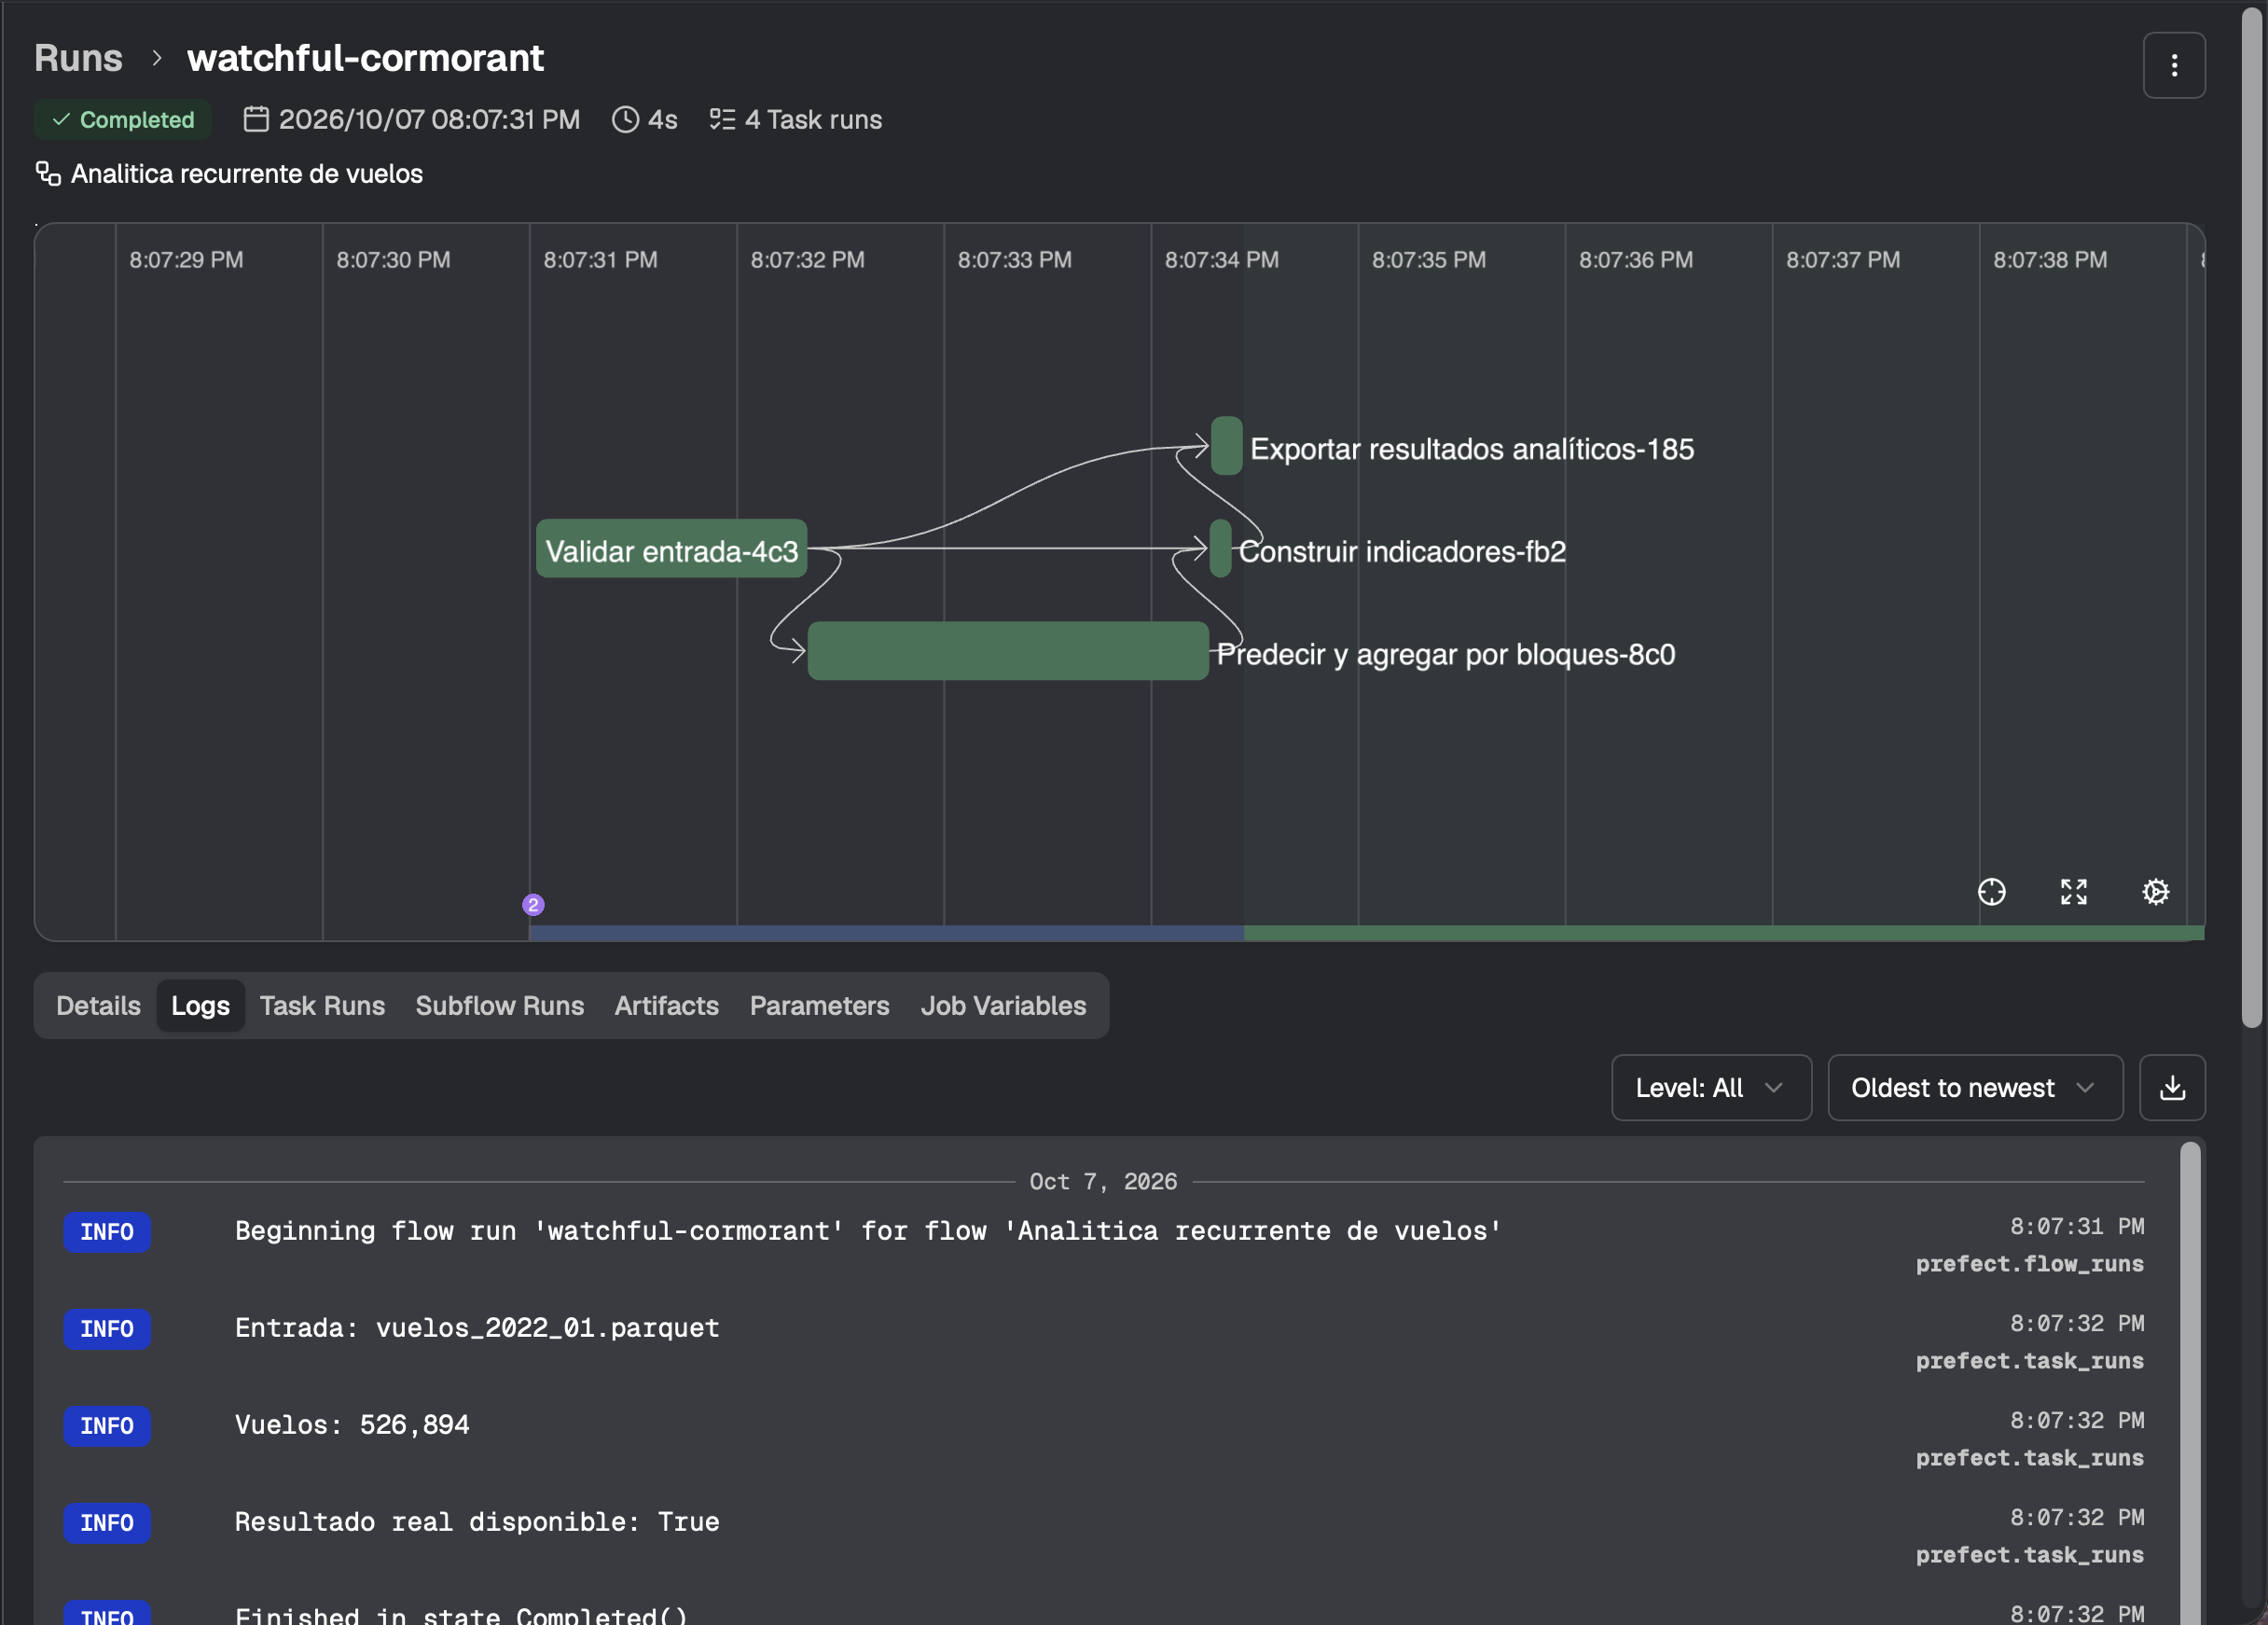

In [33]:
import os
import sys
import subprocess
from pathlib import Path
import pandas as pd
import pyarrow.parquet as pq

base = Path.cwd()
entrada = base / "datos_modelo" / "vuelos_2022_02.parquet"
salida = base / "salidas_prefect" / "resumen_vuelos_2022_02.csv"

entorno = os.environ.copy()
entorno["PREFECT_API_URL"] = "http://127.0.0.1:4200/api"

resultado = subprocess.run(
    [
        sys.executable,
        str(base / "flujo_vuelos.py"),
        "--archivo",
        str(entrada),
    ],
    cwd=base,
    env=entorno,
    text=True,
    capture_output=True,
)

print(resultado.stdout)
print(resultado.stderr)

if resultado.returncode != 0:
    raise RuntimeError("Falló el flujo de febrero. Revisa los mensajes.")

# Comprobar que el resumen conserva el total de vuelos.
resumen = pd.read_csv(salida)
filas_entrada = pq.ParquetFile(entrada).metadata.num_rows
vuelos_resumidos = int(resumen["vuelos"].sum())

assert vuelos_resumidos == filas_entrada, "Los totales no coinciden."
assert not resumen.duplicated(
    ["FlightDate", "Operating_Airline", "Origin"]
).any(), "Hay claves duplicadas en el resumen."

print("\nVERIFICACIÓN COMPLETADA")
print(f"Vuelos de entrada: {filas_entrada:,}")
print(f"Vuelos representados: {vuelos_resumidos:,}")
print(f"Filas del resumen: {len(resumen):,}")
print(f"Archivo: {salida.name}")


20:11:29.867 | INFO    | Flow run 'pearl-pug' - Beginning flow run 'pearl-pug' for flow 'Analitica recurrente de vuelos'
20:11:29.871 | INFO    | Flow run 'pearl-pug' - View at http://127.0.0.1:4200/runs/flow-run/53b888af-70b9-4a7d-b7fb-914a05ecfbcc
20:11:30.987 | INFO    | Task run 'Validar entrada-68e' - Entrada: vuelos_2022_02.parquet
20:11:30.988 | INFO    | Task run 'Validar entrada-68e' - Vuelos: 495,651
20:11:30.988 | INFO    | Task run 'Validar entrada-68e' - Resultado real disponible: True
20:11:30.990 | INFO    | Task run 'Validar entrada-68e' - Finished in state Completed()
20:11:33.164 | INFO    | Task run 'Predecir y agregar por bloques-23f' - Vuelos procesados: 495,651
20:11:33.166 | INFO    | Task run 'Predecir y agregar por bloques-23f' - Finished in state Completed()
20:11:33.172 | INFO    | Task run 'Construir indicadores-658' - Filas del resumen analítico: 46,552
20:11:33.173 | INFO    | Task run 'Construir indicadores-658' - Finished in state Completed()
20:11:33.3

In [34]:
%%writefile programar_vuelos.py
from pathlib import Path
import hashlib
import json
import os

# Conexión al servidor local antes de importar Prefect.
os.environ["PREFECT_API_URL"] = "http://127.0.0.1:4200/api"

from prefect import flow
from flujo_vuelos import flujo_vuelos, MODELO

BASE = Path(__file__).resolve().parent
ENTRADAS = BASE / "entradas_prefect"
CONTROL = BASE / "control_prefect.json"


def huella(ruta):
    """Identifica el contenido sin cargar todo el archivo en memoria."""
    sha = hashlib.sha256()
    with open(ruta, "rb") as archivo:
        for bloque in iter(lambda: archivo.read(1024 * 1024), b""):
            sha.update(bloque)
    return sha.hexdigest()


@flow(name="Revisar nuevos archivos de vuelos", log_prints=True)
def revisar_entradas():
    ENTRADAS.mkdir(exist_ok=True)

    registro = (
        json.loads(CONTROL.read_text(encoding="utf-8"))
        if CONTROL.exists()
        else {}
    )

    # Reprocesar también si cambia el modelo o el código analítico.
    version = (
        huella(MODELO)
        + huella(BASE / "flujo_vuelos.py")
    )

    procesados = 0

    for archivo in sorted(ENTRADAS.glob("*.parquet")):
        firma = huella(archivo) + version
        salida = BASE / "salidas_prefect" / f"resumen_{archivo.stem}.csv"

        if registro.get(archivo.name) == firma and salida.is_file():
            print(f"Sin cambios, se omite: {archivo.name}")
            continue

        print(f"Procesando archivo nuevo o modificado: {archivo.name}")
        flujo_vuelos(str(archivo))

        # Marcar como procesado únicamente después de completar el flujo.
        registro[archivo.name] = firma
        temporal = CONTROL.with_suffix(".tmp")
        temporal.write_text(
            json.dumps(registro, indent=2),
            encoding="utf-8",
        )
        temporal.replace(CONTROL)
        procesados += 1

    print(f"Archivos procesados en esta revisión: {procesados}")


if __name__ == "__main__":
    revisar_entradas.serve(
        name="revision-automatica-vuelos",
        interval=60,
        limit=1,
        pause_on_shutdown=True,
    )

Writing programar_vuelos.py


In [35]:
from pathlib import Path
import shutil
import shlex
import sys

base = Path.cwd()
carpeta = base / "entradas_prefect"
carpeta.mkdir(exist_ok=True)

origen = base / "datos_modelo" / "vuelos_2022_03.parquet"
destino = carpeta / origen.name

# Publicar el archivo solamente cuando termine de copiarse.
temporal = destino.with_suffix(".tmp")
shutil.copy2(origen, temporal)
temporal.replace(destino)

print("Archivo listo:", destino.name)
print("\nCOPIA ESTE COMANDO EN UNA TERMINAL NUEVA:\n")
print(
    f"cd {shlex.quote(str(base))} && "
    f"{shlex.quote(sys.executable)} programar_vuelos.py"
)

Archivo listo: vuelos_2022_03.parquet

COPIA ESTE COMANDO EN UNA TERMINAL NUEVA:

cd '/Users/luiscangrejomotta/Desktop/Maestria Analitica Aplicada /HdBD/Proyecto_Final' && /Users/luiscangrejomotta/miniconda3/bin/python programar_vuelos.py


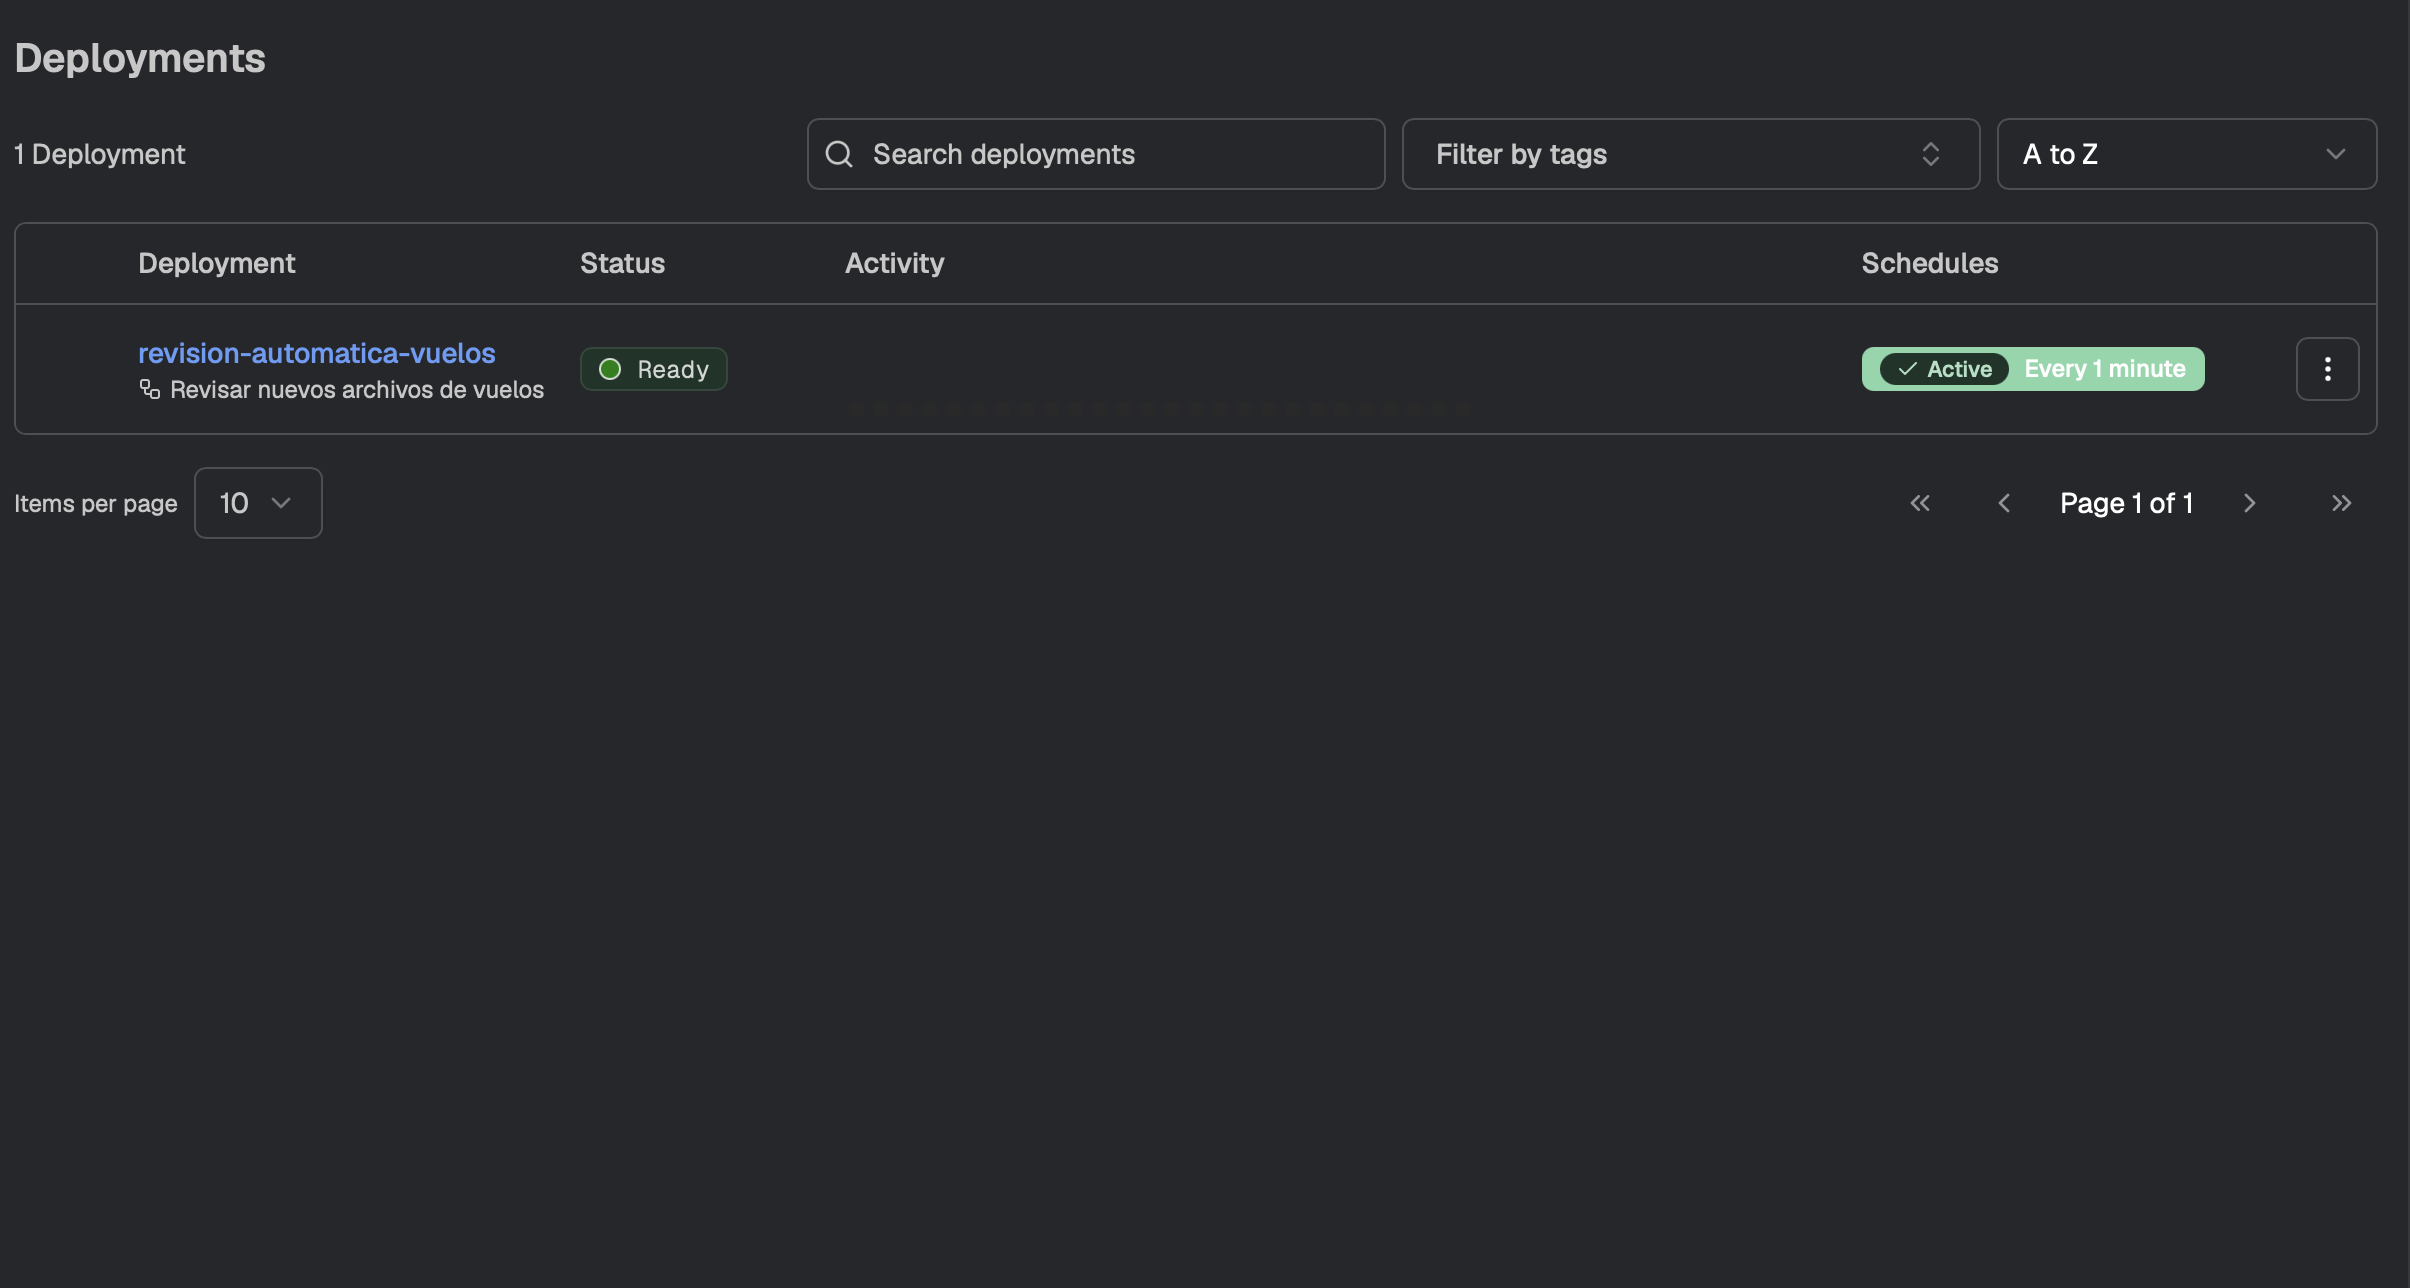

### Evidencia de programación recurrente con Prefect

Se registró el despliegue `revision-automatica-vuelos` con una
programación activa cada 60 segundos para la demostración.
El proceso revisa la carpeta de entrada para identificar archivos
nuevos o modificados. Su funcionamiento local requiere mantener
activos el servidor de Prefect y el proceso de ejecución.

In [36]:
import subprocess
import sys

diagnostico = subprocess.run(
    [
        sys.executable, "-m", "prefect",
        "config", "view", "--show-defaults"
    ],
    capture_output=True,
    text=True,
)

# Mostrar únicamente opciones relacionadas con la programación.
palabras = ("SCHEDULER", "SERVICES_ENABLED", "BACKGROUND_SERVICES")
lineas = [
    linea
    for linea in diagnostico.stdout.splitlines()
    if any(palabra in linea.upper() for palabra in palabras)
]

print("\n".join(lineas) or "No se encontraron esas opciones en la salida.")

if diagnostico.returncode != 0:
    print(diagnostico.stderr)

PREFECT_SERVER_SERVICES_SCHEDULER_DEPLOYMENT_BATCH_SIZE='100' (from defaults)
PREFECT_SERVER_SERVICES_SCHEDULER_ENABLED='True' (from defaults)
PREFECT_SERVER_SERVICES_SCHEDULER_INSERT_BATCH_SIZE='500' (from defaults)
PREFECT_SERVER_SERVICES_SCHEDULER_LOOP_SECONDS='60.0' (from defaults)
PREFECT_SERVER_SERVICES_SCHEDULER_MAX_RUNS='100' (from defaults)
PREFECT_SERVER_SERVICES_SCHEDULER_MAX_SCHEDULED_TIME='100 days, 0:00:00' (from defaults)
PREFECT_SERVER_SERVICES_SCHEDULER_MIN_RUNS='3' (from defaults)
PREFECT_SERVER_SERVICES_SCHEDULER_MIN_SCHEDULED_TIME='1:00:00' (from defaults)
PREFECT_SERVER_SERVICES_SCHEDULER_RECENT_DEPLOYMENTS_LOOP_SECONDS='5.0' (from defaults)


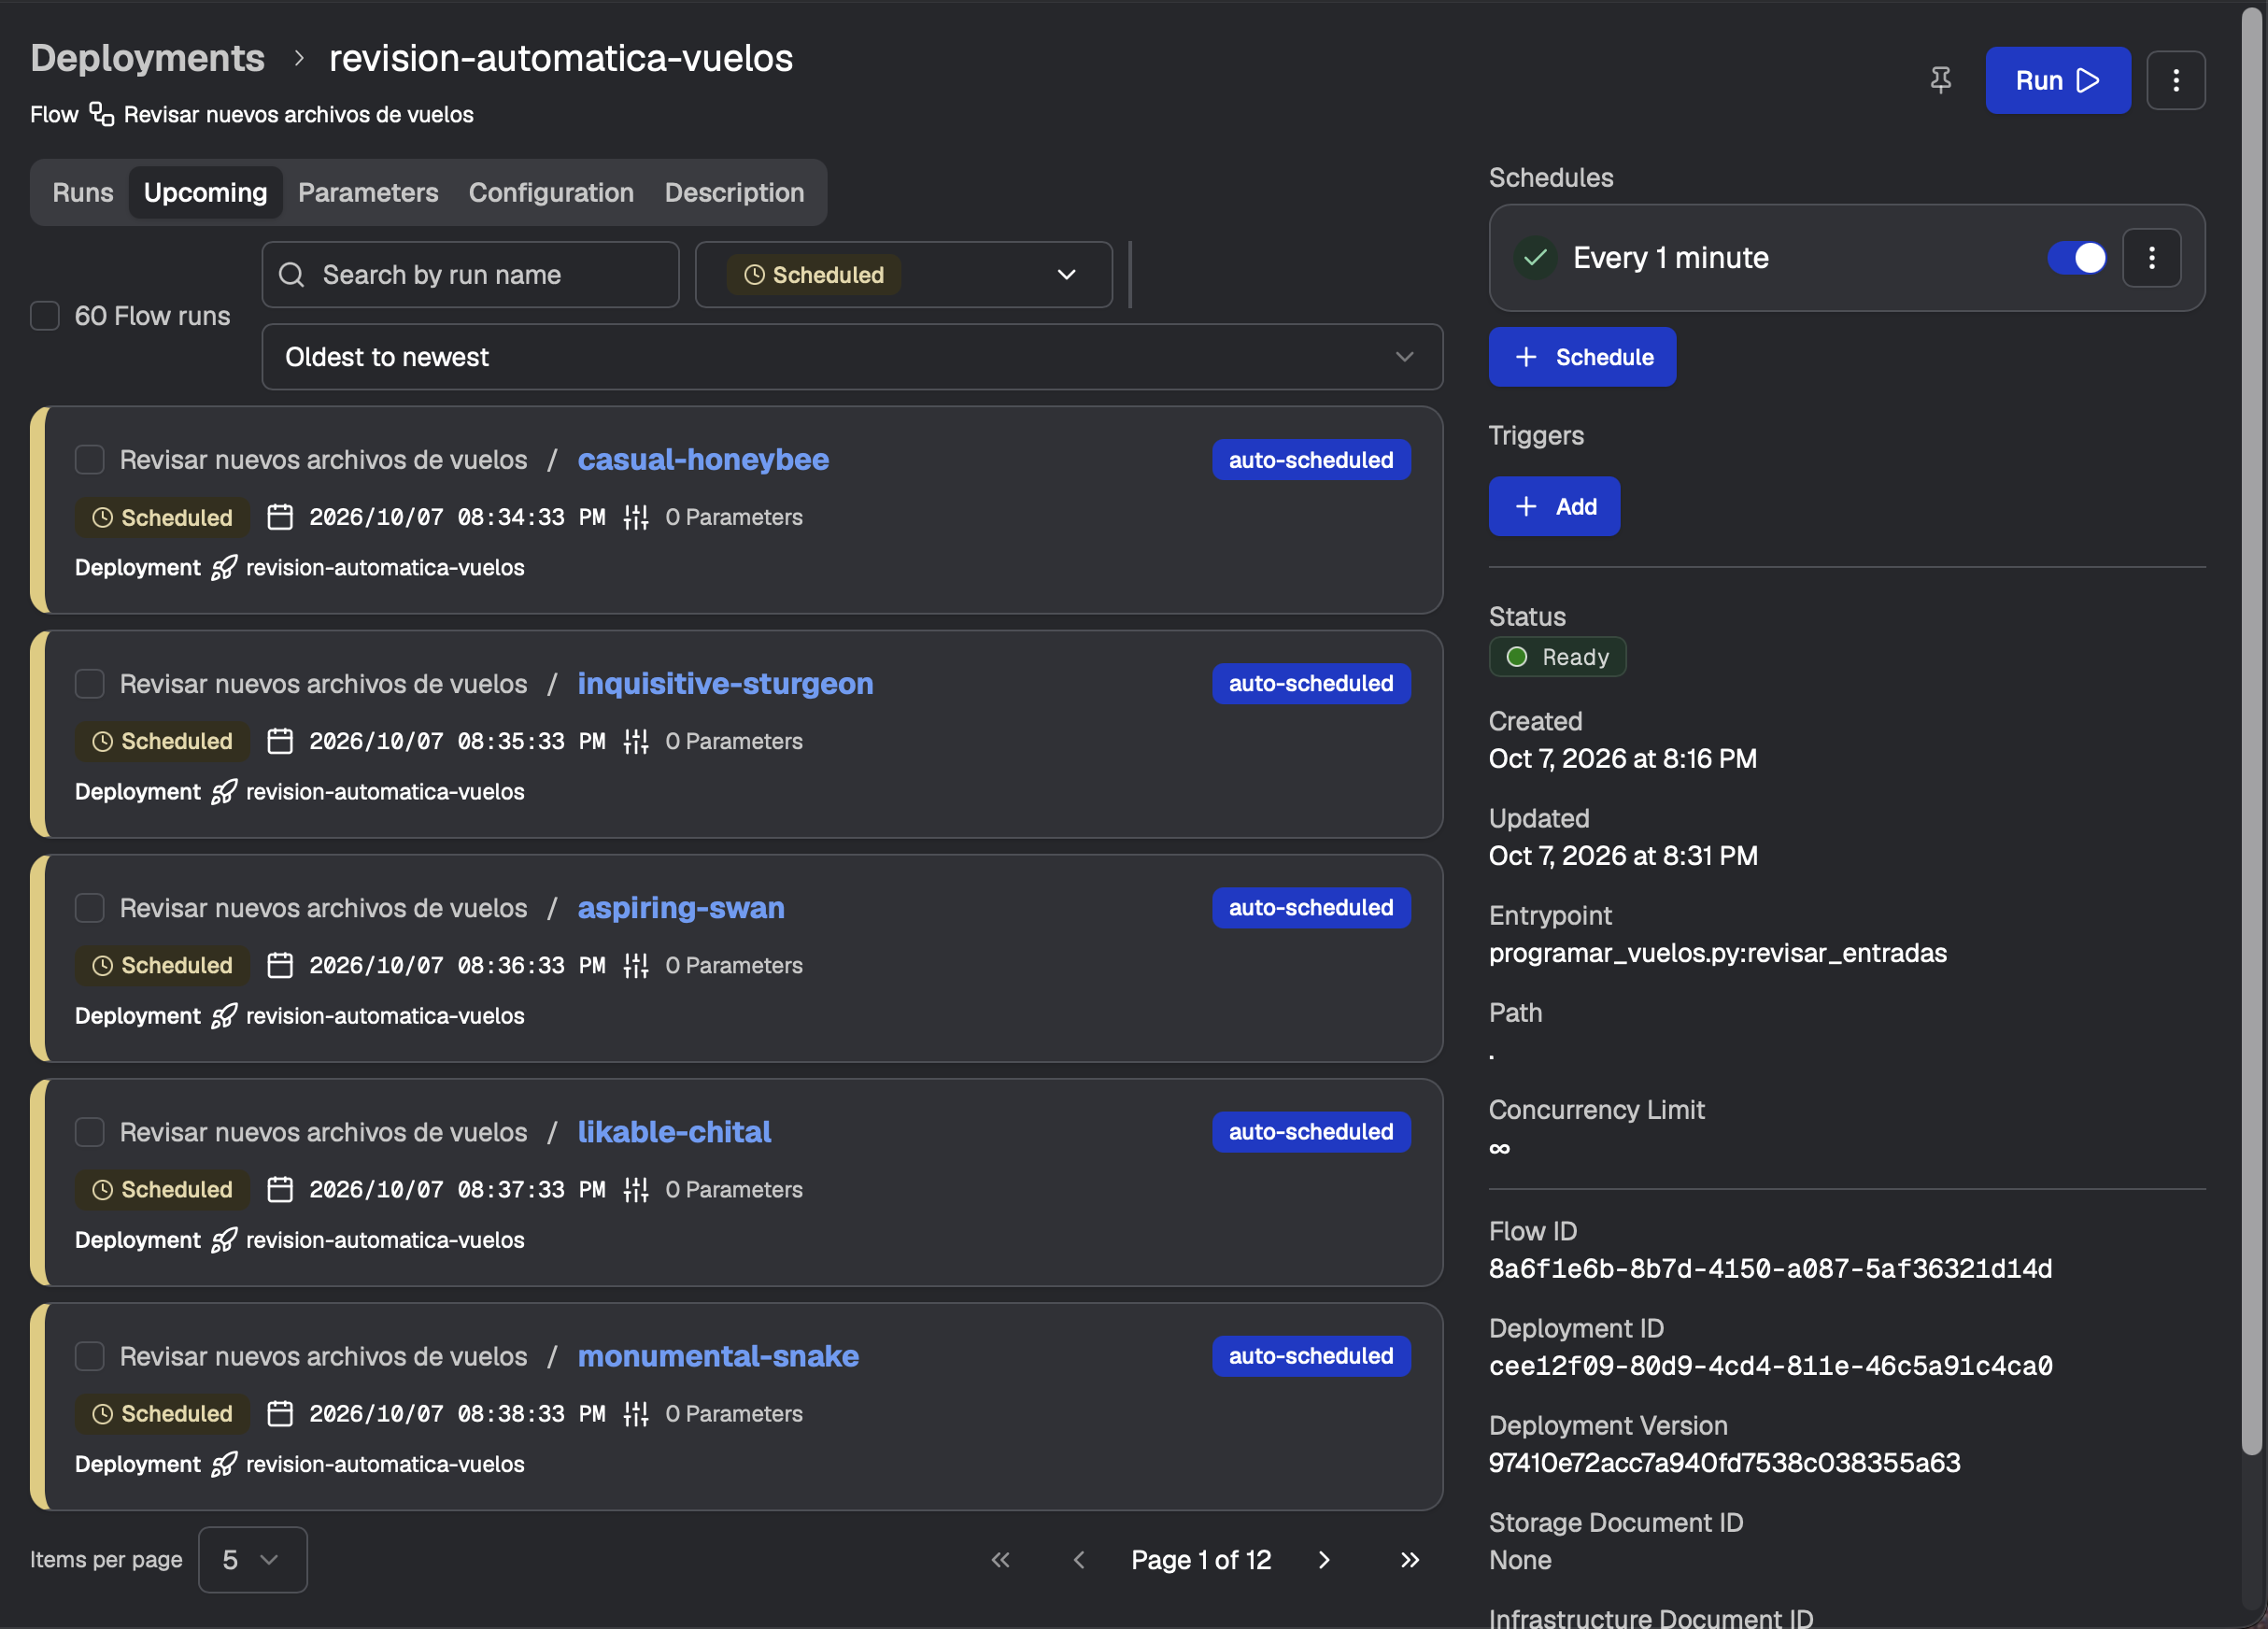

### Conclusiones de la automatización con Prefect

Se implementó un flujo recurrente que recibe archivos Parquet previamente
preparados, valida su estructura, aplica el modelo predictivo y genera
indicadores agregados por fecha, aerolínea operadora y aeropuerto de origen.

La prueba automática procesó 579.953 vuelos de marzo de 2022 y generó
52.802 registros de resumen analítico. Las cuatro tareas y el flujo
finalizaron en estado Completed.

Se configuró una revisión cada 60 segundos para la demostración.
En las revisiones posteriores, el sistema omitió el archivo sin cambios,
evitando repetir el procesamiento. El control considera el contenido
del archivo, el modelo y el script analítico.

Durante la configuración se resolvió una incompatibilidad de SQLAlchemy
instalando la versión 2.0.49, después de lo cual se verificaron ejecuciones
automáticas exitosas.

El flujo automatizado comienza con los Parquet preparados; la conversión
y limpieza del CSV original se realizan en una etapa anterior.
Los resultados se exportan localmente y quedan disponibles para su
posterior carga en AWS y visualización en Grafana.

La demostración se ejecutó localmente y requiere mantener activos el
servidor y el proceso de programación para continuar operando.

In [37]:
from pathlib import Path
import os
import subprocess
import sys

import pandas as pd
import pyarrow.parquet as pq

base = Path.cwd()
script = base / "flujo_vuelos.py"

assert script.is_file(), (
    f"No se encontró flujo_vuelos.py en {base}. "
    "Revisa la carpeta de trabajo del notebook."
)

entorno = os.environ.copy()
entorno["PREFECT_API_URL"] = "http://127.0.0.1:4200/api"

verificaciones = []

for mes in range(4, 8):
    entrada = base / "datos_modelo" / f"vuelos_2022_{mes:02d}.parquet"
    salida = base / "salidas_prefect" / f"resumen_{entrada.stem}.csv"

    assert entrada.is_file(), f"No existe: {entrada}"

    print(f"\nProcesando 2022-{mes:02d}...", flush=True)

    ejecucion = subprocess.run(
        [
            sys.executable,
            str(script),
            "--archivo",
            str(entrada),
        ],
        cwd=base,
        env=entorno,
        capture_output=True,
        text=True,
    )

    if ejecucion.returncode != 0:
        print(ejecucion.stdout)
        print(ejecucion.stderr)
        raise RuntimeError(f"Falló el flujo para 2022-{mes:02d}")

    assert salida.is_file(), f"No se generó: {salida}"

    filas_entrada = pq.ParquetFile(entrada).metadata.num_rows
    resumen = pd.read_csv(
        salida,
        dtype={"Operating_Airline": "string", "Origin": "string"},
    )

    claves = ["FlightDate", "Operating_Airline", "Origin"]
    vuelos_resumidos = int(resumen["vuelos"].sum())
    duplicados = int(resumen.duplicated(claves).sum())

    assert vuelos_resumidos == filas_entrada, (
        f"No coinciden los vuelos de entrada y salida para {mes:02d}"
    )
    assert duplicados == 0, (
        f"Hay claves duplicadas en el resumen de {mes:02d}"
    )
    assert not resumen[claves].isna().any().any(), (
        f"Hay claves faltantes en el resumen de {mes:02d}"
    )

    verificaciones.append({
        "periodo": f"2022-{mes:02d}",
        "vuelos_entrada": filas_entrada,
        "vuelos_en_resumen": vuelos_resumidos,
        "filas_resumen": len(resumen),
        "claves_duplicadas": duplicados,
    })

    print(
        f"OK: {filas_entrada:,} vuelos → "
        f"{len(resumen):,} filas de resumen",
        flush=True,
    )

    del resumen

verificacion_meses = pd.DataFrame(verificaciones)

print("\nPROCESAMIENTO Y VALIDACIÓN COMPLETADOS")
display(verificacion_meses)


Procesando 2022-04...
OK: 565,501 vuelos → 50,928 filas de resumen

Procesando 2022-05...
OK: 589,376 vuelos → 52,663 filas de resumen

Procesando 2022-06...
OK: 581,836 vuelos → 51,506 filas de resumen

Procesando 2022-07...
OK: 605,705 vuelos → 53,373 filas de resumen

PROCESAMIENTO Y VALIDACIÓN COMPLETADOS


,periodo,vuelos_entrada,vuelos_en_resumen,filas_resumen,claves_duplicadas
0,2022-04,565501,565501,50928,0
1,2022-05,589376,589376,52663,0
2,2022-06,581836,581836,51506,0
3,2022-07,605705,605705,53373,0


In [38]:
from pathlib import Path
import pandas as pd
import numpy as np

base = Path.cwd()
partes = []

for mes in range(1, 8):
    archivo = (
        base / "salidas_prefect"
        / f"resumen_vuelos_2022_{mes:02d}.csv"
    )
    assert archivo.is_file(), f"Falta el archivo: {archivo.name}"

    parte = pd.read_csv(
        archivo,
        parse_dates=["FlightDate"],
        dtype={"Operating_Airline": "string", "Origin": "string"},
    )

    # Cada archivo debe contener únicamente su mes correspondiente.
    assert parte["FlightDate"].notna().all()
    assert parte["FlightDate"].dt.year.eq(2022).all()
    assert parte["FlightDate"].dt.month.eq(mes).all()

    partes.append(parte)

consolidado = pd.concat(partes, ignore_index=True)

# Nombres sencillos para utilizarlos posteriormente en SQL y Grafana.
consolidado = consolidado.rename(columns={
    "FlightDate": "fecha",
    "Operating_Airline": "aerolinea",
    "Origin": "aeropuerto_origen",
})

claves = ["fecha", "aerolinea", "aeropuerto_origen"]

assert not consolidado[claves].isna().any().any()
assert not consolidado.duplicated(claves).any()

# Validar conteos antes de convertirlos a enteros.
conteos = ["vuelos", "vuelos_con_resultado", "retrasos_observados"]

for columna in conteos:
    valores = pd.to_numeric(consolidado[columna], errors="raise")
    assert valores.notna().all(), f"Hay nulos en {columna}"
    assert np.isfinite(valores).all()
    assert valores.ge(0).all()
    assert valores.eq(np.floor(valores)).all()
    consolidado[columna] = valores.astype("int64")

assert consolidado["vuelos"].gt(0).all()
assert (
    consolidado["retrasos_observados"]
    <= consolidado["vuelos_con_resultado"]
).all()
assert (
    consolidado["vuelos_con_resultado"]
    <= consolidado["vuelos"]
).all()

# En esta base histórica preparada, todos tienen resultado conocido.
assert consolidado["vuelos_con_resultado"].equals(consolidado["vuelos"])

# Comprobar las salidas del modelo y recalcular los indicadores.
suma_prob = consolidado["suma_probabilidades"]
assert np.isfinite(suma_prob).all()
assert suma_prob.ge(0).all()
assert suma_prob.le(consolidado["vuelos"] + 1e-8).all()

consolidado["probabilidad_media_modelo"] = (
    suma_prob / consolidado["vuelos"]
)
consolidado["tasa_retraso_observada"] = (
    consolidado["retrasos_observados"]
    / consolidado["vuelos_con_resultado"]
)

assert consolidado["modelo_version"].eq("boosting_v2_1m").all()

# Comparar con los totales históricos ya evaluados.
assert consolidado["vuelos"].sum() == 3_944_916
assert consolidado["retrasos_observados"].sum() == 853_962

consolidado = consolidado.sort_values(claves).reset_index(drop=True)

carpeta = base / "entrega_aws"
carpeta.mkdir(exist_ok=True)

destino = carpeta / "analitica_vuelos_2022.csv"
consolidado.to_csv(destino, index=False, date_format="%Y-%m-%d")

print("CONSOLIDACIÓN VALIDADA")
print(f"Filas de la tabla: {len(consolidado):,}")
print(f"Vuelos representados: {consolidado['vuelos'].sum():,}")
print(f"Vuelos retrasados: {consolidado['retrasos_observados'].sum():,}")
print(
    "Tasa global de retraso: "
    f"{consolidado['retrasos_observados'].sum() / consolidado['vuelos_con_resultado'].sum():.2%}"
)
print(f"Tamaño CSV: {destino.stat().st_size / 1024**2:.2f} MiB")
print(f"Archivo: {destino}")

display(consolidado.head())

CONSOLIDACIÓN VALIDADA
Filas de la tabla: 358,665
Vuelos representados: 3,944,916
Vuelos retrasados: 853,962
Tasa global de retraso: 21.65%
Tamaño CSV: 29.34 MiB
Archivo: /Users/luiscangrejomotta/Desktop/Maestria Analitica Aplicada /HdBD/Proyecto_Final/entrega_aws/analitica_vuelos_2022.csv


,fecha,aerolinea,aeropuerto_origen,vuelos,suma_probabilidades,vuelos_con_resultado,retrasos_observados,probabilidad_media_modelo,tasa_retraso_observada,modelo_version
0,2022-01-01,9E,ABE,2,0.184547,2,0,0.092274,0.0,boosting_v2_1m
1,2022-01-01,9E,ABY,2,0.134488,2,1,0.067244,0.5,boosting_v2_1m
2,2022-01-01,9E,AEX,2,0.118483,2,1,0.059242,0.5,boosting_v2_1m
3,2022-01-01,9E,AGS,4,0.374600,4,0,0.093650,0.0,boosting_v2_1m
4,2022-01-01,9E,ALB,2,0.152286,2,0,0.076143,0.0,boosting_v2_1m


In [39]:
%pip install "psycopg[binary]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 14.0 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [psycopg]m1/2 [psycopg]
Note: you may need to restart the kernel to use updated packages.


In [7]:
from pathlib import Path
from urllib.request import urlopen
from getpass import getpass
import psycopg

certificado = Path.cwd() / "certificados" / "global-bundle.pem"
certificado.parent.mkdir(exist_ok=True)

if not certificado.exists():
    url = "https://truststore.pki.rds.amazonaws.com/global/global-bundle.pem"
    with urlopen(url, timeout=30) as respuesta:
        certificado.write_bytes(respuesta.read())

config_db = {
    "host": "vuelos-analitica-db.cwbquvddclqa.us-east-1.rds.amazonaws.com",
    "port": 5432,
    "dbname": "vuelos_analytics",
    "user": "postgres",
    "sslmode": "verify-full",
    "sslrootcert": str(certificado),
    "connect_timeout": 15,
}

clave_db = getpass("Contraseña de PostgreSQL en AWS: ")

try:
    with psycopg.connect(**config_db, password=clave_db) as conexion:
        with conexion.cursor() as cursor:
            cursor.execute("""
                SELECT current_database(), current_user, version();
            """)
            base_conectada, usuario, version = cursor.fetchone()

            cursor.execute("""
                SELECT ssl
                FROM pg_stat_ssl
                WHERE pid = pg_backend_pid();
            """)
            cifrada = cursor.fetchone()[0]

    print("CONEXIÓN EXITOSA")
    print("Base de datos:", base_conectada)
    print("Usuario:", usuario)
    print("Conexión cifrada:", cifrada)
    print("Versión:", version)

finally:
    del clave_db

CONEXIÓN EXITOSA
Base de datos: vuelos_analytics
Usuario: postgres
Conexión cifrada: True
Versión: PostgreSQL 18.3 on aarch64-unknown-linux-gnu, compiled by aarch64-unknown-linux-gnu-gcc (GCC) 12.4.0, 64-bit


In [6]:
import socket
from urllib.request import urlopen

host_rds = "vuelos-analitica-db.cwbquvddclqa.us-east-1.rds.amazonaws.com"

try:
    with urlopen("https://checkip.amazonaws.com", timeout=10) as respuesta:
        ip_actual = respuesta.read().decode().strip()

    print("IP pública detectada desde Python:", ip_actual)
    print("Origen que debe permitir AWS:", f"{ip_actual}/32")
except Exception as error:
    print("No se pudo consultar la IP:", error)

try:
    ip_rds = socket.gethostbyname(host_rds)
    print("IP del servidor RDS:", ip_rds)

    with socket.create_connection((host_rds, 5432), timeout=10):
        print("PUERTO 5432 ACCESIBLE")
except OSError as error:
    print("No se pudo conectar al puerto 5432:", error)
    

IP pública detectada desde Python: 181.63.25.162
Origen que debe permitir AWS: 181.63.25.162/32
IP del servidor RDS: 100.30.129.19
PUERTO 5432 ACCESIBLE


In [8]:
from pathlib import Path
from getpass import getpass
from time import perf_counter
import csv
import psycopg
from psycopg import sql

archivo_csv = Path.cwd() / "entrega_aws" / "analitica_vuelos_2022.csv"

columnas = [
    "fecha", "aerolinea", "aeropuerto_origen", "vuelos",
    "suma_probabilidades", "vuelos_con_resultado",
    "retrasos_observados", "probabilidad_media_modelo",
    "tasa_retraso_observada", "modelo_version"
]

if not archivo_csv.is_file():
    raise FileNotFoundError(f"No se encontró: {archivo_csv}")

with archivo_csv.open(encoding="utf-8-sig", newline="") as archivo:
    encabezado = next(csv.reader(archivo))

if encabezado != columnas:
    raise ValueError(f"Revisar nombres u orden de columnas: {encabezado}")

clave_db = getpass("Contraseña de PostgreSQL en AWS: ")
inicio = perf_counter()

try:
    with psycopg.connect(**config_db, password=clave_db) as conexion:
        with conexion.cursor() as cursor:
            cursor.execute("SET LOCAL statement_timeout = '5min'")
            cursor.execute("CREATE SCHEMA IF NOT EXISTS analitica")

            cursor.execute("""
                CREATE TABLE IF NOT EXISTS analitica.resumen_vuelos (
                    fecha DATE NOT NULL,
                    aerolinea TEXT NOT NULL,
                    aeropuerto_origen TEXT NOT NULL,
                    vuelos BIGINT NOT NULL CHECK (vuelos > 0),
                    suma_probabilidades DOUBLE PRECISION NOT NULL,
                    vuelos_con_resultado BIGINT NOT NULL,
                    retrasos_observados BIGINT NOT NULL,
                    probabilidad_media_modelo DOUBLE PRECISION NOT NULL,
                    tasa_retraso_observada DOUBLE PRECISION,
                    modelo_version TEXT NOT NULL,
                    PRIMARY KEY (
                        fecha, aerolinea, aeropuerto_origen, modelo_version
                    ),
                    CHECK (
                        retrasos_observados >= 0
                        AND retrasos_observados <= vuelos_con_resultado
                        AND vuelos_con_resultado <= vuelos
                    ),
                    CHECK (suma_probabilidades BETWEEN 0 AND vuelos),
                    CHECK (probabilidad_media_modelo BETWEEN 0 AND 1),
                    CHECK (tasa_retraso_observada BETWEEN 0 AND 1)
                )
            """)

            cursor.execute("""
                CREATE TEMP TABLE carga_vuelos
                (LIKE analitica.resumen_vuelos INCLUDING ALL)
                ON COMMIT DROP
            """)

            campos_sql = sql.SQL(", ").join(
                sql.Identifier(c) for c in columnas
            )

            print("Cargando CSV de resultados a AWS...", flush=True)

            consulta_copy = sql.SQL("""
                COPY carga_vuelos ({})
                FROM STDIN WITH (FORMAT CSV, HEADER TRUE)
            """).format(campos_sql)

            with archivo_csv.open(encoding="utf-8-sig", newline="") as archivo:
                with cursor.copy(consulta_copy) as copia:
                    while bloque := archivo.read(1024 * 1024):
                        copia.write(bloque)

            cursor.execute("""
                SELECT COUNT(*), SUM(vuelos),
                       SUM(vuelos_con_resultado), SUM(retrasos_observados)
                FROM carga_vuelos
            """)
            totales = tuple(int(v) for v in cursor.fetchone())
            esperados = (358665, 3944916, 3944916, 853962)

            if totales != esperados:
                raise ValueError(
                    f"Totales diferentes: {totales}. "
                    f"Se esperaban: {esperados}. Se cancela la carga."
                )

            claves = {
                "fecha", "aerolinea", "aeropuerto_origen", "modelo_version"
            }
            actualizaciones = sql.SQL(", ").join(
                sql.SQL("{} = EXCLUDED.{}").format(
                    sql.Identifier(c), sql.Identifier(c)
                )
                for c in columnas if c not in claves
            )

            cursor.execute(sql.SQL("""
                INSERT INTO analitica.resumen_vuelos ({})
                SELECT {} FROM carga_vuelos
                ON CONFLICT (
                    fecha, aerolinea, aeropuerto_origen, modelo_version
                )
                DO UPDATE SET {}
            """).format(campos_sql, campos_sql, actualizaciones))

            cursor.execute("""
                SELECT COUNT(*), SUM(vuelos), SUM(retrasos_observados),
                       MIN(fecha), MAX(fecha),
                       100.0 * SUM(retrasos_observados)
                       / NULLIF(SUM(vuelos_con_resultado), 0)
                FROM analitica.resumen_vuelos
                WHERE modelo_version = 'boosting_v2_1m'
                  AND fecha BETWEEN DATE '2022-01-01' AND DATE '2022-07-31'
            """)
            filas, vuelos, retrasos, desde, hasta, tasa = cursor.fetchone()

            if (int(filas), int(vuelos), int(retrasos)) != (
                358665, 3944916, 853962
            ):
                raise ValueError("La validación final no coincide; se revierte.")

    # Este mensaje aparece después de confirmar la transacción.
    print("\nCARGA COMPLETADA Y CONFIRMADA EN AWS")
    print("Tabla: analitica.resumen_vuelos")
    print(f"Filas agregadas: {filas:,}")
    print(f"Vuelos representados: {vuelos:,}")
    print(f"Retrasos observados: {retrasos:,}")
    print(f"Periodo: {desde} a {hasta}")
    print(f"Tasa de retraso: {tasa:.2f}%")
    print(f"Tiempo: {perf_counter() - inicio:.1f} segundos")

finally:
    del clave_db

Cargando CSV de resultados a AWS...

CARGA COMPLETADA Y CONFIRMADA EN AWS
Tabla: analitica.resumen_vuelos
Filas agregadas: 358,665
Vuelos representados: 3,944,916
Retrasos observados: 853,962
Periodo: 2022-01-01 a 2022-07-31
Tasa de retraso: 21.65%
Tiempo: 7.1 segundos


In [9]:
from getpass import getpass
import psycopg
from psycopg import sql

clave_admin = getpass("Contraseña actual de postgres: ")
clave_grafana = getpass("Nueva contraseña para grafana_reader: ")
confirmacion = getpass("Repite la nueva contraseña: ")

try:
    if not clave_grafana or clave_grafana != confirmacion:
        raise ValueError("La contraseña está vacía o no coincide.")

    with psycopg.connect(**config_db, password=clave_admin) as conexion:
        with conexion.cursor() as cursor:
            cursor.execute("""
                SELECT 1 FROM pg_roles
                WHERE rolname = 'grafana_reader'
            """)

            if cursor.fetchone() is None:
                cursor.execute(sql.SQL("""
                    CREATE ROLE grafana_reader
                    LOGIN NOSUPERUSER NOCREATEDB NOCREATEROLE
                    NOREPLICATION PASSWORD {}
                """).format(sql.Literal(clave_grafana)))
            else:
                raise ValueError(
                    "grafana_reader ya existe. No se modificó su contraseña."
                )

            cursor.execute("""
                GRANT CONNECT ON DATABASE vuelos_analytics
                TO grafana_reader
            """)
            cursor.execute("""
                GRANT USAGE ON SCHEMA analitica TO grafana_reader
            """)
            cursor.execute("""
                GRANT SELECT ON analitica.resumen_vuelos
                TO grafana_reader
            """)
            cursor.execute("""
                ALTER ROLE grafana_reader
                SET statement_timeout = '60s'
            """)

    print("Usuario creado. Verificando acceso...")

    config_lector = {**config_db, "user": "grafana_reader"}

    with psycopg.connect(
        **config_lector, password=clave_grafana
    ) as conexion:
        with conexion.cursor() as cursor:
            cursor.execute("SELECT COUNT(*) FROM analitica.resumen_vuelos")
            filas = cursor.fetchone()[0]

            cursor.execute("""
                SELECT
                    has_table_privilege(
                        current_user, 'analitica.resumen_vuelos', 'SELECT'
                    ),
                    has_table_privilege(
                        current_user, 'analitica.resumen_vuelos',
                        'INSERT, UPDATE, DELETE, TRUNCATE'
                    )
            """)
            puede_leer, puede_modificar = cursor.fetchone()

    print("USUARIO GRAFANA VERIFICADO")
    print("Usuario: grafana_reader")
    print(f"Filas accesibles: {filas:,}")
    print("Permiso de lectura:", puede_leer)
    print("Permiso para modificar datos:", puede_modificar)

finally:
    del clave_admin, clave_grafana, confirmacion

Usuario creado. Verificando acceso...
USUARIO GRAFANA VERIFICADO
Usuario: grafana_reader
Filas accesibles: 358,665
Permiso de lectura: True
Permiso para modificar datos: False


In [10]:
from pathlib import Path
import subprocess

ruta_certificado = Path(config_db["sslrootcert"])

subprocess.run(
    ["pbcopy"],
    input=ruta_certificado.read_bytes(),
    check=True
)

print("Certificado copiado. Ahora pégalo en Grafana con Command + V.")

Certificado copiado. Ahora pégalo en Grafana con Command + V.


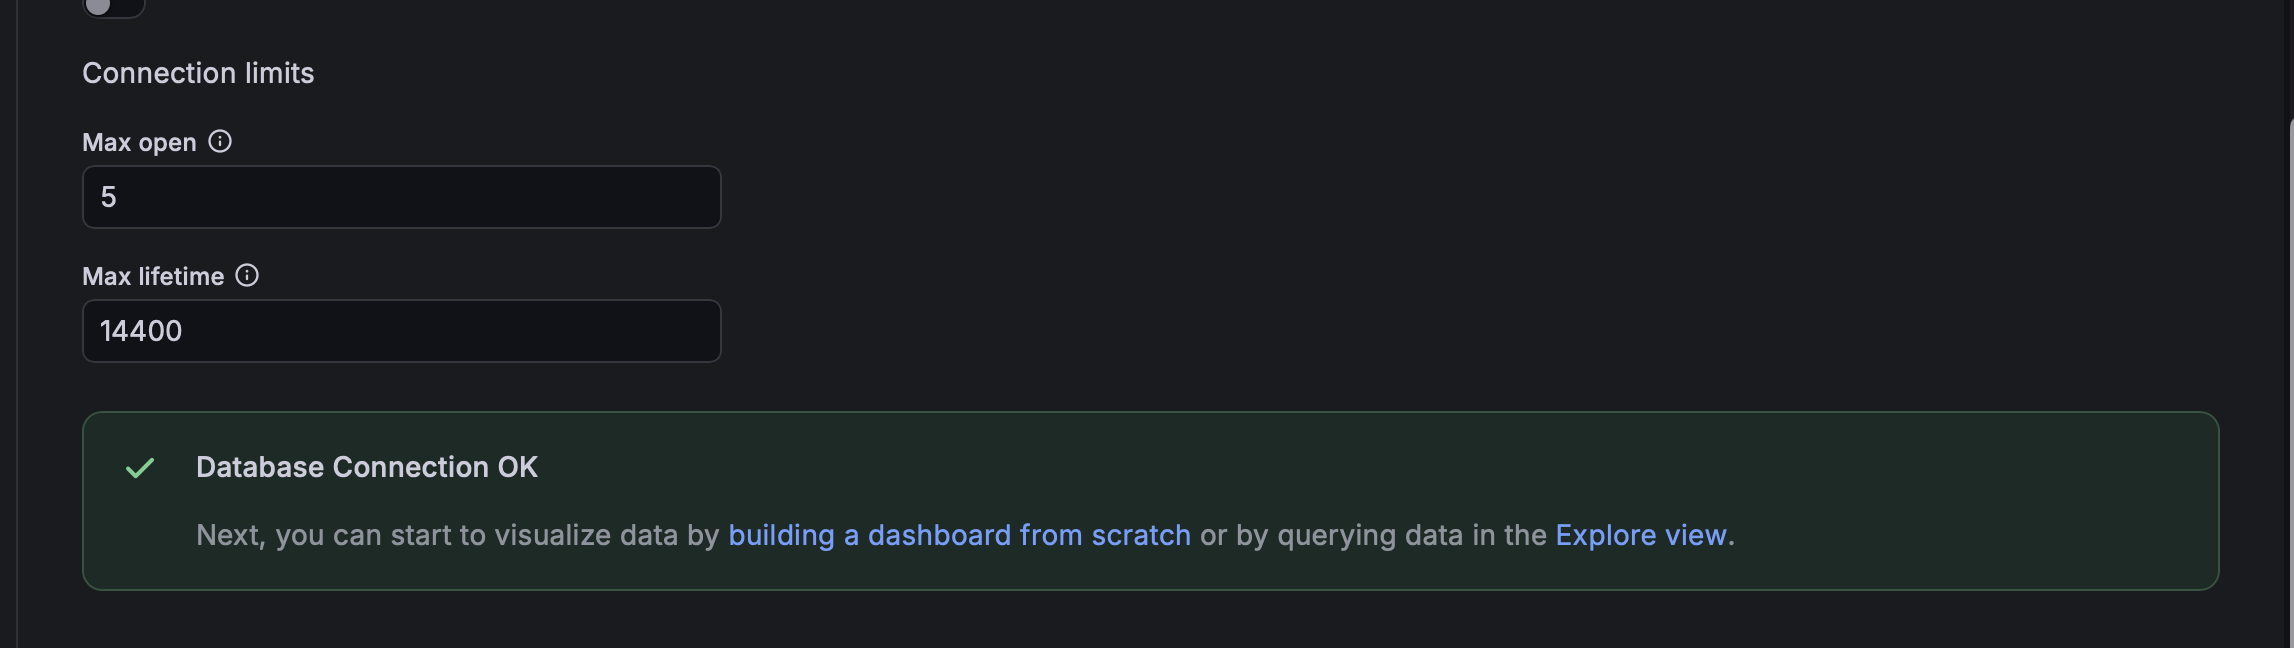

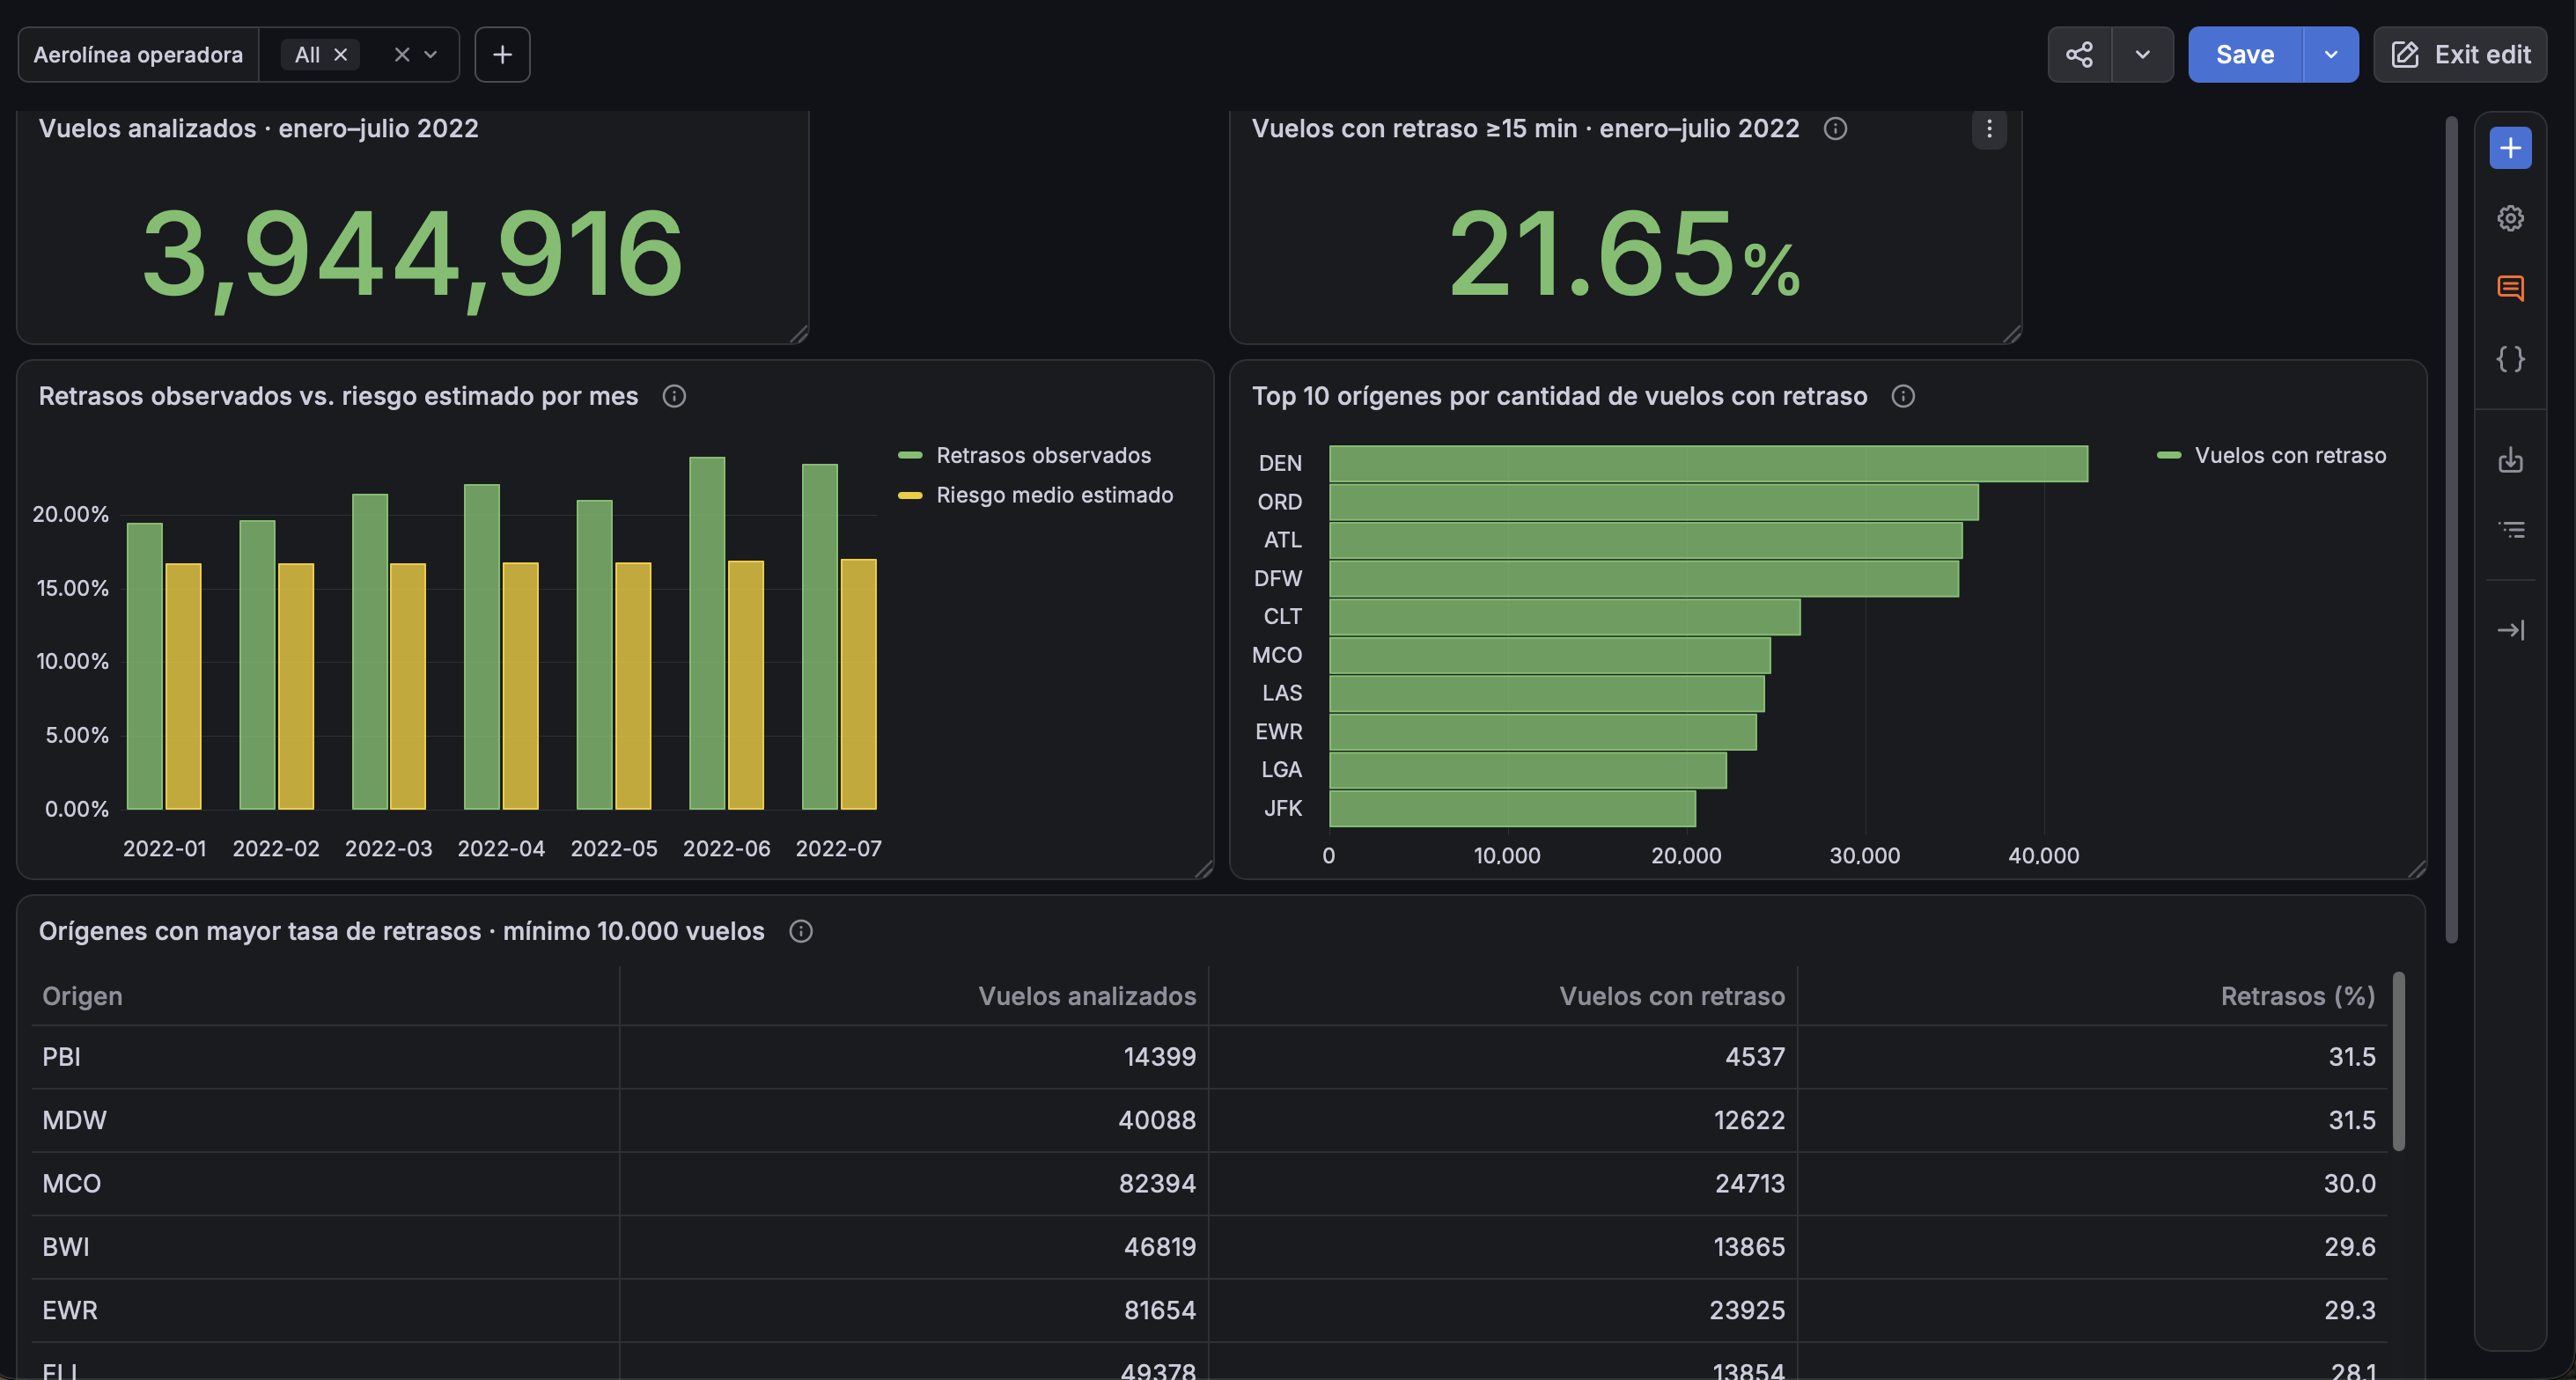

## Resultados de almacenamiento y visualización

Se consolidaron los resultados analíticos de enero a julio de 2022
en 358.665 registros agregados, que representan 3.944.916 vuelos
y 853.962 retrasos observados. La tasa global de retraso fue del 21,65 %.

La carga a Amazon RDS PostgreSQL incluyó únicamente estos resultados
analíticos. El conjunto de datos original permaneció fuera de AWS.

Se verificaron los totales antes y después de la carga. La conexión
utilizó TLS con verificación del certificado y del servidor.
Para Grafana se creó un usuario con permisos de lectura sobre
la tabla analítica.

El tablero permite consultar el volumen de vuelos, la tasa de retraso,
el riesgo estimado por mes y los aeropuertos de origen, con filtro
por aerolínea. Las tasas agregadas se calculan a partir de sus
numeradores y denominadores, evitando promediar porcentajes
de grupos con tamaños distintos.

Los rankings por aeropuerto describen los vuelos que salieron
de esos orígenes y llegaron tarde a destino. No demuestran que
el aeropuerto de origen haya causado el retraso.

### Alcance de la automatización

Prefect procesa archivos Parquet previamente preparados, aplica
el modelo y exporta indicadores agregados a CSV. La revisión
recurrente identifica entradas nuevas o modificadas.

La preparación del CSV original, la consolidación histórica
y la carga a AWS se ejecutan por separado. Por tanto, el prototipo
automatiza una parte del proceso, pero no todo el recorrido
desde el archivo original hasta la base de datos.

## Conclusiones generales

1. El procesamiento por bloques y el formato Parquet permitieron
   preparar un conjunto de datos mayor que la memoria disponible,
   sin cargar todo el CSV simultáneamente.

2. Dask permitió comparar dos configuraciones con el mismo presupuesto
   total de memoria para workers. Con dos workers se redujo el tiempo
   mediano aproximadamente un 35,3 %, obteniendo los mismos resultados.
   Esta mejora corresponde a las condiciones de la prueba local.

3. El modelo final concentró 163.780 retrasos entre los 394.492 vuelos
   priorizados en la evaluación adicional de 2022. Identificó 32.003
   retrasos más que la primera versión, con la misma cantidad de vuelos
   seleccionados.

4. La precisión del 41,52 % corresponde al grupo priorizado, no a
   la exactitud global. Ese grupo incluyó el 19,18 % de todos los
   retrasos; el 80,82 % restante quedó fuera.

5. Prefect, Amazon RDS y Grafana permitieron demostrar procesamiento
   recurrente, almacenamiento de resultados y consulta gerencial,
   con los límites de automatización descritos.

6. El proyecto demuestra utilidad potencial para priorizar seguimiento.
   No demuestra que las alertas eviten retrasos ni generen ahorro.

## Limitaciones y trabajo futuro

La evaluación de 2022 no constituye una prueba final completamente
independiente, porque ese período ya se había consultado durante
el desarrollo.

El riesgo medio estimado fue del 16,79 %, frente a una frecuencia
observada del 21,65 %. Esta diferencia muestra subestimación agregada
y motiva una revisión de calibración.

La selección del 10 % se realizó sobre todo el período.
Antes de un uso operativo se requiere evaluar una capacidad diaria,
probar el modelo en un período nuevo y medir el costo y el beneficio
de las acciones que seguirían a una alerta.

También queda pendiente verificar la reproducción completa en otro
entorno e integrar la documentación y el EDA complementario del grupo.

In [11]:
from pathlib import Path
from importlib.metadata import version, PackageNotFoundError
import platform
import sys

carpeta = Path.cwd()

paquetes = [
    "pandas",
    "numpy",
    "pyarrow",
    "duckdb",
    "dask",
    "distributed",
    "scikit-learn",
    "joblib",
    "threadpoolctl",
    "prefect",
    "sqlalchemy",
    "psycopg",
    "psycopg2-binary",
    "matplotlib",
    "seaborn",
    "psutil",
    "ipykernel",
]

instalados = []
no_encontrados = []

for paquete in paquetes:
    try:
        instalados.append(f"{paquete}=={version(paquete)}")
    except PackageNotFoundError:
        no_encontrados.append(paquete)

# Registra versiones presentes; no instala ni modifica librerías.
ruta_requirements = carpeta / "requirements_detectados.txt"
ruta_requirements.write_text(
    "\n".join(instalados) + "\n",
    encoding="utf-8",
)

entorno = (
    f"Python: {sys.version}\n"
    f"Sistema: {platform.system()} {platform.release()}\n"
    f"Arquitectura: {platform.machine()}\n"
    f"Ejecutable del kernel: {sys.executable}\n"
)

(carpeta / "entorno_ejecucion.txt").write_text(
    entorno,
    encoding="utf-8",
)

print(entorno)
print("VERSIONES DETECTADAS")
print("\n".join(instalados))

print("\nNo encontrados — revisar si realmente se utilizan:")
print(", ".join(no_encontrados) or "Ninguno")

print("\nArchivos guardados en:", carpeta)

Python: 3.14.7 | packaged by Anaconda, Inc. | (main, Aug 14 2026, 10:13:42) [Clang 20.1.8 ]
Sistema: Darwin 27.0.0
Arquitectura: arm64
Ejecutable del kernel: /Users/luiscangrejomotta/miniconda3/bin/python

VERSIONES DETECTADAS
pandas==3.0.6
numpy==2.5.3
pyarrow==25.0.1
duckdb==1.5.6
dask==2026.8.0
distributed==2026.8.0
scikit-learn==1.9.1
joblib==1.6.0
threadpoolctl==3.7.0
prefect==3.8.8
sqlalchemy==2.0.49
psycopg==3.3.6
matplotlib==3.11.2
psutil==7.2.2
ipykernel==7.4.0

No encontrados — revisar si realmente se utilizan:
psycopg2-binary, seaborn

Archivos guardados en: /Users/luiscangrejomotta/Desktop/Maestria Analitica Aplicada /HdBD/Proyecto_Final


In [16]:
from pathlib import Path
from importlib.metadata import version
import platform

paquetes_proyecto = [
    "pandas",
    "numpy",
    "pyarrow",
    "duckdb",
    "dask",
    "distributed",
    "scikit-learn",
    "joblib",
    "threadpoolctl",
    "prefect",
    "sqlalchemy",
    "psycopg",
    "psycopg-binary",
    "psutil",
    "ipykernel",
]

# Consultar todas las versiones antes de modificar el archivo.
dependencias = [
    f"{paquete}=={version(paquete)}"
    for paquete in paquetes_proyecto
]

contenido = [
    "# Versiones del entorno utilizado para ejecutar el proyecto.",
    f"# Python: {platform.python_version()}",
    f"# Sistema: {platform.system()} / {platform.machine()}",
    "# Instalación desde cero pendiente de verificación.",
    "",
    *dependencias,
]

ruta = Path.cwd() / "requirements.txt"
ruta.write_text("\n".join(contenido) + "\n", encoding="utf-8")

print("Requirements actualizado:")
print(ruta.read_text(encoding="utf-8"))

Requirements actualizado:
# Versiones del entorno utilizado para ejecutar el proyecto.
# Python: 3.14.7
# Sistema: Darwin / arm64
# Instalación desde cero pendiente de verificación.

pandas==3.0.6
numpy==2.5.3
pyarrow==25.0.1
duckdb==1.5.6
dask==2026.8.0
distributed==2026.8.0
scikit-learn==1.9.1
joblib==1.6.0
threadpoolctl==3.7.0
prefect==3.8.8
sqlalchemy==2.0.49
psycopg==3.3.6
psycopg-binary==3.3.6
psutil==7.2.2
ipykernel==7.4.0



In [13]:
from pathlib import Path
from textwrap import dedent

contenido = dedent("""
# Priorización de vuelos con riesgo de retraso

Proyecto grupal de Herramientas de Big Data.
Maestría en Analítica Aplicada — Universidad de La Sabana.

## 1. Objetivo de negocio

Priorizar, antes de la salida programada, los vuelos con mayor riesgo
de llegar con al menos 15 minutos de retraso.

El usuario propuesto es el equipo de operaciones de una aerolínea.
Se evalúa una capacidad ilustrativa de seguimiento del 10 % de los vuelos.

La unidad de análisis es un vuelo individual.

## 2. Fuente y cobertura

Dataset: Flight Delay Dataset 2018–2022, publicado por robikscube.

https://www.kaggle.com/datasets/robikscube/flight-delay-dataset-20182022

- Archivo original: Combined_Flights_2018-2022.csv.
- Tamaño registrado en el notebook: 10,21 GB.
- Registros originales: 29.193.782.
- Columnas originales: 61.
- Cobertura observada: enero de 2018 a julio de 2022.
- Base preparada: 28.347.597 vuelos elegibles.
- Exportación: 55 archivos Parquet mensuales.

El CSV original debe descargarse por separado. No se incluye en GitHub
ni se carga a AWS.

## 3. Variable objetivo

- Clase 1: ArrDelay >= 15 minutos.
- Clase 0: ArrDelay < 15 minutos.

La clasificación se contrasta con ArrDel15. Se excluyen vuelos cancelados,
desviados y registros sin resultado conocido de la base supervisada.
Los resultados desconocidos no se convierten en clase 0.

## 4. Archivos principales

| Archivo o carpeta | Función |
| --- | --- |
| Preparacion_modelo_vuelos.ipynb | Preparación, controles, Dask, modelos y carga analítica |
| flujo_vuelos.py | Predicción y agregación recurrente con Prefect |
| programar_vuelos.py | Revisión periódica de entradas nuevas o modificadas |
| requirements.txt | Versiones de las dependencias principales |
| entorno_ejecucion.txt | Información del entorno utilizado |
| datos_modelo/ | Parquet mensuales preparados |
| modelos_v2/boosting_v2_1m.joblib | Pipeline final entrenado |
| entradas_prefect/ | Parquet preparados para procesamiento recurrente |
| salidas_prefect/ | Resúmenes analíticos exportados |
| control_prefect.json | Registro de entradas procesadas |
| dashboard_vuelos.json | Exportación del tablero de Grafana |

El nombre o la ubicación actual del JSON de Grafana puede diferir.
Las carpetas de datos, modelos y salidas se generan localmente.

## 5. Entorno y ejecución del notebook

El entorno utilizado quedó registrado en entorno_ejecucion.txt.
Las versiones principales se encuentran en requirements.txt.

Para preparar otro entorno, instalar sus dependencias desde la terminal:

    python -m pip install -r requirements.txt

Esta instalación debe comprobarse en el equipo de destino.
El registro de versiones no demuestra, por sí solo, una reproducción
completa desde cero.

Abrir la carpeta del proyecto en VS Code y seleccionar el kernel
del entorno correspondiente. Colocar el CSV original en la ubicación
esperada por el notebook y revisar las rutas antes de ejecutar.

Seguir este orden:
1. Diagnóstico del entorno y localización del CSV.
2. Conversión por bloques a Parquet.
3. Validación de cobertura, calidad y variable objetivo.
4. Construcción de características y exportación mensual.
5. Comparación de configuraciones de Dask.
6. Entrenamiento y evaluación de los modelos.
7. Ejecución del flujo Prefect.
8. Consolidación de resultados y carga separada a AWS.
9. Conexión e importación del tablero de Grafana.

El notebook contiene operaciones que generan archivos y realizan cargas.
Revisar cada sección antes de ejecutar todo nuevamente.

## 6. Evaluación con Dask

Se compara la misma agregación sobre la base preparada:

| Configuración | Workers | Memoria por worker | Tiempo mediano |
| --- | --- | --- | --- |
| A | 1 | 1 GiB | 4,190 segundos |
| B | 2 | 512 MiB | 2,712 segundos |

Se realizaron tres ejecuciones por configuración y se verificaron
los mismos 102.792 grupos en las seis ejecuciones.

La reducción del tiempo mediano fue aproximadamente 35,3 %.
Los resultados dependen de las condiciones locales y de la caché.
La memoria configurada no equivale a una medición del consumo máximo.

## 7. Modelo final

Modelo: HistGradientBoostingClassifier.

Variables:
- Operating_Airline.
- Origin.
- Dest.
- DayOfWeek.
- hora_salida, derivada de CRSDepTime.
- Distance.
- duracion_programada_min.
- duracion_programada_faltante.

No se utilizan como predictores los retrasos observados, las horas reales
de salida o llegada ni los tiempos reales de rodaje.

Entrenamiento: muestra de 1.000.000 de vuelos de enero a septiembre de 2021.
Validación: octubre a diciembre de 2021.
Evaluación adicional: enero a julio de 2022.

2022 ya había sido consultado durante el desarrollo; por tanto,
no constituye una prueba final completamente independiente.

En 2022, el modelo final identificó 163.780 retrasos entre los 394.492
vuelos priorizados: precisión en el grupo seleccionado de 41,52 %.
La primera versión identificó 131.777: diferencia de 32.003 retrasos.

Esta comparación no demuestra reducción causal de retrasos ni ahorro.
Las versiones también difieren en sus condiciones de entrenamiento.

## 8. Prefect

El flujo recibe un Parquet preparado con las características que espera
el modelo. No recibe directamente el CSV original.

Desde una terminal situada en la carpeta del proyecto:

    python flujo_vuelos.py --archivo datos_modelo/vuelos_2022_01.parquet

Para la revisión recurrente, iniciar el servidor local de Prefect:

    prefect server start

Mantener esa terminal abierta. En otra terminal, con el mismo entorno
y situada en la carpeta del proyecto, ejecutar:

    python programar_vuelos.py

El programador utiliza http://127.0.0.1:4200/api y revisa
entradas_prefect/ cada 60 segundos.

Procesa archivos nuevos o modificados y vuelve a procesarlos si cambia
el modelo o el código analítico. Las entradas sin cambios se omiten
cuando su salida sigue disponible.

El flujo predice por bloques, agrega por fecha, aerolínea y origen,
y exporta un CSV a salidas_prefect/.

Puede generar puntuaciones sin ArrDel15. En ese caso, no presenta
resultados desconocidos como cero retrasos.

El servidor y el proceso de programación deben permanecer activos.
La automatización implementada llega hasta la exportación del CSV.

## 9. AWS y Grafana

La consolidación y carga a Amazon RDS PostgreSQL se ejecutan por separado
en el notebook. Solo se almacenan resultados analíticos agregados.

La carga histórica documentada contiene:
- 358.665 filas agregadas.
- 3.944.916 vuelos representados.
- 853.962 retrasos observados.
- Período: enero a julio de 2022.

Las comprobaciones de esa carga están fijadas al período histórico.
Para incorporar otros períodos se deben adaptar y validar.

Grafana utiliza una conexión PostgreSQL con un usuario de lectura.
Las credenciales se configuran en el entorno de ejecución y no se
incluyen en el repositorio.

Importar el JSON del tablero y asignar la fuente de datos correspondiente.
Configurar la conexión TLS y el certificado de confianza utilizados
para RDS. El certificado debe ser accesible desde el contenedor de Grafana.

El tablero permite filtrar por aerolínea y revisar tasas, riesgo estimado
y aeropuertos de origen. El período del tablero exportado está fijado
a enero–julio de 2022.

## 10. Limitaciones

- El modelo supervisado se evalúa sobre vuelos completados sin desvío.
- La selección del 10 % se calculó sobre todo el período, no por día.
- Se requiere una evaluación en un período nuevo.
- Las probabilidades requieren revisar su calibración.
- No se incorporaron variables meteorológicas.
- No se demostró transferencia directa a vuelos de Colombia.
- La carga a AWS no forma parte del flujo automático actual.

## 11. Soportes de entrega

El repositorio debe acompañarse del EDA del grupo, el documento
colaborativo con las fases CRISP-DM y las evidencias de ejecución.

La presentación ejecutiva resume el proyecto y sus resultados.
""").strip() + "\n"

ruta = Path.cwd() / "README.md"

# Conserva un README anterior si ya existe y tiene otro contenido.
if ruta.exists() and ruta.read_text(encoding="utf-8") != contenido:
    ruta = Path.cwd() / "README_propuesto.md"

ruta.write_text(contenido, encoding="utf-8")

print("Archivo guardado:", ruta)
print("Caracteres escritos:", len(contenido))

Archivo guardado: /Users/luiscangrejomotta/Desktop/Maestria Analitica Aplicada /HdBD/Proyecto_Final/README.md
Caracteres escritos: 7874


In [14]:
from pathlib import Path

base = Path.cwd()
print("CARPETA DEL PROYECTO:", base)

print("\nARCHIVOS JSON EN LA RAÍZ:")
for archivo in sorted(base.glob("*.json")):
    print(repr(archivo.name))

carpetas = [
    "grafana",
    "certificados",
    "entrega_aws",
    "resultados_dask",
    "resultados_modelo",
    "resultados_modelo_v2",
]

for nombre in carpetas:
    carpeta = base / nombre
    print(f"\n{nombre}/")

    if not carpeta.is_dir():
        print("  No existe como carpeta.")
        continue

    for archivo in sorted(carpeta.iterdir()):
        if archivo.is_file():
            mb = archivo.stat().st_size / 1024**2
            print(f"  {archivo.name!r} | {mb:.3f} MiB")
        elif archivo.is_dir():
            print(f"  {archivo.name}/")

CARPETA DEL PROYECTO: /Users/luiscangrejomotta/Desktop/Maestria Analitica Aplicada /HdBD/Proyecto_Final

ARCHIVOS JSON EN LA RAÍZ:
'control_prefect.json'
'grafana:dashboard_vuelos.json'

grafana/
  No existe como carpeta.

certificados/
  'global-bundle.pem' | 0.162 MiB

entrega_aws/
  'analitica_vuelos_2022.csv' | 29.342 MiB

resultados_dask/
  'benchmark_dask.csv' | 0.000 MiB
  'comparacion_dask.csv' | 0.000 MiB
  'division_temporal.csv' | 0.000 MiB
  'puntualidad_mensual_aerolinea_origen.parquet' | 0.724 MiB

resultados_modelo/
  'calibracion_prueba_2022.csv' | 0.001 MiB
  'comparacion_modelos_validacion_2021.csv' | 0.001 MiB
  'desempeno_mensual_prueba_2022.csv' | 0.001 MiB
  'metricas_prueba_2022.csv' | 0.000 MiB
  'metricas_validacion_2021.csv' | 0.000 MiB
  'predicciones_prueba_2022.npz' | 19.732 MiB
  'predicciones_validacion_2021.npz' | 34.167 MiB
  'probabilidades_modelo_2019_validacion_2021.npy' | 47.195 MiB
  'seleccion_modelo.json' | 0.000 MiB

resultados_modelo_v2/
  'com

In [15]:
from pathlib import Path

base = Path.cwd()

# 1. Organizar el dashboard en una carpeta real.
origen = base / "grafana:dashboard_vuelos.json"
destino = base / "grafana" / "dashboard_vuelos.json"

if origen.is_file():
    if destino.exists():
        raise FileExistsError(
            "Ya existe grafana/dashboard_vuelos.json. "
            "No se reemplazó ningún archivo."
        )

    destino.parent.mkdir(exist_ok=True)
    origen.rename(destino)
    print("Dashboard movido a:", destino)

elif destino.is_file():
    print("El dashboard ya está organizado:", destino)

else:
    raise FileNotFoundError("No se encontró el JSON del dashboard.")

# 2. Actualizar la ruta documentada.
readme = base / "README.md"

if readme.is_file():
    texto = readme.read_text(encoding="utf-8")
    texto = texto.replace(
        "| dashboard_vuelos.json |",
        "| grafana/dashboard_vuelos.json |",
    )
    readme.write_text(texto, encoding="utf-8")
    print("Ruta actualizada en README.md")

# 3. Completar .gitignore conservando reglas anteriores.
gitignore = base / ".gitignore"

reglas = [
    "/Combined_Flights_2018-2022.csv",
    "*.parquet",
    "/datos_modelo/",
    "*.joblib",
    "*.pkl",
    "/modelos/",
    "/modelos_v2/",
    "*.npy",
    "*.npz",
    "/entradas_prefect/",
    "/salidas_prefect/",
    "/entrega_aws/",
    "/control_prefect.json",
    "/control_prefect.tmp",
    ".prefect/",
    ".venv/",
    "venv/",
    "__pycache__/",
    "*.pyc",
    ".ipynb_checkpoints/",
    ".DS_Store",
    "*.log",
    ".env",
    ".env.*",
    "!.env.example",
    ".aws/",
    "*.key",
    "/entorno_ejecucion.txt",
    "/requirements_detectados.txt",
]

texto = (
    gitignore.read_text(encoding="utf-8")
    if gitignore.exists()
    else ""
)

existentes = set(texto.splitlines())
faltantes = [regla for regla in reglas if regla not in existentes]

if faltantes:
    texto = texto.rstrip() + "\n\n" + "\n".join(faltantes) + "\n"

# Excepción al final: conservar este resultado agregado de Dask.
excepcion = (
    "!/resultados_dask/"
    "puntualidad_mensual_aerolinea_origen.parquet"
)

if excepcion not in texto.splitlines():
    texto += "\n# Resultado analítico pequeño de Dask\n"
    texto += excepcion + "\n"

gitignore.write_text(texto.lstrip("\n"), encoding="utf-8")

print(".gitignore actualizado.")
print("Los CSV y JSON de métricas quedan disponibles para incluir.")
print("Los datos y predicciones excluidos permanecen en tu computador.")

Dashboard movido a: /Users/luiscangrejomotta/Desktop/Maestria Analitica Aplicada /HdBD/Proyecto_Final/grafana/dashboard_vuelos.json
Ruta actualizada en README.md
.gitignore actualizado.
Los CSV y JSON de métricas quedan disponibles para incluir.
Los datos y predicciones excluidos permanecen en tu computador.
